# Focal colors across languages

Focal colors, or best examples of named color categories across languages, have traditionally been viewed as a reflection of certain cognitively or perceptually privileged colors that form the basis for universals of color naming.

We will examine both universal tendencies and variation of focal colors across languages.  In so doing we will explore the foundations of this influential idea, using the largest publicly-available relevant dataset.

Data are drawn from the [online archives of the World Color Survey (WCS)](https://linguistics.berkeley.edu/wcs/data.html), which contains detailed color naming data from 110 languages of non-industrialized societies, with around 20-25 speakers per language.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

### Read in data

There are two relevant files, both of which have already been downloaded from the WCS website for you:

- lang.txt associates each language in the dataset with an identifying number.
- foci-exp.txt contains all focal color data in the dataset.

We will read each into its own dataframe, and then combine.

---
**4 points for the following cell**:
 - 2 points for reading in the right information
 - 2 points for creating a dataframe that contains that information, appropriately arranged

In [2]:
# lang.txt : tab-separated, we care about the first 2 columns only: lg number and lg name
# ignore everthing else
# YOUR CODE GOES HERE - ldf stands for "language df".
ldf = pd.read_csv('wcs-data/lang.txt', sep='\t', names = ['LgNum', 'LgName', 'N1', 'N2', 'N3', 'N4', 'N5', 'N6'])
ldf = ldf.drop('N1', axis = 1)
ldf = ldf.drop('N2', axis = 1)
ldf = ldf.drop('N3', axis = 1)
ldf = ldf.drop('N4', axis = 1)
ldf = ldf.drop('N5', axis = 1)
ldf = ldf.drop('N6', axis = 1)
ldf

,LgNum,LgName
0,1,Abidji
1,2,Agarabi
2,3,Casiguran Agta
3,4,Aguacateco
4,5,Amarakaeri
...,...,...
105,106,Yakan
106,107,Yaminahua
107,108,Yucuna
108,109,Yupik


In [3]:
# we will want to get the lg name from the lg number, so convert this to a dict.
lgname = {num: name for num, name in zip(ldf.LgNum,ldf.LgName)}
lgname

{1: 'Abidji',
 2: 'Agarabi',
 3: 'Casiguran Agta',
 4: 'Aguacateco',
 5: 'Amarakaeri',
 6: 'Ampeeli',
 7: 'Amuzgo',
 8: 'Angaatiha',
 9: 'Apinaye',
 10: 'Arabela',
 11: 'Bahinemo',
 12: 'Bauzi',
 13: 'Berik',
 14: 'Bete',
 15: 'Bhili',
 16: 'Buglere',
 17: 'Cakchiquel',
 18: 'Ucayali Campa',
 19: 'Camsa',
 20: 'Candoshi',
 21: 'Cavine{\\x96}a',
 22: 'Cayapa',
 23: 'Ch{\\x87}cobo',
 24: 'Chavacano',
 25: 'Chayahuita',
 26: 'Chinanteco',
 27: 'Chiquitano',
 28: 'Chumburu',
 29: 'Cof{\\x87}n',
 30: 'Colorado',
 31: 'Eastern Cree',
 32: 'Culina',
 33: 'Didinga',
 34: 'Djuka',
 35: 'Dyimini',
 36: 'Ejagam',
 37: 'Ese Ejja',
 38: 'Carib',
 39: 'Guahibo',
 40: 'Guambiano',
 41: 'Guarijio',
 42: 'Ng{\\x8A}bere',
 43: 'Gunu',
 44: 'Halbi',
 45: 'Huasteco',
 46: 'Huave',
 47: 'Iduna',
 48: 'Ifugao',
 49: 'Sepik Iwam',
 50: 'Jicaque',
 51: 'Kalam',
 52: 'Kamano-Kafe',
 53: 'Karaja',
 54: 'Kemtuik',
 55: 'Kokoni',
 56: 'Konkomba',
 57: 'Kriol',
 58: 'Kuku-Yalanji',
 59: 'Long-haired Kuna',
 60: 'K

---
**4 points for the following cell**:
 - 2 points for reading in the right information
 - 2 points for creating a dataframe that contains that information, appropriately arranged

In [4]:
# now the main file.
# foci-exp.txt : tab-separated.  columns are:

# 0. Language Number: which lg is this?  range from 1..110
# 1. Speaker Number: which speaker of the lg?  total number of consultants varies per language
# 2. Focus Response: which number response is this for this speaker?  (not necessary for us)
# 3. Term Abbreviation: color term for which a focus response was given
# 4. Chip: WCS Grid Coordinates for focus response for that term by that speaker of that lg. 

# we'll use cols 0,1,3,4, and name them:
# 'LgNum', 'Speaker', 'Term', 'Chip'
# respectively
# YOUR CODE GOES HERE - fdf stands for "focus df".

fdf = pd.read_csv('wcs-data/foci-exp.txt', sep='\t', names = ['LgNum', 'Speaker', 'N1', 'Term', 'Chip'])
fdf = fdf.drop('N1', axis=1)
fdf

,LgNum,Speaker,Term,Chip
0,1,1,LF,A0
1,1,1,WK,D9
2,1,1,WK,D10
3,1,1,WK,D11
4,1,1,WK,D12
...,...,...,...,...
110779,110,25,B,J37
110780,110,25,B,J38
110781,110,25,B,J39
110782,110,25,B,J40


---
**2 points for the following cell**

In [5]:
# insert lg name as column
# YOUR CODE GOES HERE.
fdf['LgName'] = fdf['Speaker']
for row, series in fdf.iterrows():
    fdf['LgName'][row] = lgname[fdf['LgNum'][row]]
fdf

/tmp/ipykernel_91/1836532260.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  fdf['LgName'][row] = lgname[fdf['LgNum'][row]]
/tmp/ipykernel_91/1836532260.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from

,LgNum,Speaker,Term,Chip,LgName
0,1,1,LF,A0,Abidji
1,1,1,WK,D9,Abidji
2,1,1,WK,D10,Abidji
3,1,1,WK,D11,Abidji
4,1,1,WK,D12,Abidji
...,...,...,...,...,...
110779,110,25,B,J37,Zapoteco
110780,110,25,B,J38,Zapoteco
110781,110,25,B,J39,Zapoteco
110782,110,25,B,J40,Zapoteco


---
**2 points for the following cell**

In [6]:
# reorder columns to put LgNum and LgName next to each other
# YOUR CODE GOES HERE.
newfdf = fdf.iloc[:, [0, 4, 1, 2, 3]]
fdf = newfdf
fdf

,LgNum,LgName,Speaker,Term,Chip
0,1,Abidji,1,LF,A0
1,1,Abidji,1,WK,D9
2,1,Abidji,1,WK,D10
3,1,Abidji,1,WK,D11
4,1,Abidji,1,WK,D12
...,...,...,...,...,...
110779,110,Zapoteco,25,B,J37
110780,110,Zapoteco,25,B,J38
110781,110,Zapoteco,25,B,J39
110782,110,Zapoteco,25,B,J40


### Now replicate the central finding of Regier et al. 2005.

Figure 2 of Regier et al. 2005 shows a contour plot of best-example or focal choices in the WCS.  This was obtained by simply pooling across languages, speakers, and terms, and plotting all such focal choices together as a single contour plot.  We will do the same, but as a heatmap.

---
**2 points for the following cell**

In [7]:
# to create a heatmap, we need our data in a df with these columns:

# row of WCS grid: A-J
# col of WCS grid: 0-40
# hits: number of focal choices that fell in chip indexed by (row,col)

# so this means we want to know, for each chip in (row,col) form, how often it appeared in Chip column of fdf.
# so we examine the Chip column of fdf, and ask how often each value (chip) appeared in that column.
# hpc = hits per chip
# YOUR CODE GOES HERE
hpc = {}
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
for letter in letters:
    for num in range(41):
        hpc[letter+str(num)] = 0
for row, series in fdf.iterrows():
    hpc[str(fdf['Chip'][row])] = hpc[fdf['Chip'][row]] + 1

hpc

{'A0': 2048,
 'A1': 1054,
 'A2': 1028,
 'A3': 1031,
 'A4': 1028,
 'A5': 1026,
 'A6': 1030,
 'A7': 1027,
 'A8': 1023,
 'A9': 1018,
 'A10': 1027,
 'A11': 1028,
 'A12': 1025,
 'A13': 1026,
 'A14': 1029,
 'A15': 1027,
 'A16': 1025,
 'A17': 1035,
 'A18': 1032,
 'A19': 1028,
 'A20': 1030,
 'A21': 1027,
 'A22': 1020,
 'A23': 1029,
 'A24': 1022,
 'A25': 1022,
 'A26': 1026,
 'A27': 1021,
 'A28': 1025,
 'A29': 1026,
 'A30': 1025,
 'A31': 1018,
 'A32': 1023,
 'A33': 1020,
 'A34': 1021,
 'A35': 1015,
 'A36': 1020,
 'A37': 1015,
 'A38': 1028,
 'A39': 1018,
 'A40': 1068,
 'B0': 109,
 'B1': 86,
 'B2': 81,
 'B3': 83,
 'B4': 85,
 'B5': 82,
 'B6': 81,
 'B7': 74,
 'B8': 73,
 'B9': 71,
 'B10': 118,
 'B11': 139,
 'B12': 132,
 'B13': 87,
 'B14': 61,
 'B15': 64,
 'B16': 63,
 'B17': 68,
 'B18': 71,
 'B19': 74,
 'B20': 79,
 'B21': 80,
 'B22': 77,
 'B23': 75,
 'B24': 73,
 'B25': 72,
 'B26': 66,
 'B27': 66,
 'B28': 71,
 'B29': 75,
 'B30': 71,
 'B31': 70,
 'B32': 72,
 'B33': 70,
 'B34': 74,
 'B35': 71,
 'B36': 70

---
**2 points for the following cell**

In [8]:
# convert hpc to a dataframe
# YOUR CODE GOES HERE.

hpcdf = pd.DataFrame(hpc.items(), columns = ['Chip', 'Count'])
hpc = hpcdf
hpc

,Chip,Count
0,A0,2048
1,A1,1054
2,A2,1028
3,A3,1031
4,A4,1028
...,...,...
405,J36,978
406,J37,979
407,J38,982
408,J39,984


In [9]:
# now split apart Chip designation into separate Row and Col designations.
hpc['Row'] = hpc.apply(lambda row: row.Chip[0], axis=1)
hpc['Col'] = hpc.apply(lambda row: int(row.Chip[1:]), axis=1)
hpc

,Chip,Count,Row,Col
0,A0,2048,A,0
1,A1,1054,A,1
2,A2,1028,A,2
3,A3,1031,A,3
4,A4,1028,A,4
...,...,...,...,...
405,J36,978,J,36
406,J37,979,J,37
407,J38,982,J,38
408,J39,984,J,39


In [10]:
# now "pivot" the data - i.e. turn it into a df with one axis = WCS Row, and the other axis = WCS Col
hpc_pivoted = hpc.pivot(index="Row", columns="Col", values="Count")
hpc_pivoted

Col,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
Row,,,,,,,,,,,,,,,,,,,,,
A,2048,1054,1028,1031,1028,1026,1030,1027,1023,1018,...,1018,1023,1020,1021,1015,1020,1015,1028,1018,1068
B,109,86,81,83,85,82,81,74,73,71,...,70,72,70,74,71,70,78,80,77,87
C,66,102,100,88,81,85,67,65,492,752,...,22,28,26,25,40,38,63,76,65,81
D,77,75,74,56,51,46,174,130,153,84,...,16,18,23,15,24,30,40,55,51,71
E,139,99,70,69,132,116,37,41,37,34,...,27,27,32,28,28,28,35,66,79,81
F,160,278,243,212,217,37,33,46,44,50,...,30,42,65,44,31,36,41,59,131,198
G,144,668,542,343,78,45,65,77,69,55,...,63,55,66,59,40,44,39,69,83,260
H,91,127,141,144,59,37,81,107,79,51,...,95,86,112,95,60,73,51,61,58,69
I,113,102,102,78,73,85,86,83,75,66,...,93,66,73,69,59,63,59,83,75,96


In [11]:
# NB: we are focusing on rows B-I (chromatic), and leaving out rows A and J (achromatic).
# similarly, we are dropping out column 0 (achromatic).
# this follows the regier et al. 2005 plot.
hpc_pivoted_trimmed = hpc_pivoted.loc['B' : 'I'].loc[:, hpc_pivoted.columns != 0]
hpc_pivoted_trimmed

Col,1,2,3,4,5,6,7,8,9,10,...,31,32,33,34,35,36,37,38,39,40
Row,,,,,,,,,,,,,,,,,,,,,
B,86,81,83,85,82,81,74,73,71,118,...,70,72,70,74,71,70,78,80,77,87
C,102,100,88,81,85,67,65,492,752,351,...,22,28,26,25,40,38,63,76,65,81
D,75,74,56,51,46,174,130,153,84,66,...,16,18,23,15,24,30,40,55,51,71
E,99,70,69,132,116,37,41,37,34,31,...,27,27,32,28,28,28,35,66,79,81
F,278,243,212,217,37,33,46,44,50,32,...,30,42,65,44,31,36,41,59,131,198
G,668,542,343,78,45,65,77,69,55,33,...,63,55,66,59,40,44,39,69,83,260
H,127,141,144,59,37,81,107,79,51,39,...,95,86,112,95,60,73,51,61,58,69
I,102,102,78,73,85,86,83,75,66,79,...,93,66,73,69,59,63,59,83,75,96


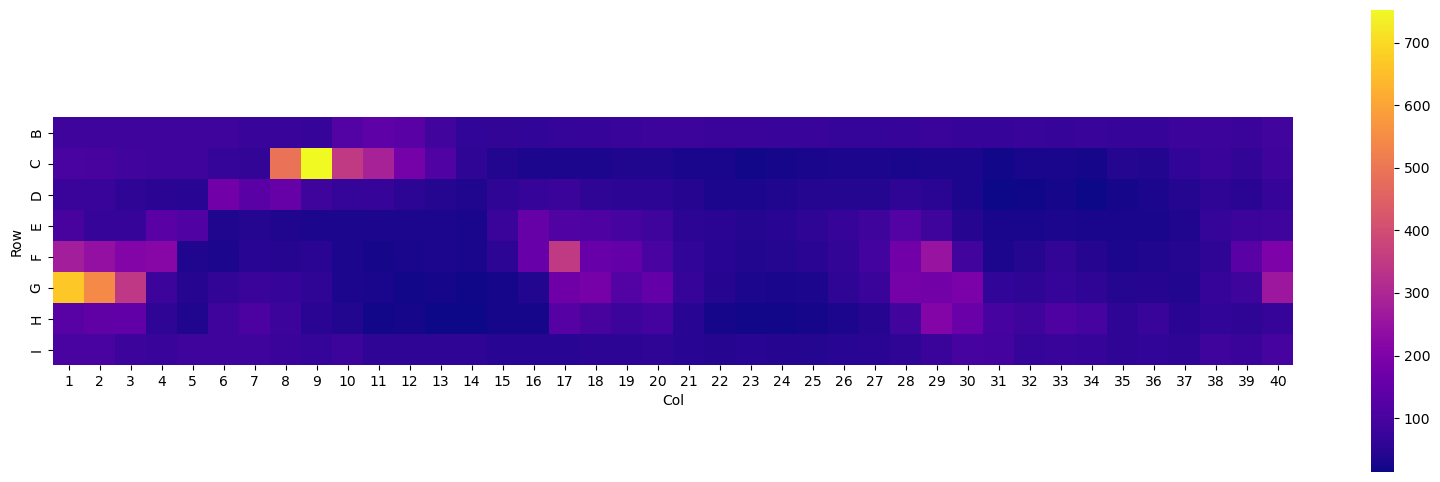

In [12]:
# now plot as heatmap.
plt.figure(figsize=(20, 6))
ax = sns.heatmap(hpc_pivoted_trimmed, square=True, cmap='plasma')
plt.show()

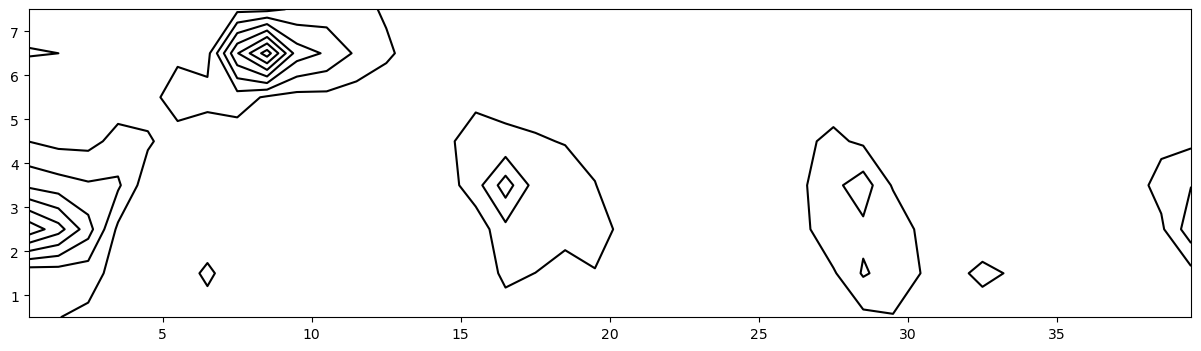

In [13]:
# now plot again, as a contourplot as in the paper.  
plt.figure(figsize=(15, 4))
plt.contour(hpc_pivoted_trimmed, levels=[100, 200, 300, 400, 500, 600, 700], origin='upper', colors='black')
plt.show()

In [14]:
# check the number of focal hits at each of the focal colors reported in the paper, p. 8387:
# "
# Concretely, we take the universal foci to be the peaks of the WCS best-example distribution: 
# A0 (white: 2,048 WCS hits), J0 (black: 1,988 hits), G1 (red: 668 hits), C9 (yellow: 752 hits), F17 (green: 351 hits), and F29 (blue: 253 hits).
# "
foci_from_paper = {"white": "A0", "black": "J0", "red": "G1", "yellow":"C9" , "green":"F17" , "blue": "F29"}
for focus in foci_from_paper:
    focus_chip = foci_from_paper[focus]
    print("focus for", focus, "is at", focus_chip) 
    display(hpc[hpc.Chip==focus_chip])

focus for white is at A0


,Chip,Count,Row,Col
0,A0,2048,A,0


focus for black is at J0


,Chip,Count,Row,Col
369,J0,1988,J,0


focus for red is at G1


...

,Chip,Count,Row,Col
91,C9,752,C,9


focus for green is at F17


,Chip,Count,Row,Col
222,F17,351,F,17


focus for blue is at F29


,Chip,Count,Row,Col
234,F29,253,F,29


In [15]:
# we can easily see which chips have the most focal hits.
# which have the fewest?  harder to tell just by looking at the plot - so let's ask for that explicitly.
mincount = hpc.Count.min()
hpc[hpc.Count == mincount]

,Chip,Count,Row,Col
301,H14,14,H,14


### Replication achieved!   

The basic pattern is replicated in the above plot, and the above numbers.  That finding is consistent with the notion that there are strong universals in color naming across languages, reflected in the colors that speakers of a wide range of languages select as the best examples of color names in their languages.

But there is already a note of complication.  We also saw that every chip in the entire grid was chosen by at least 14 speakers (and often many more) as the best example of some color term in some language.  That suggests an interesting amount of cross-language variation, that is obscured when we simply pool all responses together.





### So now let's extend to new analyses, that explore cross-language variation.

In principle we could create 2-D heatmaps for each language - and feel free to do so if you like - after all, you have a model above that you can extend.  But for now, for simplicity, we will consider focus choice responses as a 1-dimensional distribution over columns of the stimulus grid, rather than a 2-dimensional distribution over both rows and columns.  To do this, we will sum together all focus choices that fell in different rows within a single column of the grid, getting a total count for each column.  This set of counts can then be converted to a probability distribution by normalizing.  I believe the first publication to propose such 1-D histograms of focus counts was:

- MacLaury, Robert E. (1997). Ethnographic evidence of unique hues and elemental colors. <i>Behavioral and Brain Sciences</i>, 20(2), 202-203.

In [16]:
# start by specifying the set of columns to target.
# we leave out column 0 because it is achromatic
cols = list(range(1,40+1))
cols

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40]

In [17]:
# function to plot a distribution of focus counts across WCS columns, either normalized or not.
def plot_distrib(d):
    plt.figure(figsize=(18, 4))
    plt.bar(list(d.keys()), list(d.values()))
    plt.show()

---
**4 points for the following cell**:
- 2 points for calculating the right information
- 2 points for arranging it appropriately

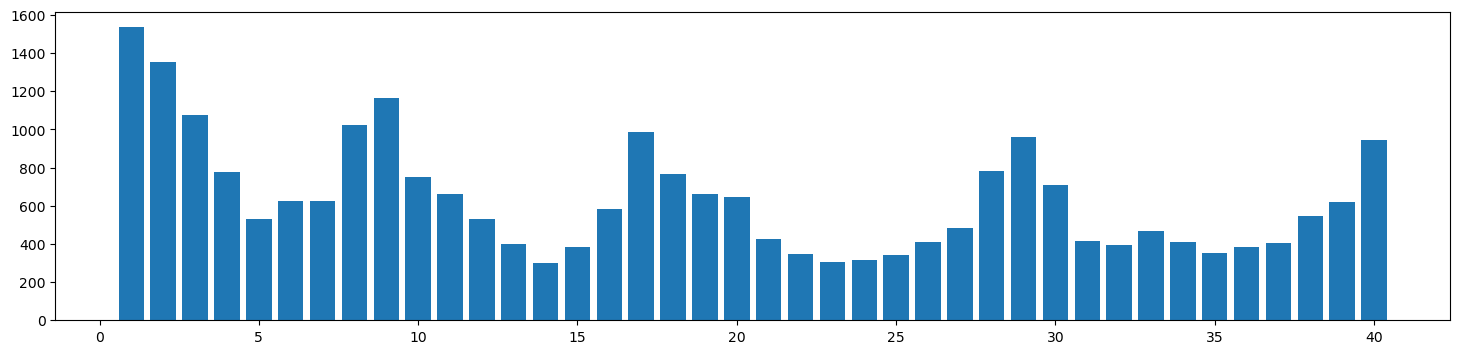

In [18]:
# now for each column, determine the number of focus hits that fell in that column.
# we are weeding out chips in rows A and J because they are achromatic.
# store in a dict called d.
d_wcs = {}
# YOUR CODE GOES HERE.
for col in cols:
    d_wcs[col] = hpc_pivoted_trimmed[col].sum()

plot_distrib(d_wcs)

---
**4 points for the following cell**:
- 2 points for calculating the right information
- 2 points for arranging it appropriately

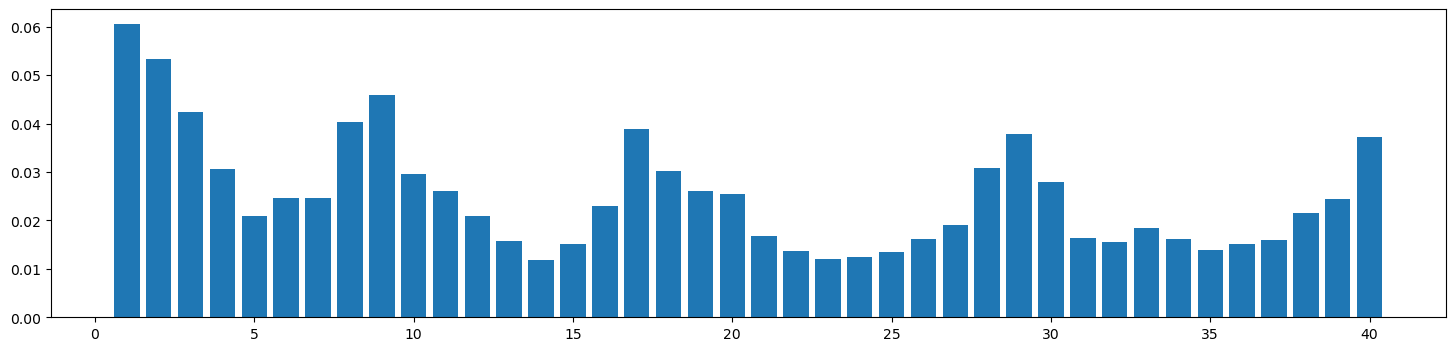

In [19]:
# now cast as probability distribution, and re-plot.
prob_wcs = {}
# YOUR CODE GOES HERE.
total = sum(d_wcs.values())
for col in cols:
    prob_wcs[col] = d_wcs[col] / total
plot_distrib(prob_wcs)

---
**10 points for the following cell**:
- 2 points for extracting the part of the dataframe that is specific to this language.
- 2 points for calculating focus (best example) hits per chip for this language.
- 2 points for splitting apart Chip designations into separate Row and Col designations
- 2 points for getting column counts, summing across rows, and plotting
- 2 points for casting as a probability distribution, and plotting

,LgNum,LgName,Speaker,Term,Chip
0,1,Abidji,1,LF,A0
1,1,Abidji,1,WK,D9
2,1,Abidji,1,WK,D10
3,1,Abidji,1,WK,D11
4,1,Abidji,1,WK,D12
...,...,...,...,...,...
275,1,Abidji,25,F,B6
276,1,Abidji,25,LB,J0
277,1,Abidji,25,G,F29
278,1,Abidji,25,G,F30


,Chip,Count
0,A0,22
1,A1,0
2,A2,0
3,A3,0
4,A4,0
...,...,...
405,J36,0
406,J37,0
407,J38,0
408,J39,0


,Chip,Count,Row,Col
0,A0,22,A,0
1,A1,0,A,1
2,A2,0,A,2
3,A3,0,A,3
4,A4,0,A,4
...,...,...,...,...
405,J36,0,J,36
406,J37,0,J,37
407,J38,0,J,38
408,J39,0,J,39


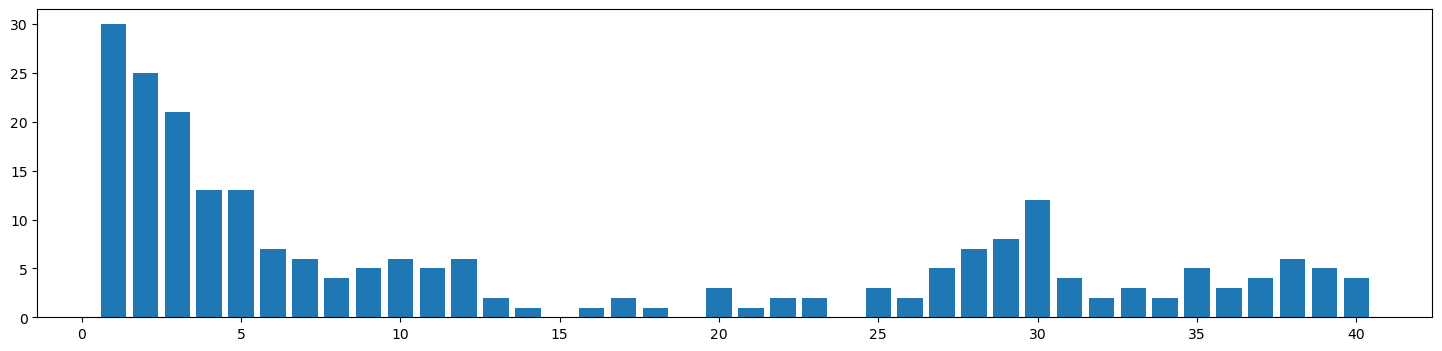

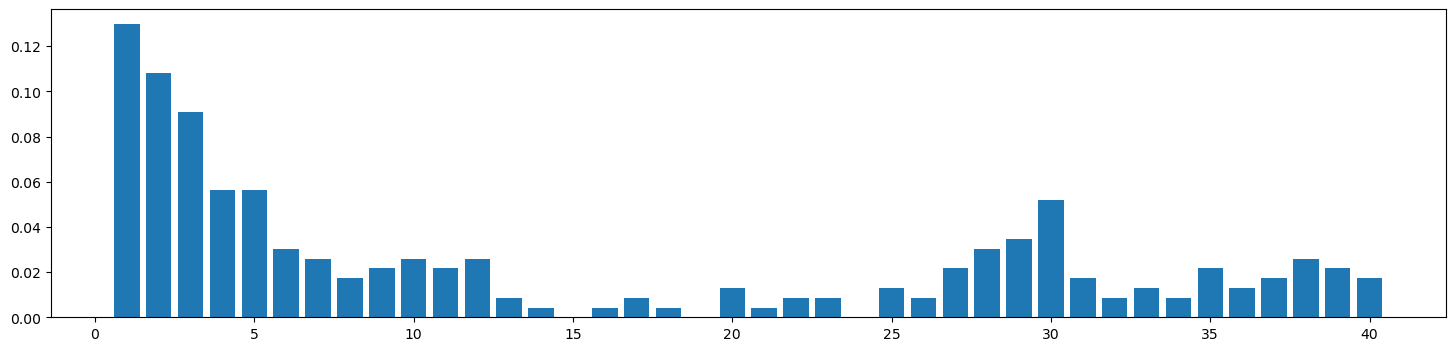

In [20]:
# now that we have established what appear to be universal tendencies, let's zoom in and consider individual
# languages separately, to get a sense for the cross-language variation underlying this pattern.

# first let's do that for a single sample lg.

# sample lg
lg = 'Abidji'

# now do everything you did above, to get the 1-D plot, but just for this one lg.
# YOUR CODE GOES HERE.
# i include here a few printouts along the way - these should appear in the middle of your code.
lg_df = fdf[fdf['LgName'] == lg]
# lg_df is a sub-df of fdf that is specific to lg
display(lg_df)

# hpc is (focus) hits per chip for this lg, in the form of a df.
hpc = {}
letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
for letter in letters:
    for num in range(41):
        hpc[letter+str(num)] = 0
for row, series in lg_df.iterrows():
    hpc[str(fdf['Chip'][row])] = hpc[fdf['Chip'][row]] + 1
hpcdf = pd.DataFrame(hpc.items(), columns = ['Chip', 'Count'])
hpc = hpcdf
# hpc = hpc[hpc['Count'] > 0]
display(hpc)

# now in hpc, split apart Chip designation into separate Row and Col designations.
hpc['Row'] = hpc.apply(lambda row: row.Chip[0], axis=1)
hpc['Col'] = hpc.apply(lambda row: int(row.Chip[1:]), axis=1)
display(hpc)

# hpc tables are longer because we're still storing zero counts, which 
# we need to do when we pivot the table below. It doesn't affect the final counts

hpc_pivoted = hpc.pivot(index="Row", columns="Col", values="Count")
hpc_pivoted_trimmed = hpc_pivoted.loc['B' : 'I'].loc[:, hpc_pivoted.columns != 0]

d = {}  # dict for counts, as above.
for col in cols:
    d[col] = hpc_pivoted_trimmed[col].sum()
plot_distrib(d)

prob = {} # dict for probabilities, as above.
total = sum(d.values())
for col in cols:
    prob[col] = d[col] / total
plot_distrib(prob)

---
**10 points for the following cell**:
- 2 points for extracting the part of the dataframe that is specific to the given language.
- 2 points for calculating focus (best example) hits per chip for this language.
- 2 points for splitting apart Chip designations into separate Row and Col designations
- 2 points for getting column counts, summing across rows
- 2 points for casting as a probability distribution, and plotting

There are 110 different languages in the WCS.
Abidji


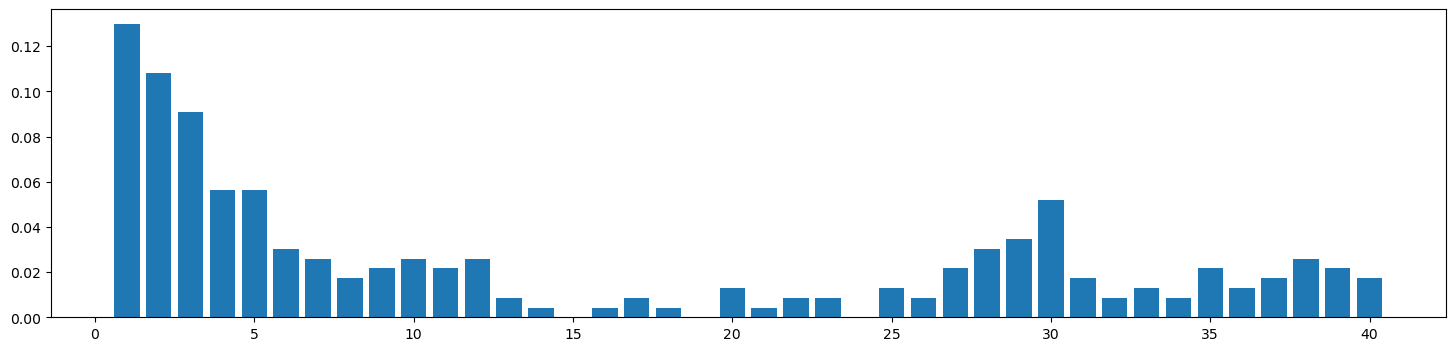

Agarabi


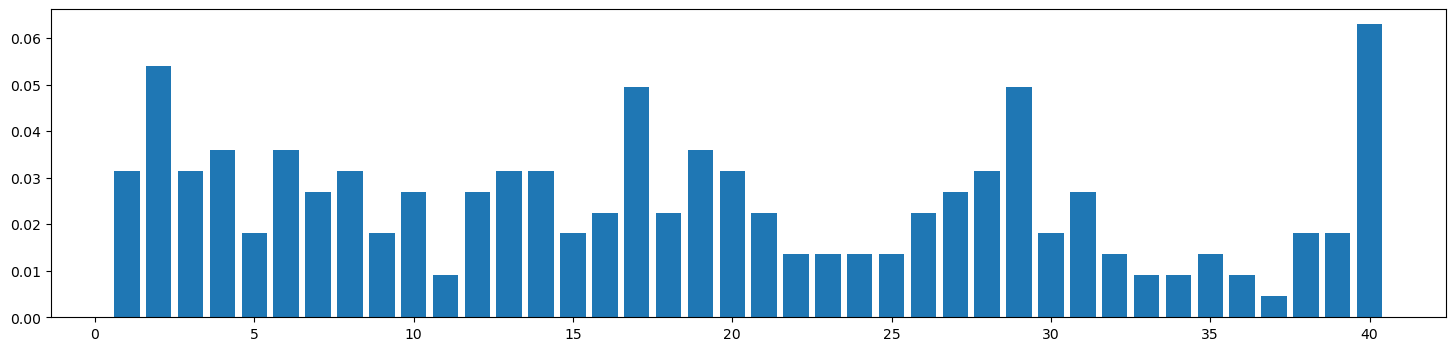

Casiguran Agta


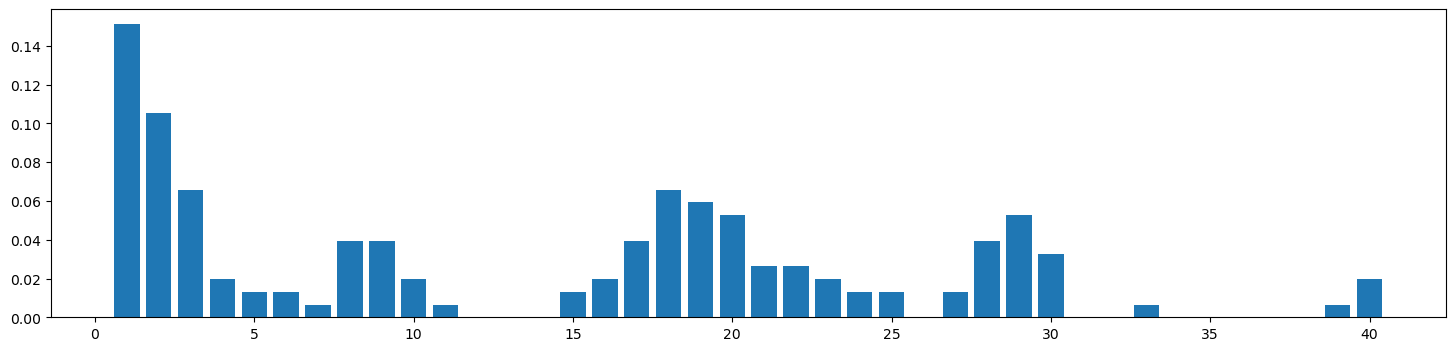

Aguacateco


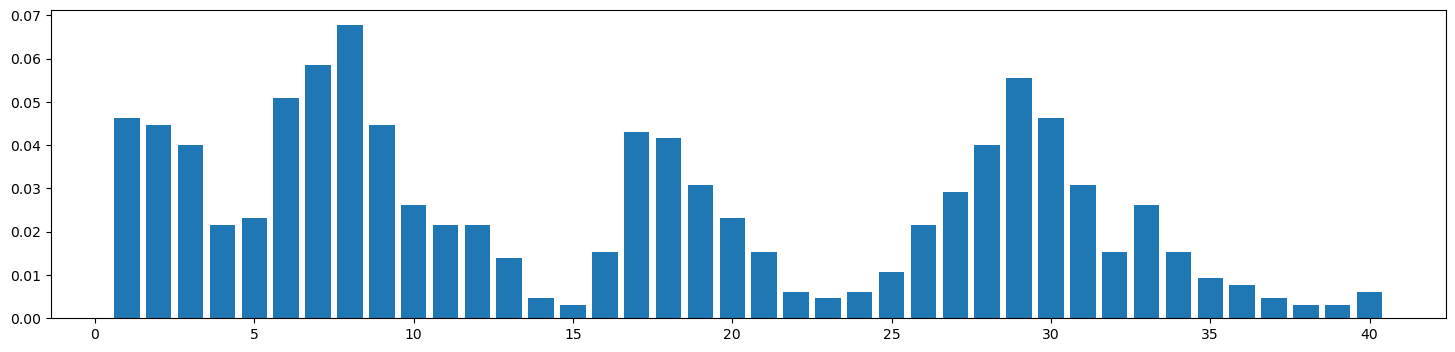

Amarakaeri


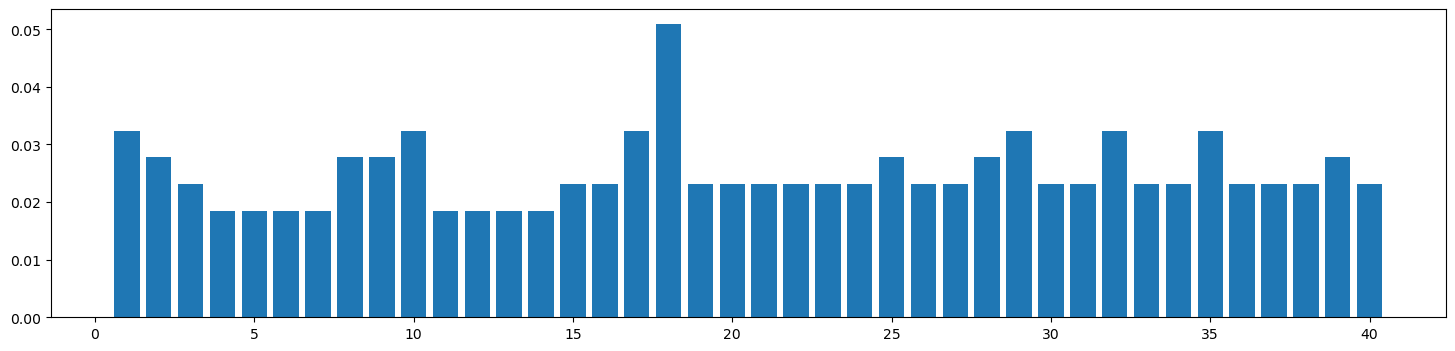

Ampeeli


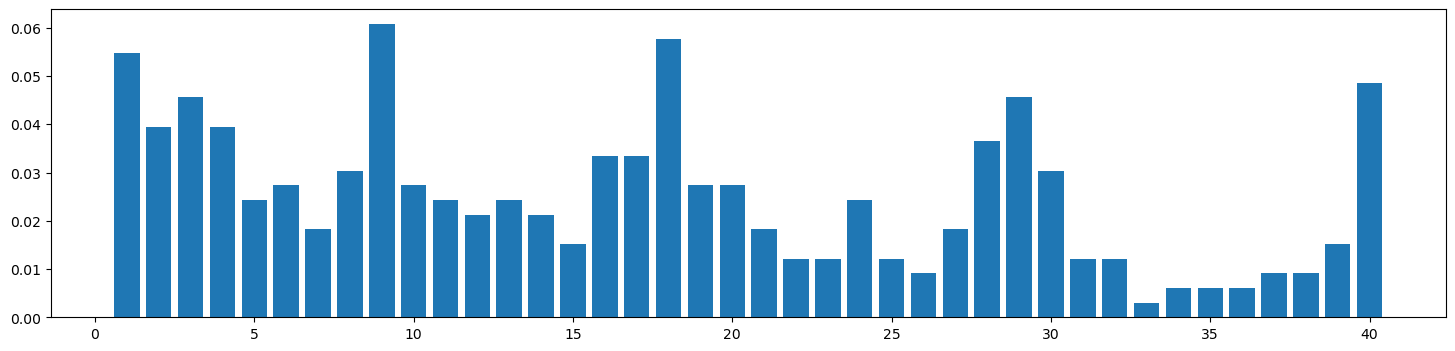

Amuzgo


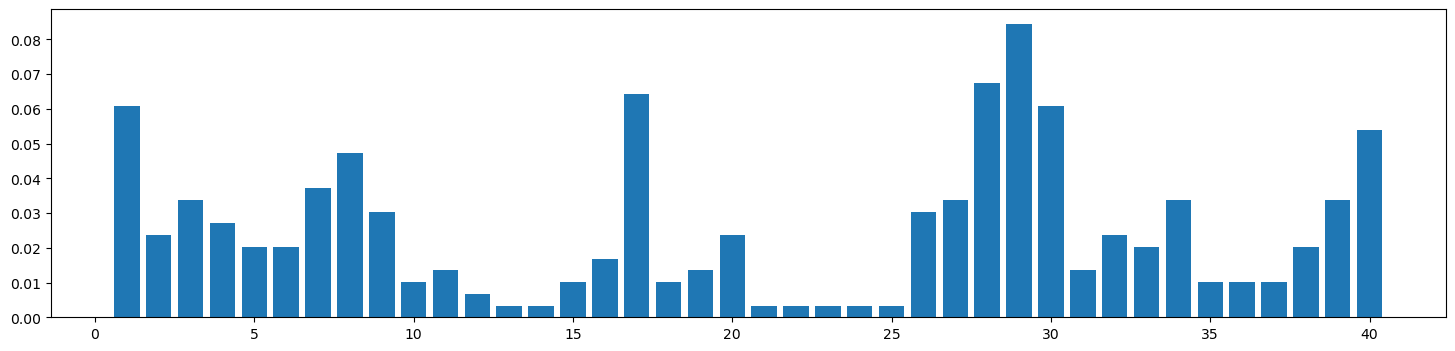

Angaatiha


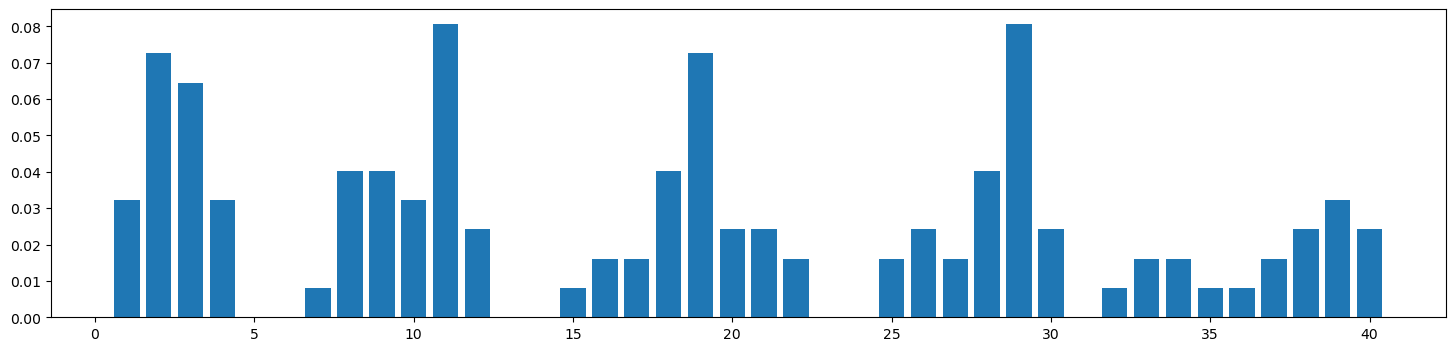

Apinaye


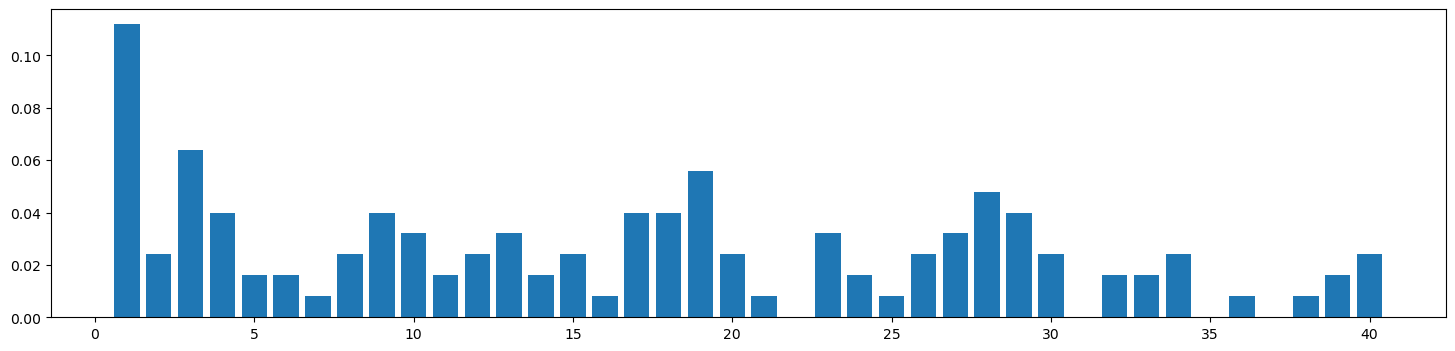

Arabela


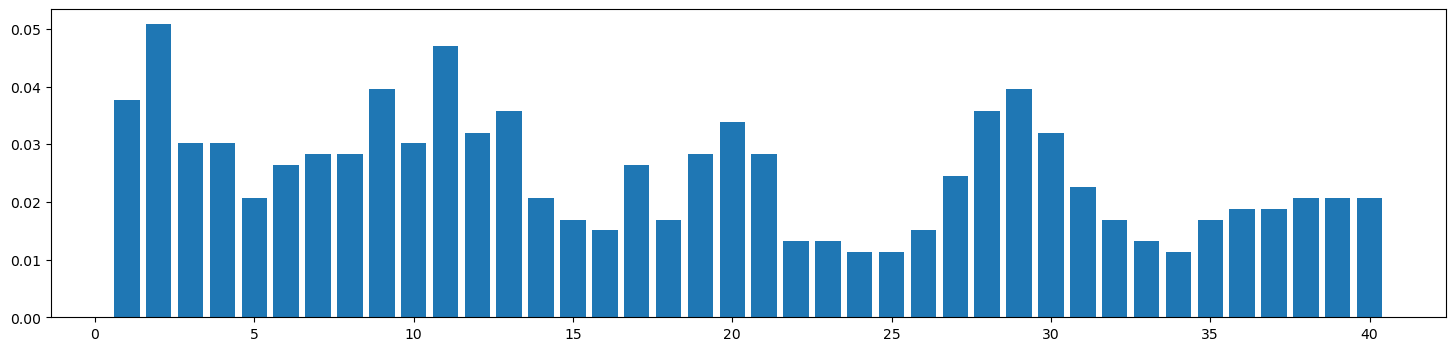

Bahinemo


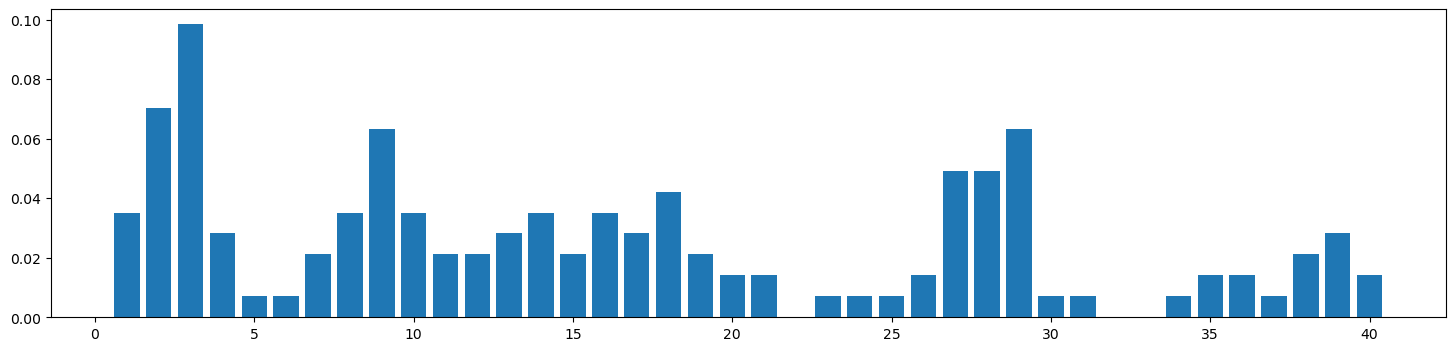

Bauzi


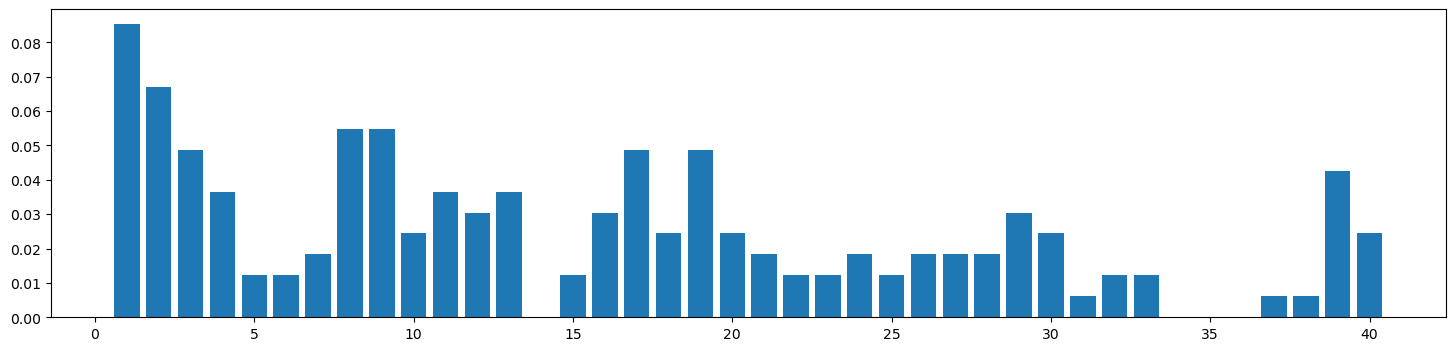

Berik


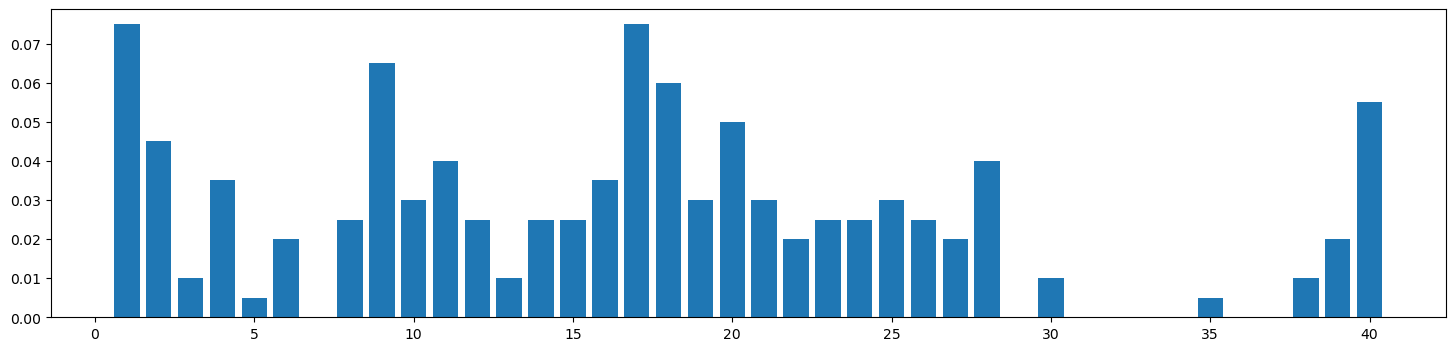

Bete


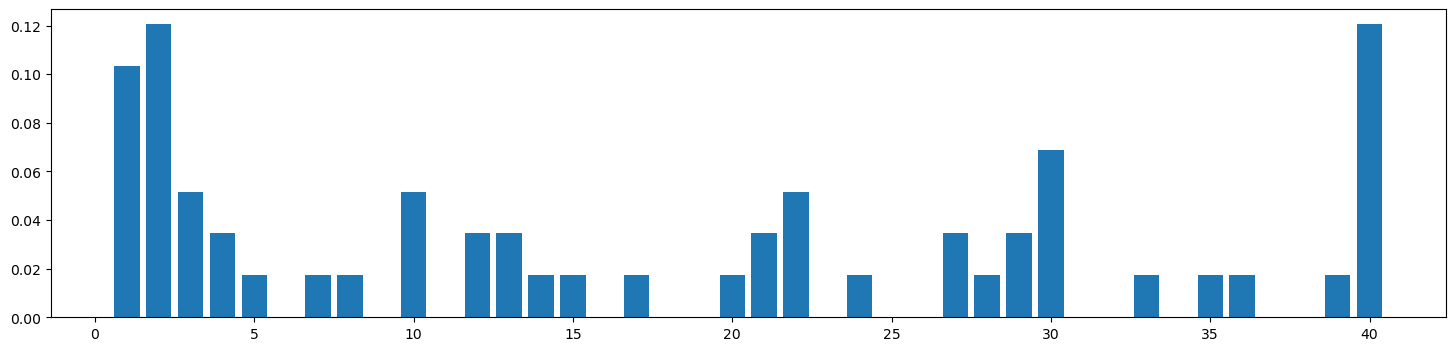

Bhili


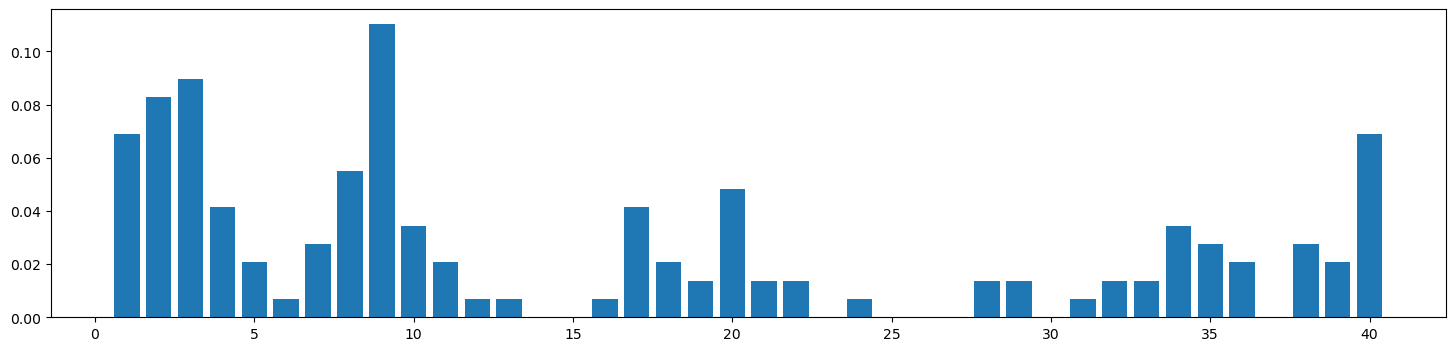

Buglere


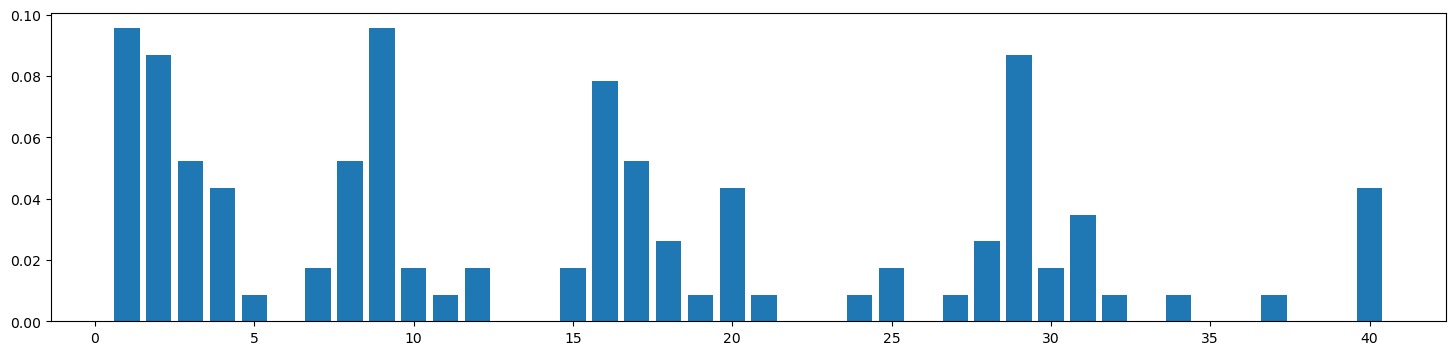

Cakchiquel


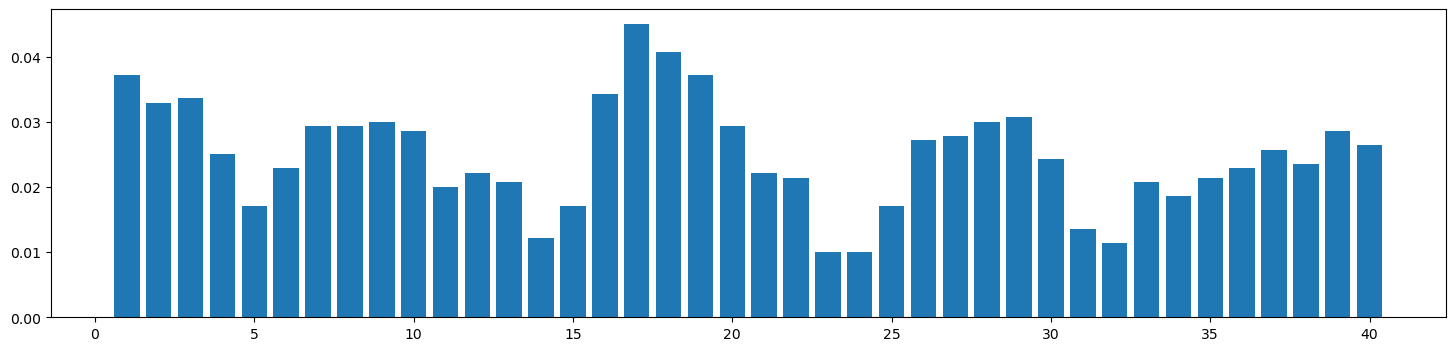

Ucayali Campa


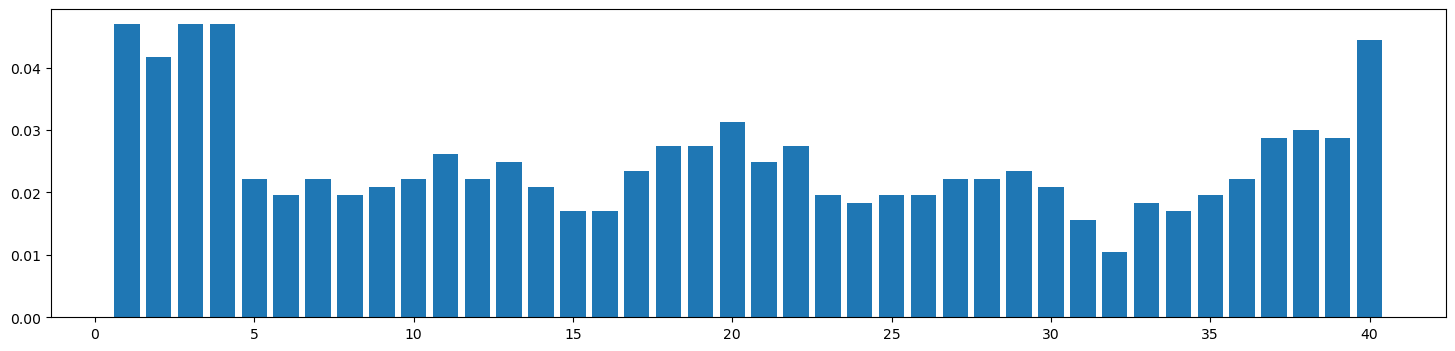

Camsa


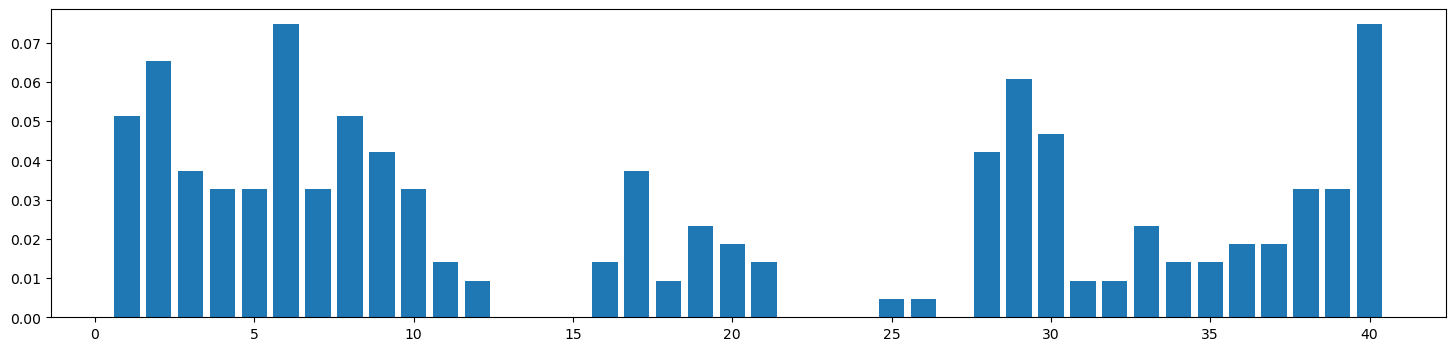

Candoshi


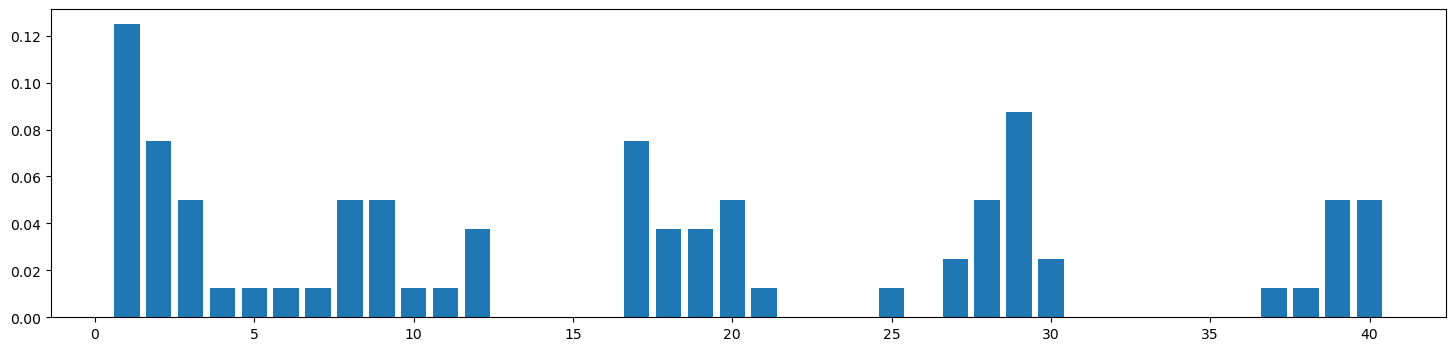

Cavine{\x96}a


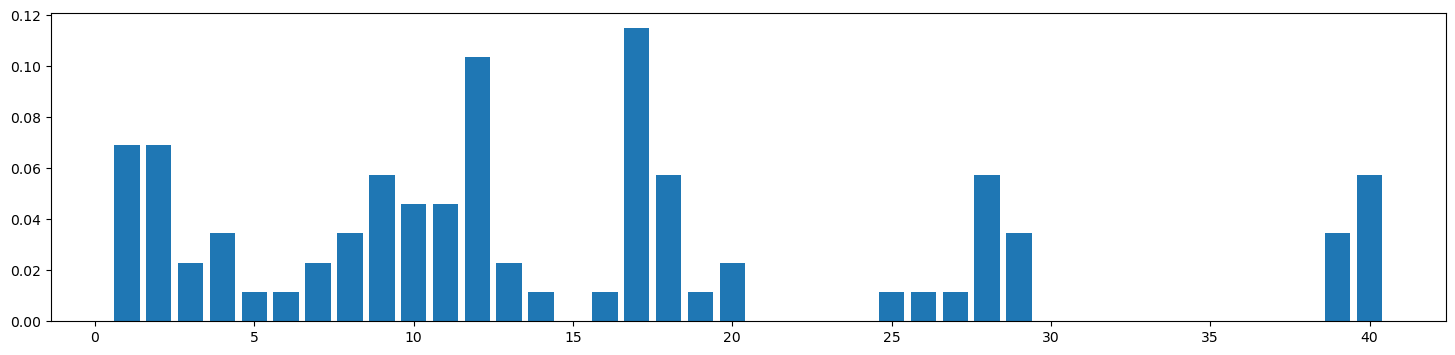

Cayapa


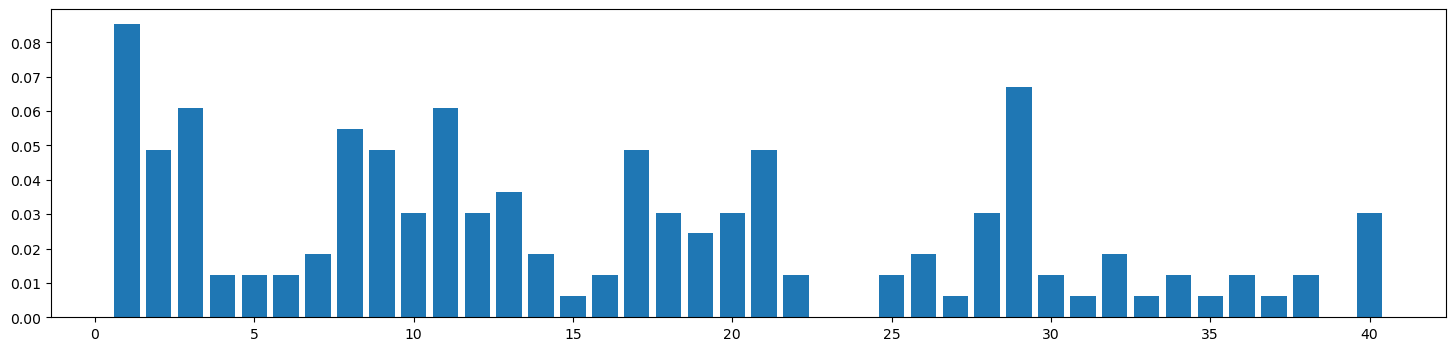

Ch{\x87}cobo


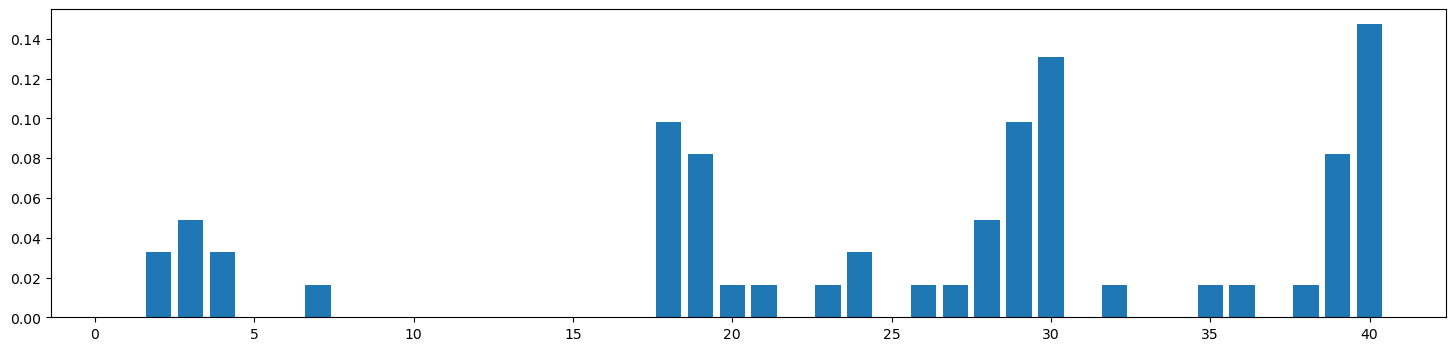

Chavacano


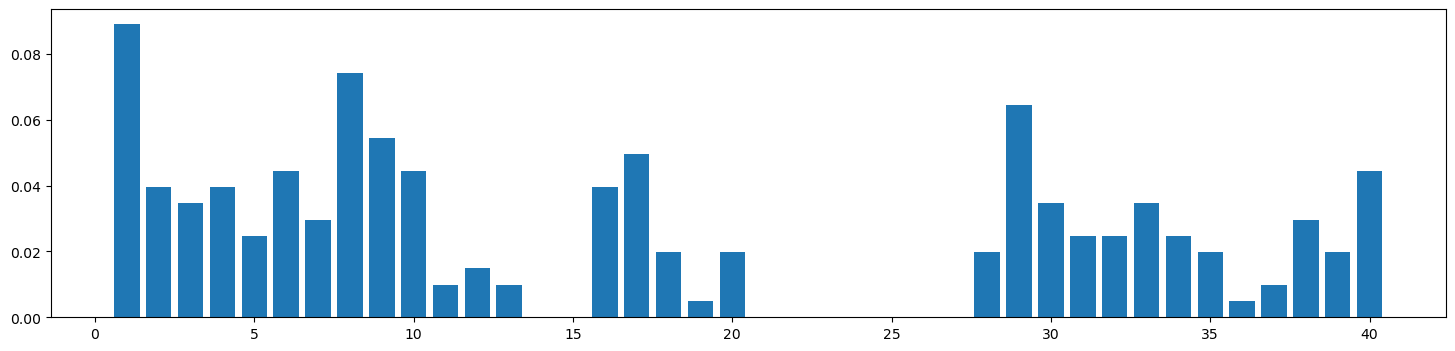

Chayahuita


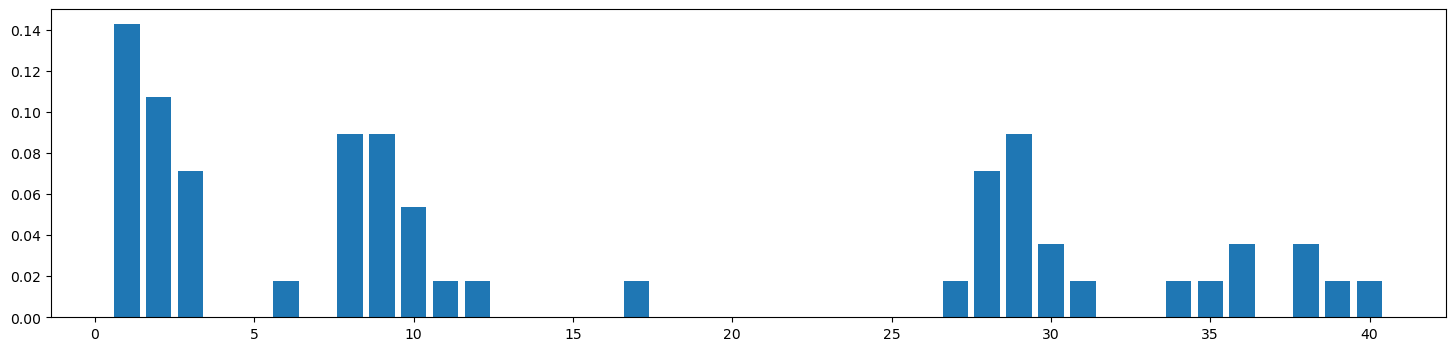

Chinanteco


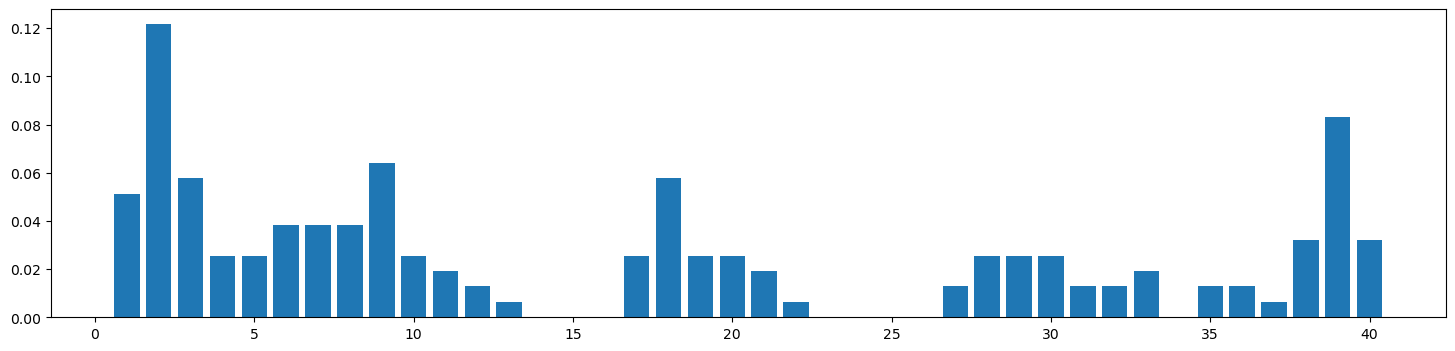

Chiquitano


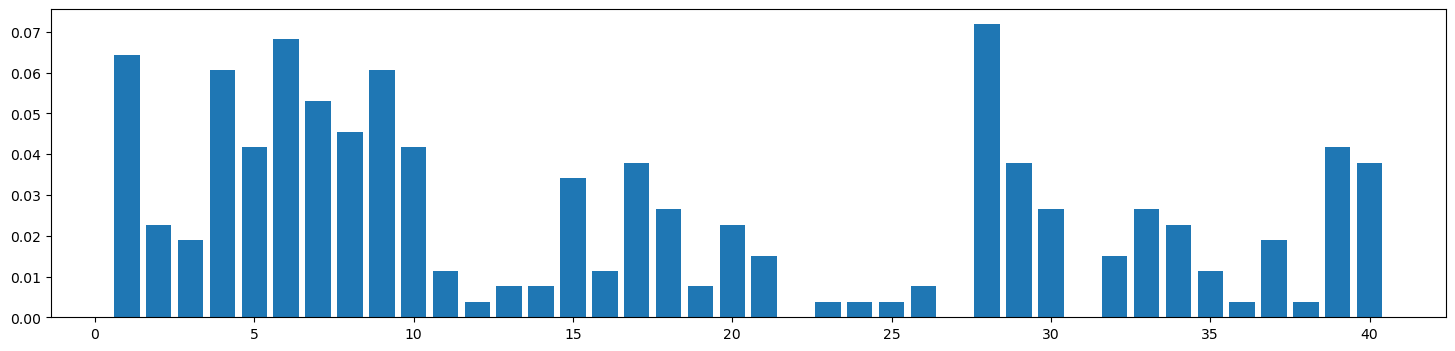

Chumburu


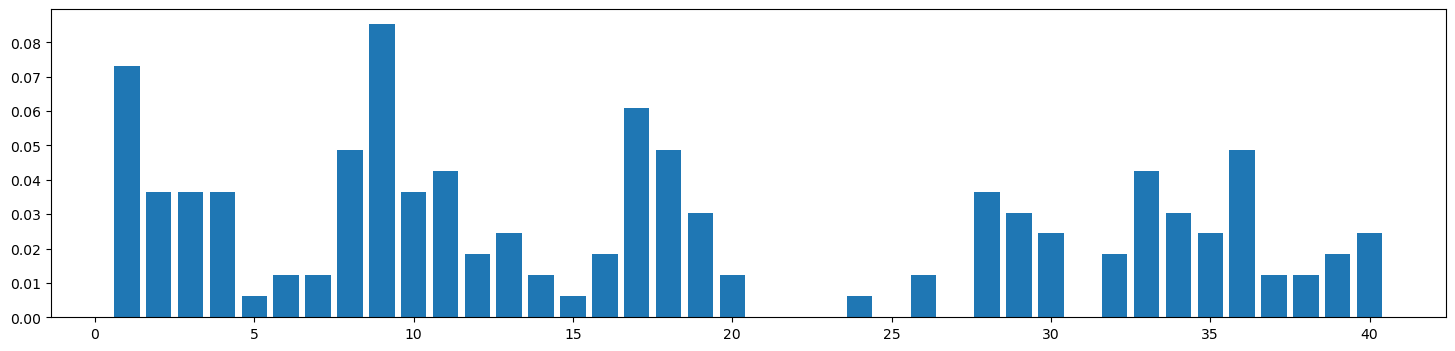

Cof{\x87}n


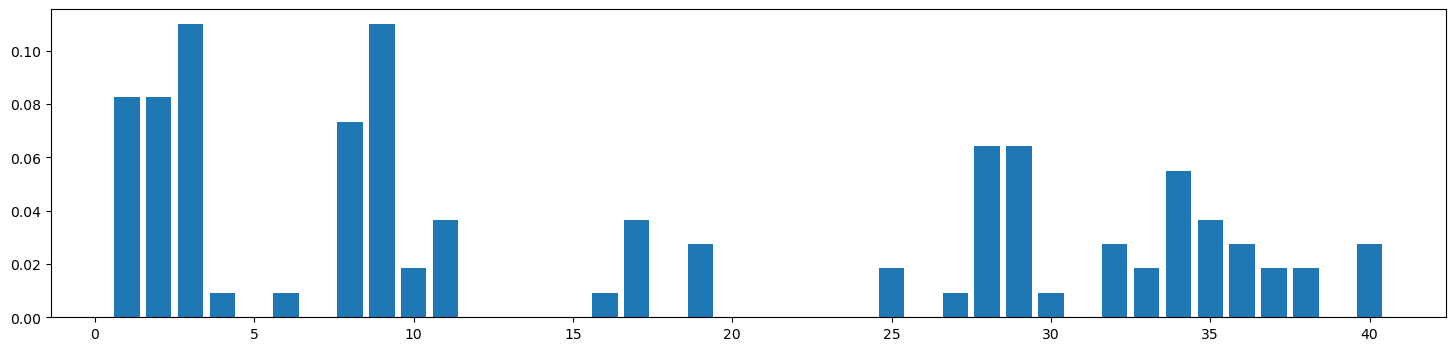

Colorado


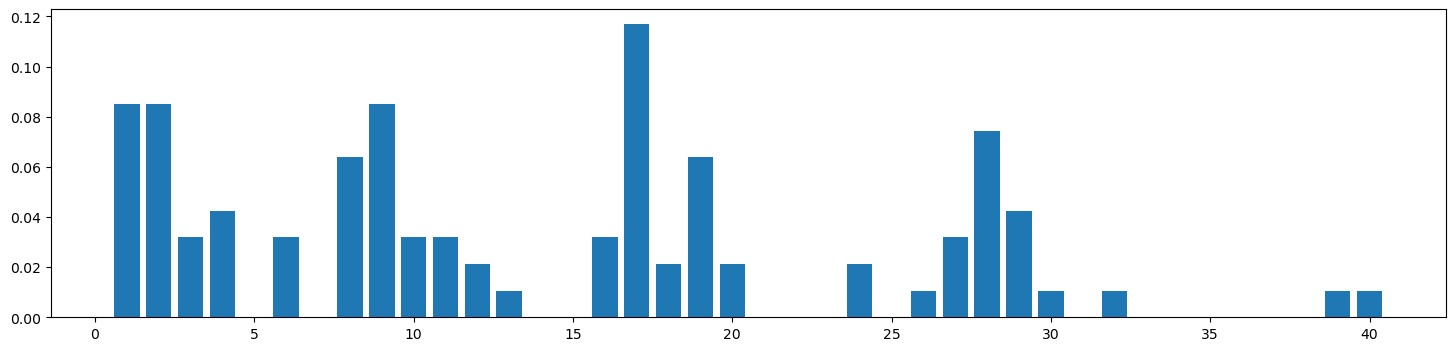

Eastern Cree


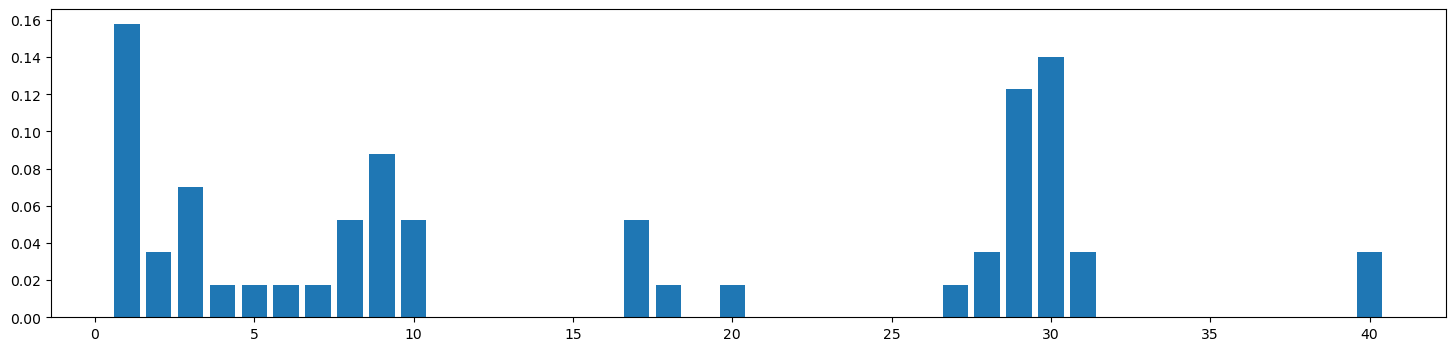

Culina


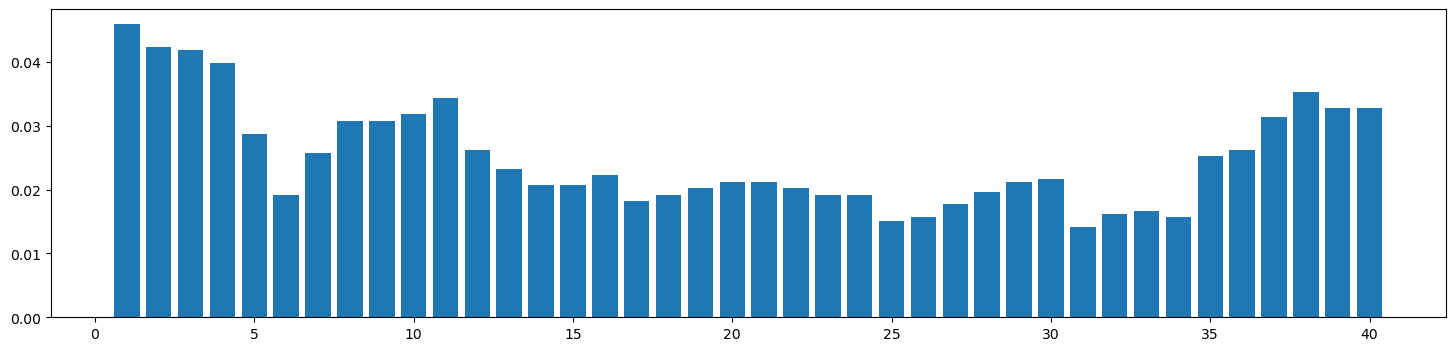

Didinga


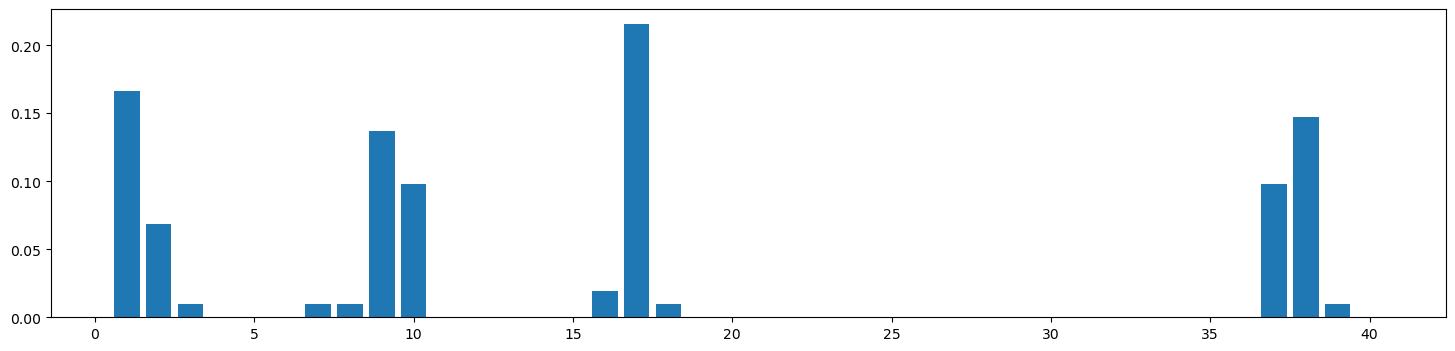

Djuka


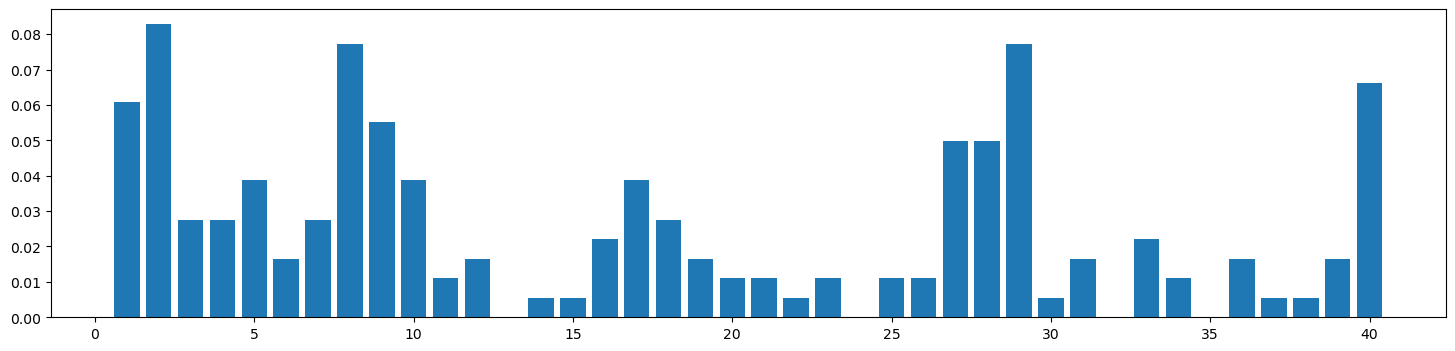

Dyimini


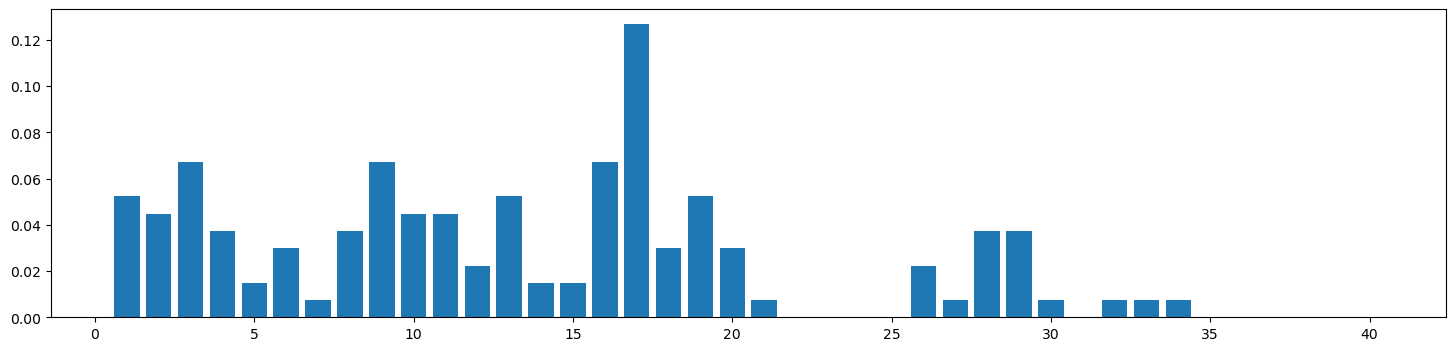

Ejagam


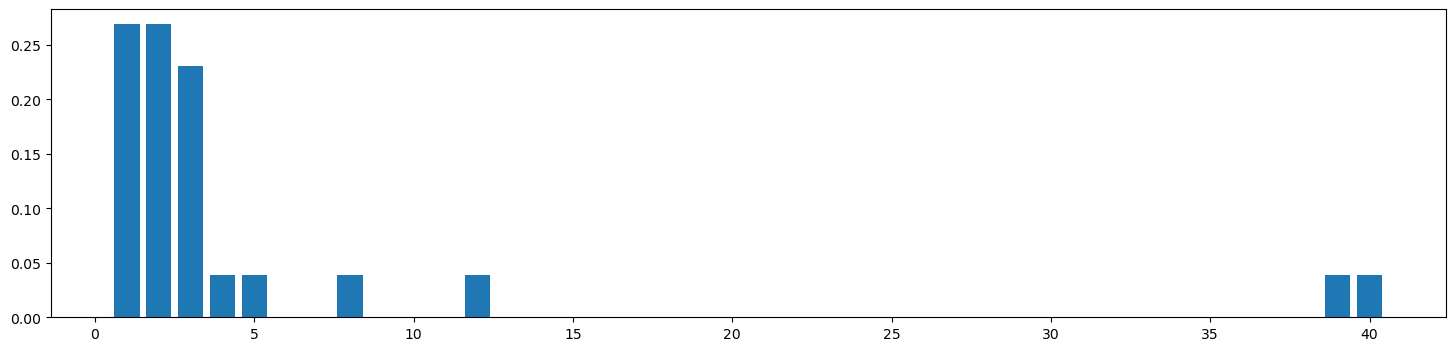

Ese Ejja


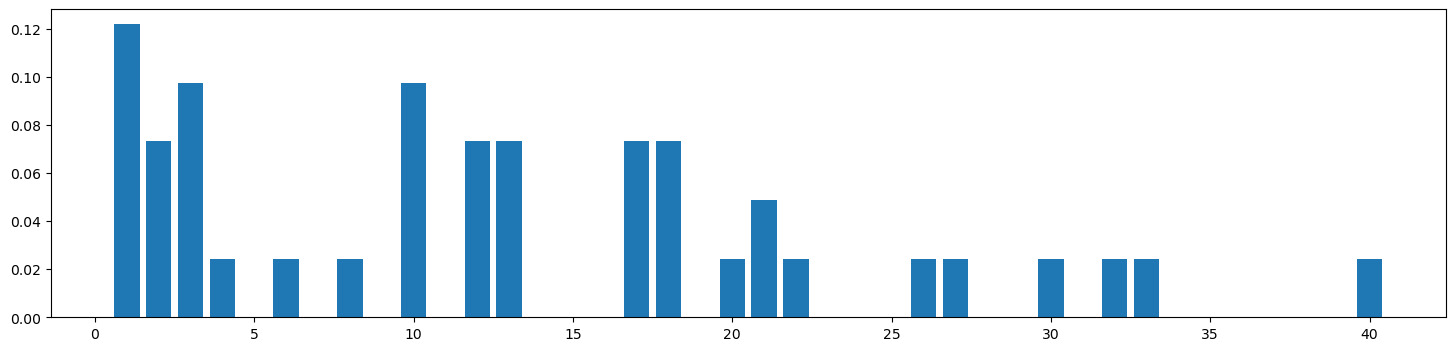

Carib


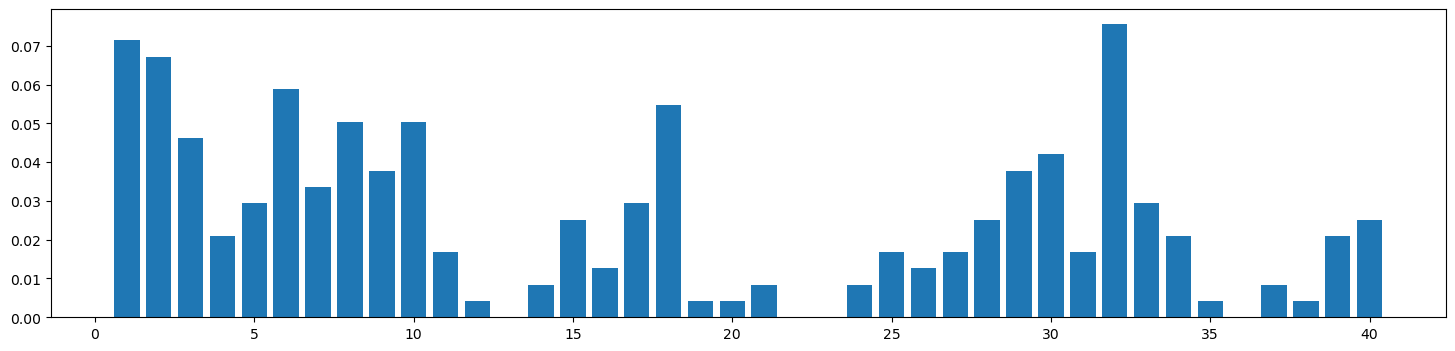

Guahibo


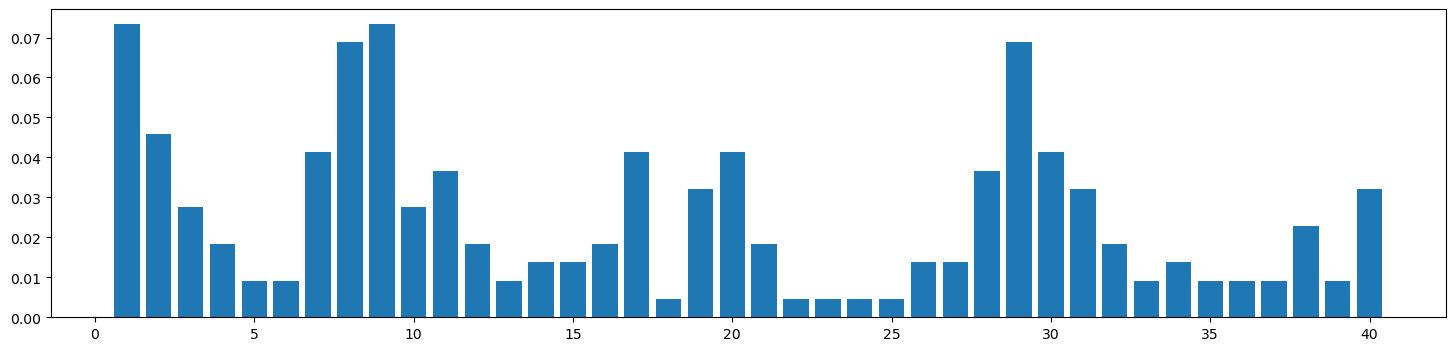

Guambiano


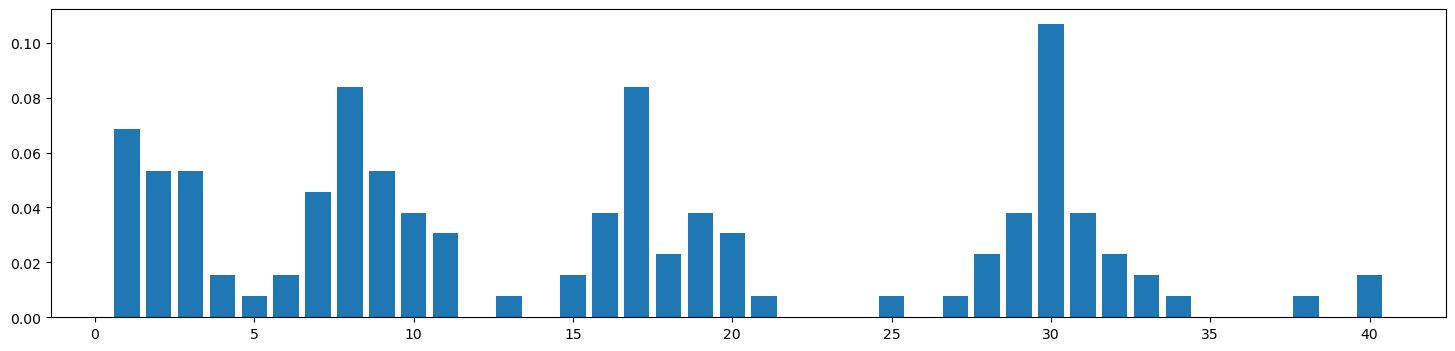

Guarijio


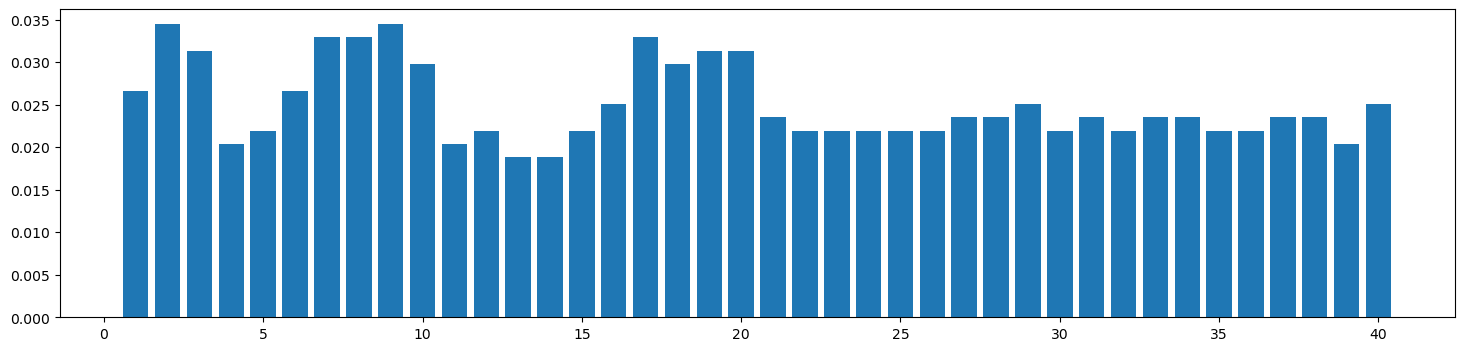

Ng{\x8A}bere


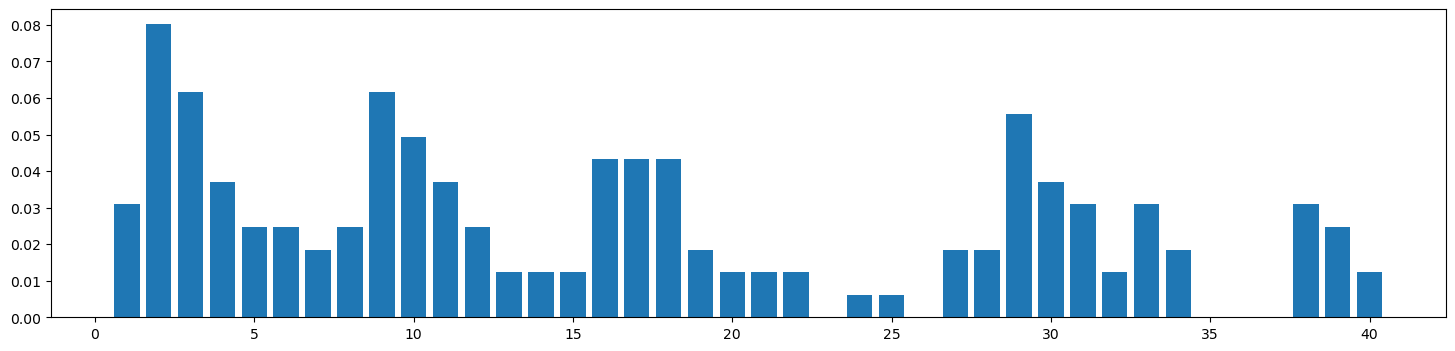

Gunu


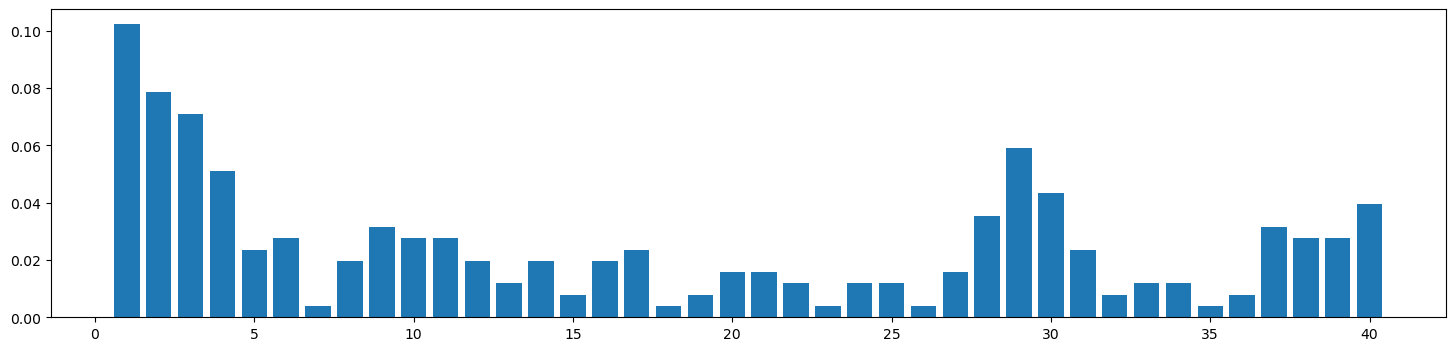

Halbi


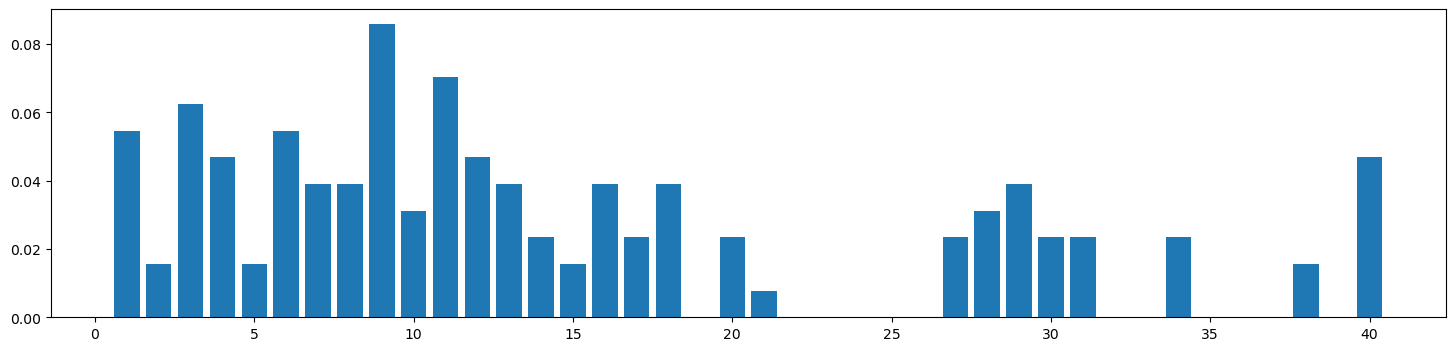

Huasteco


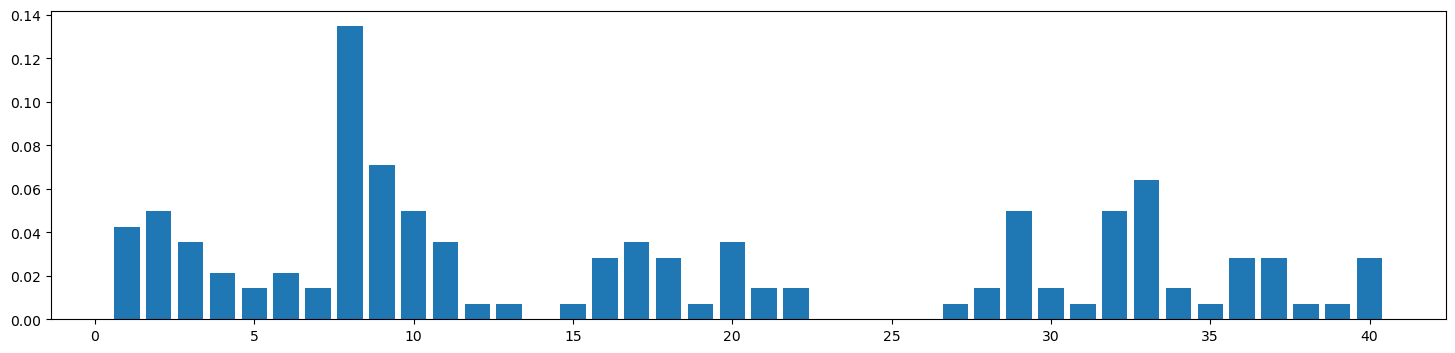

Huave


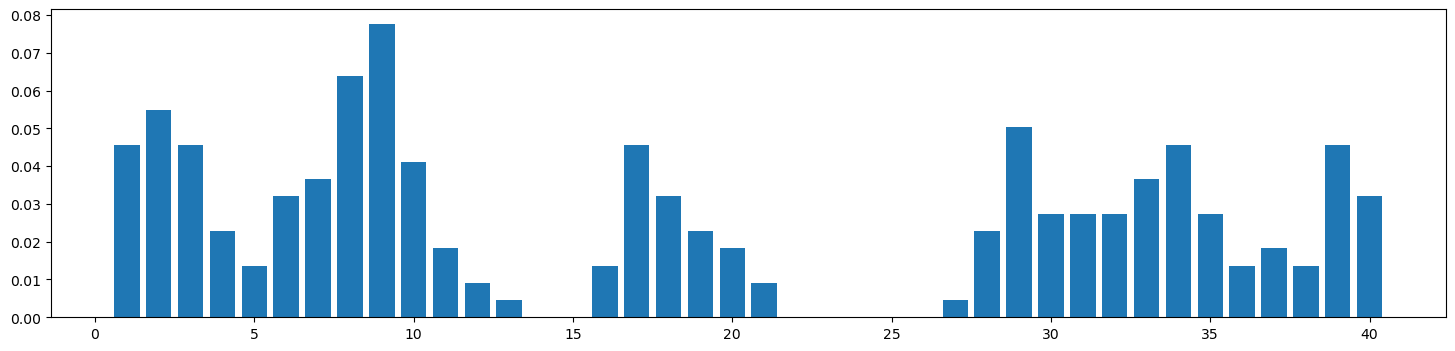

Iduna


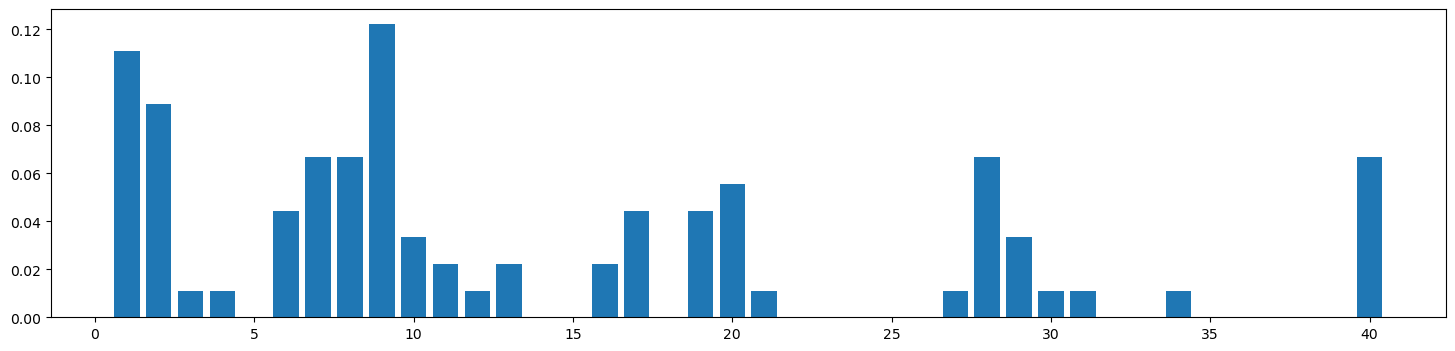

Ifugao


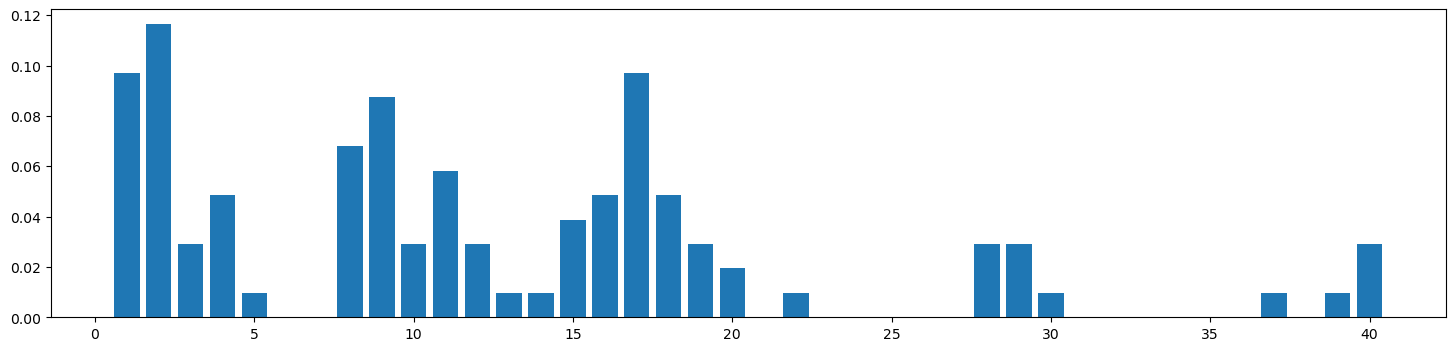

Sepik Iwam


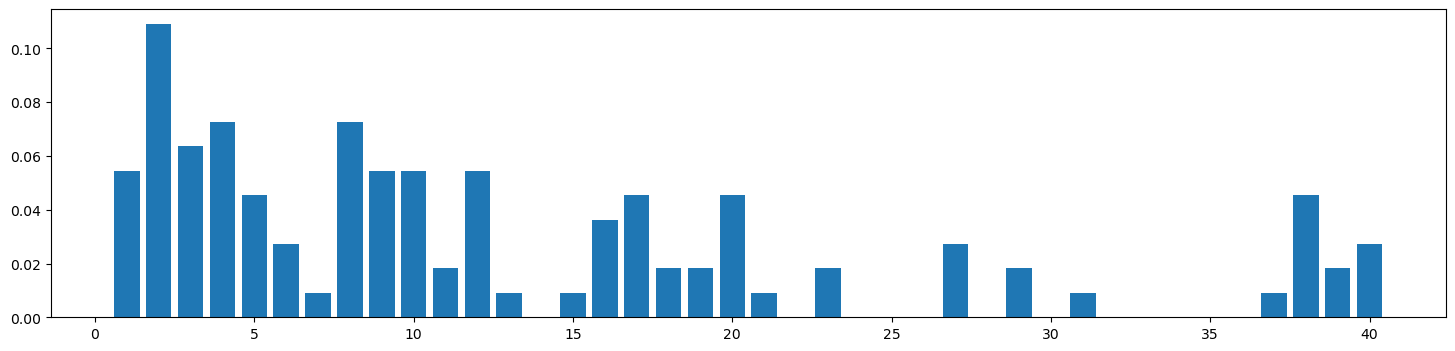

Jicaque


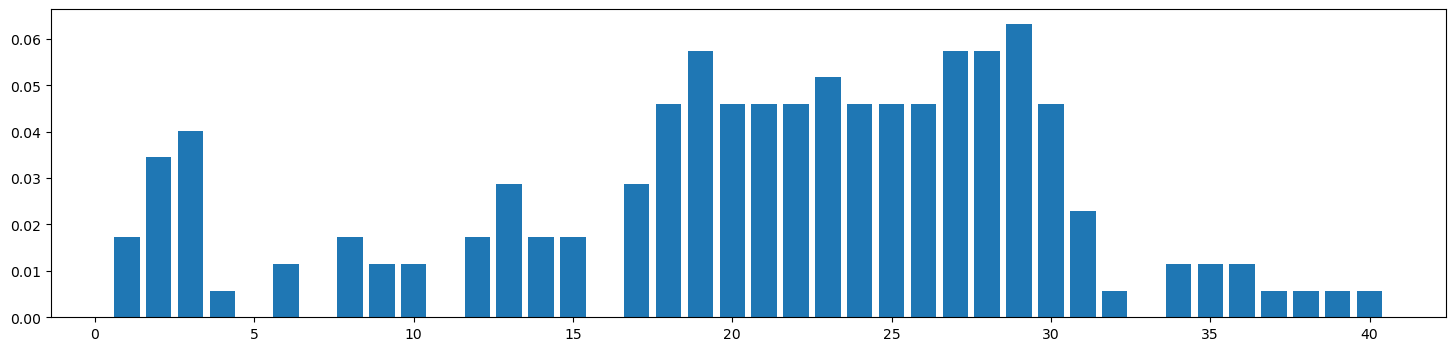

Kalam


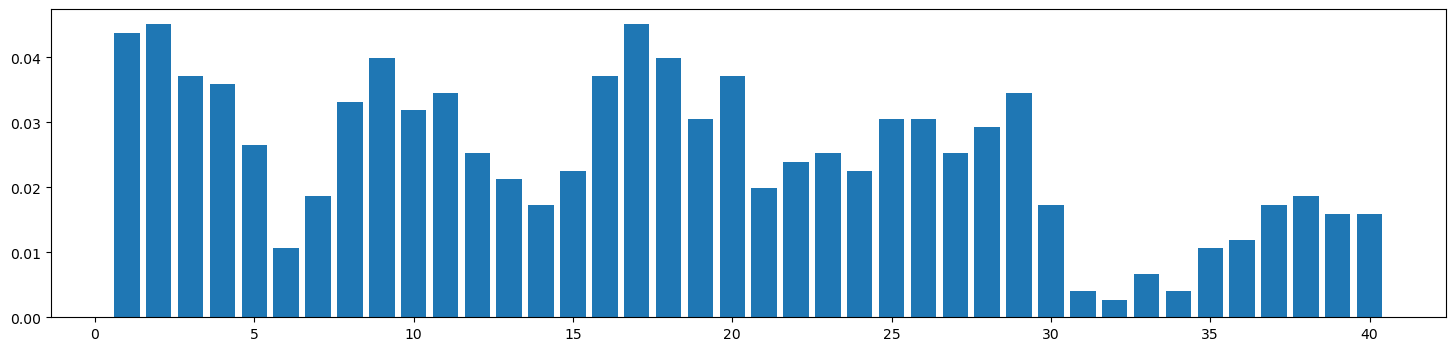

Kamano-Kafe


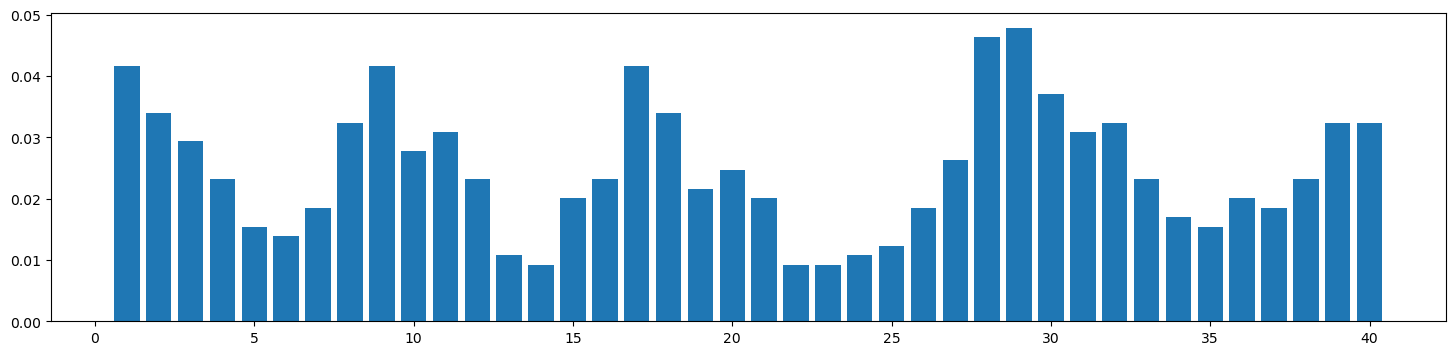

Karaja


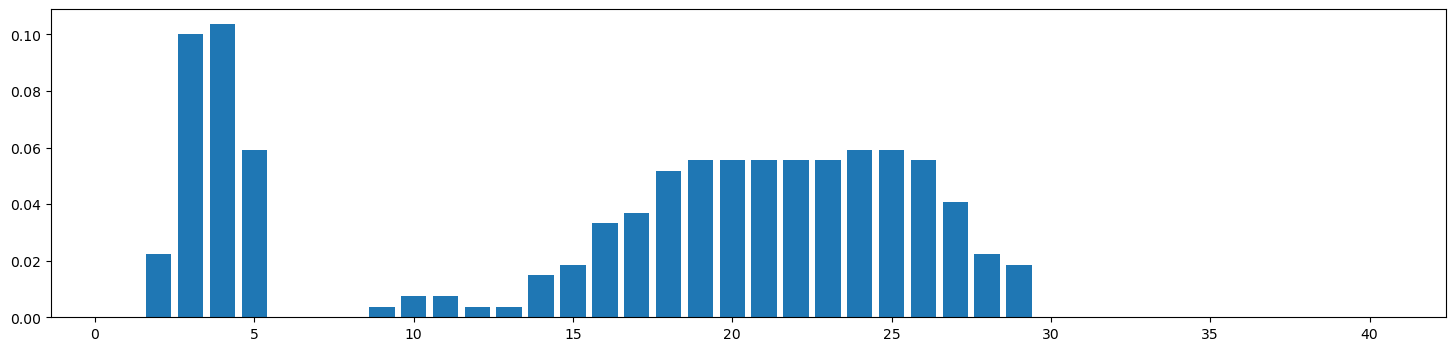

Kemtuik


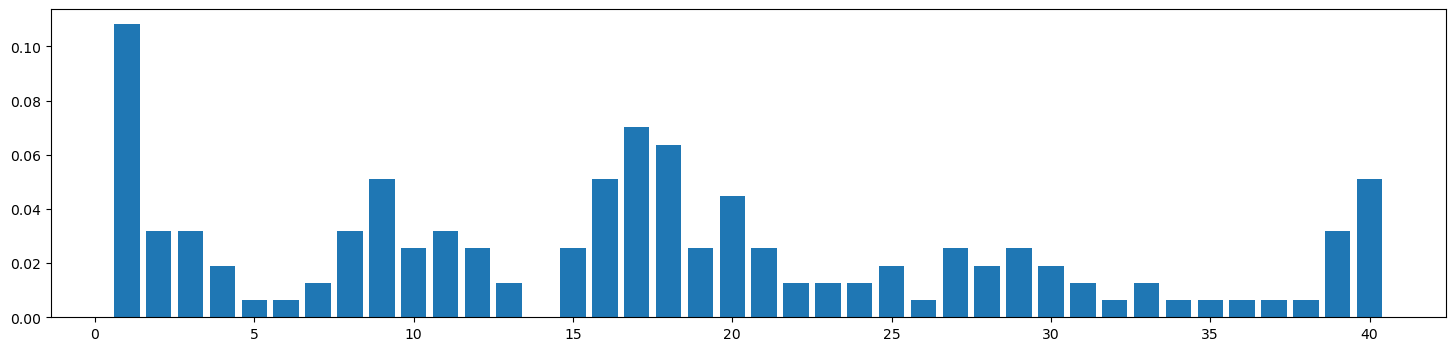

Kokoni


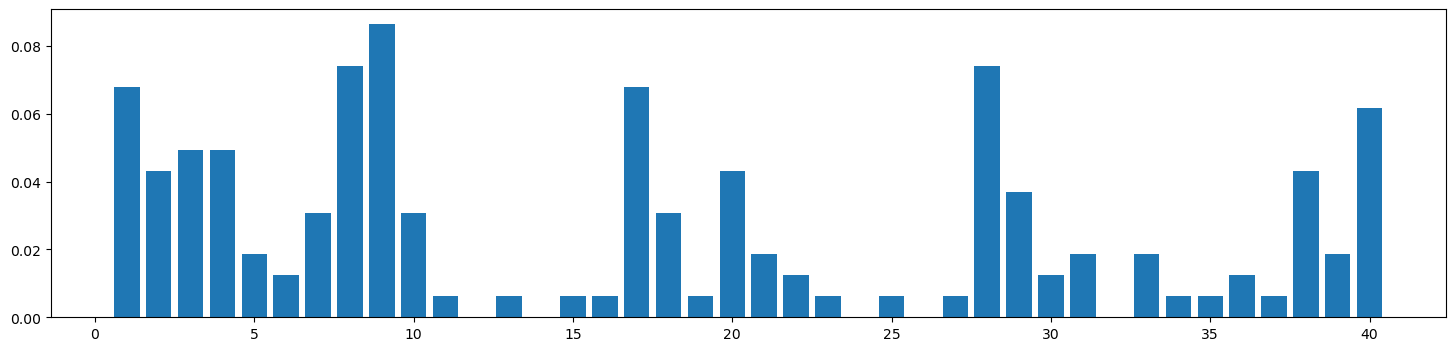

Konkomba


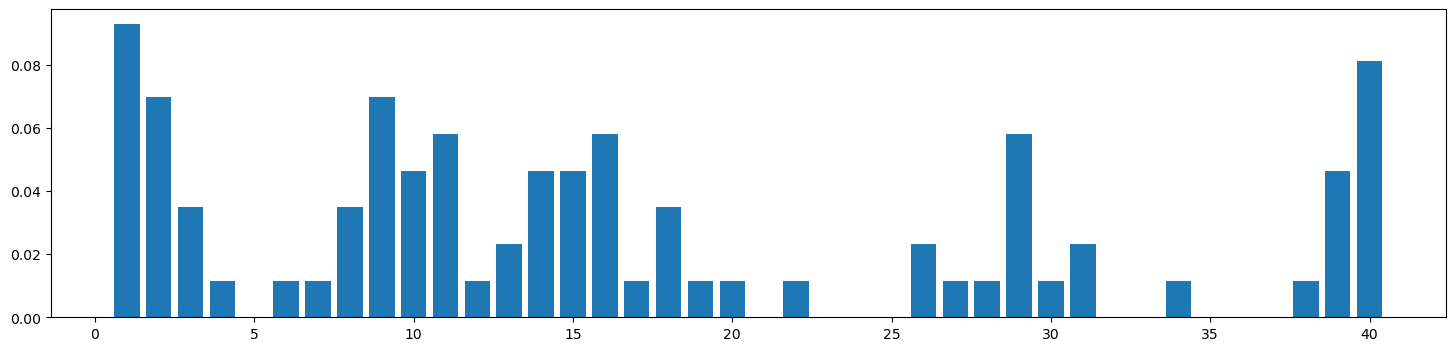

Kriol


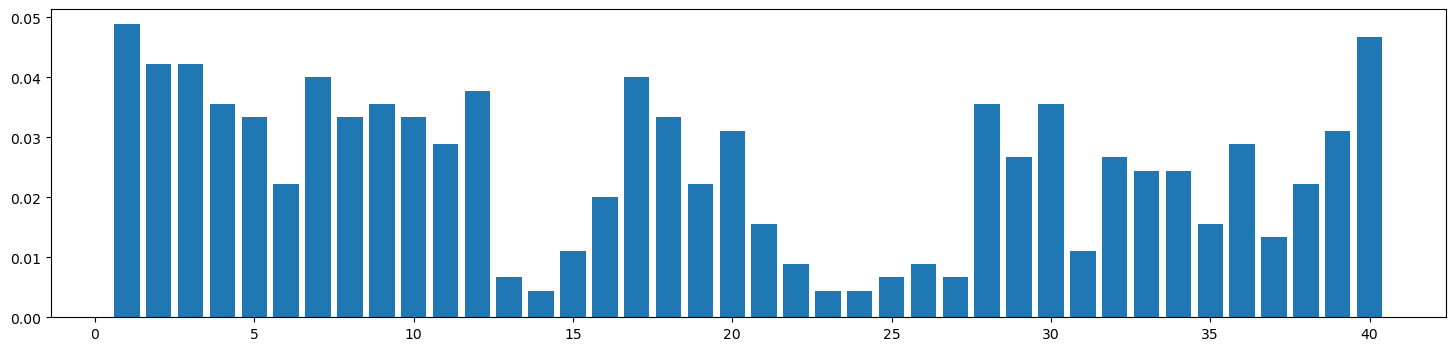

Kuku-Yalanji


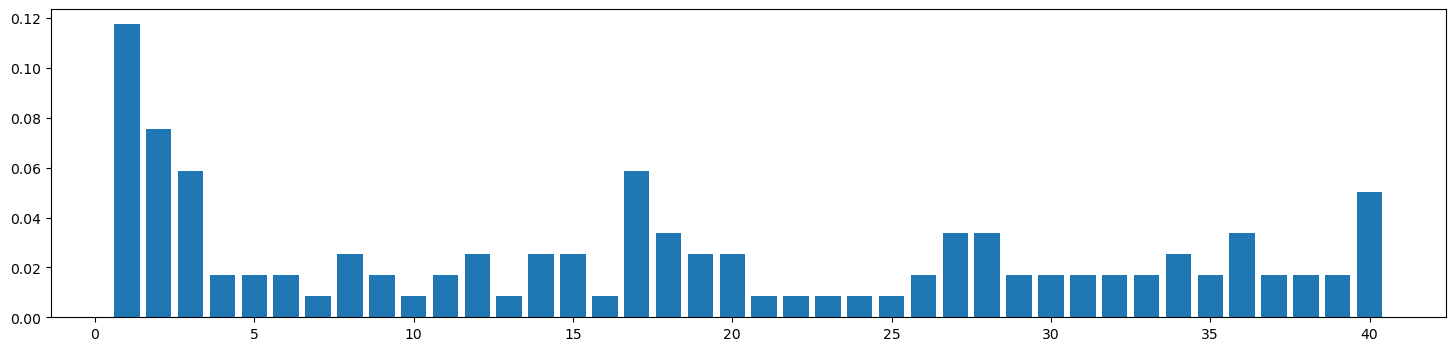

Long-haired Kuna


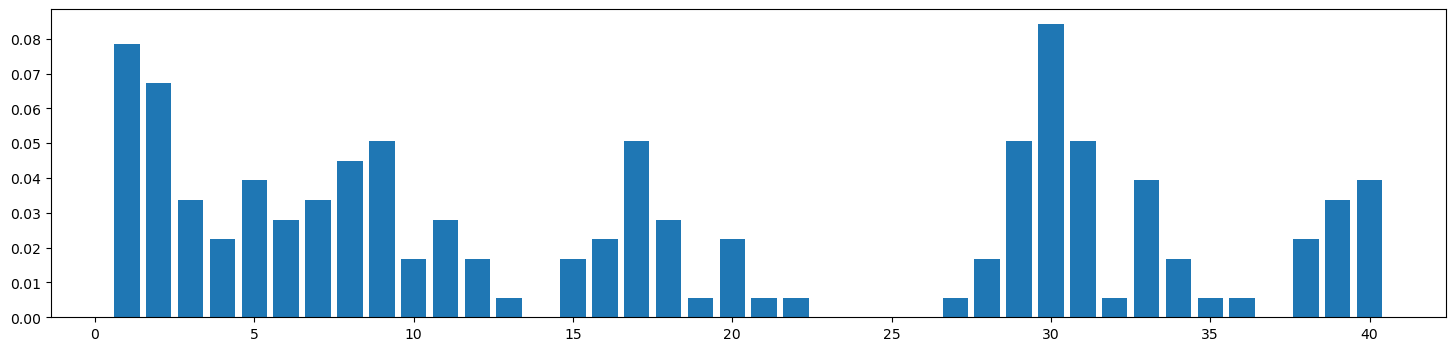

Kwerba


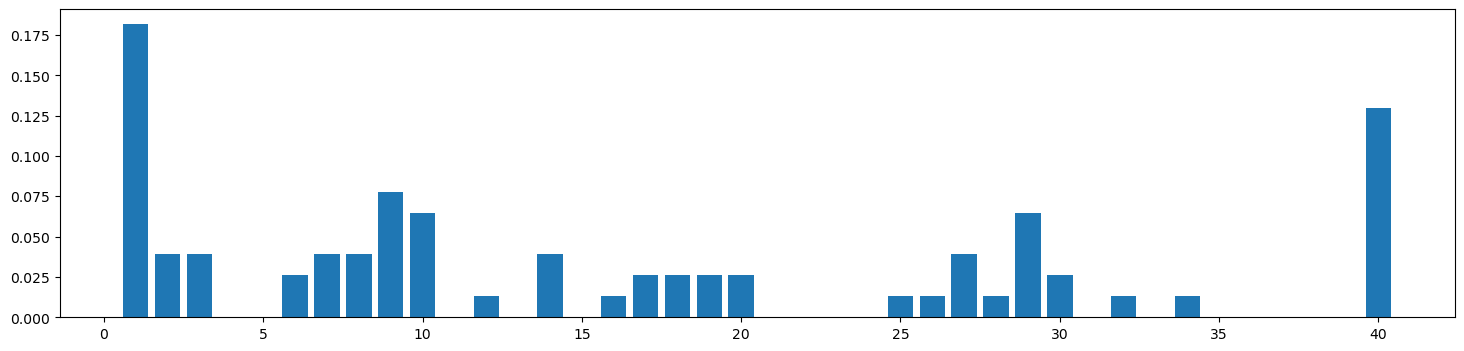

Lele


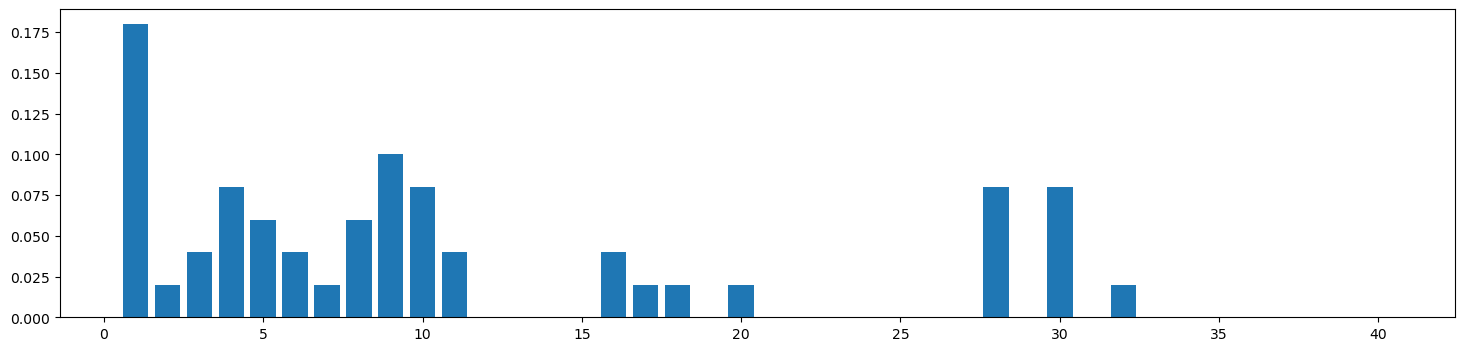

Mampruli


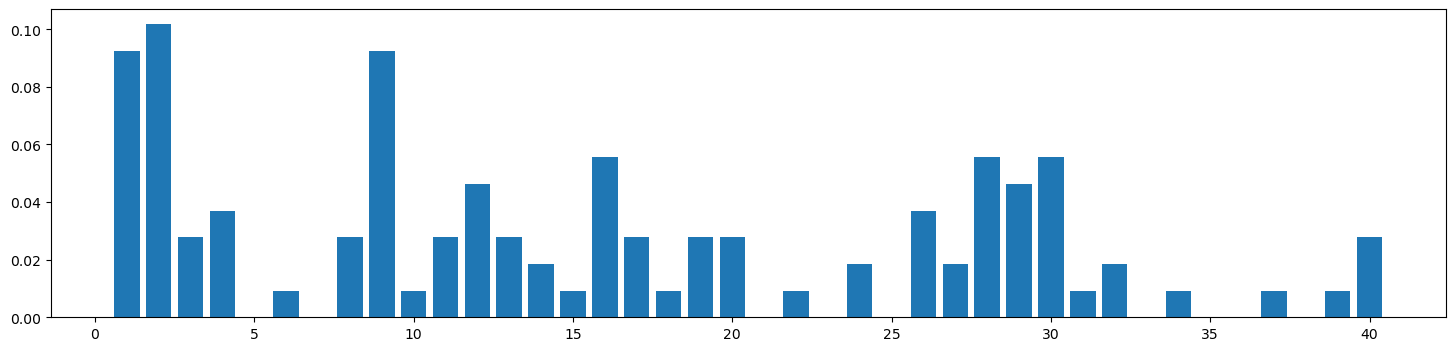

Maring


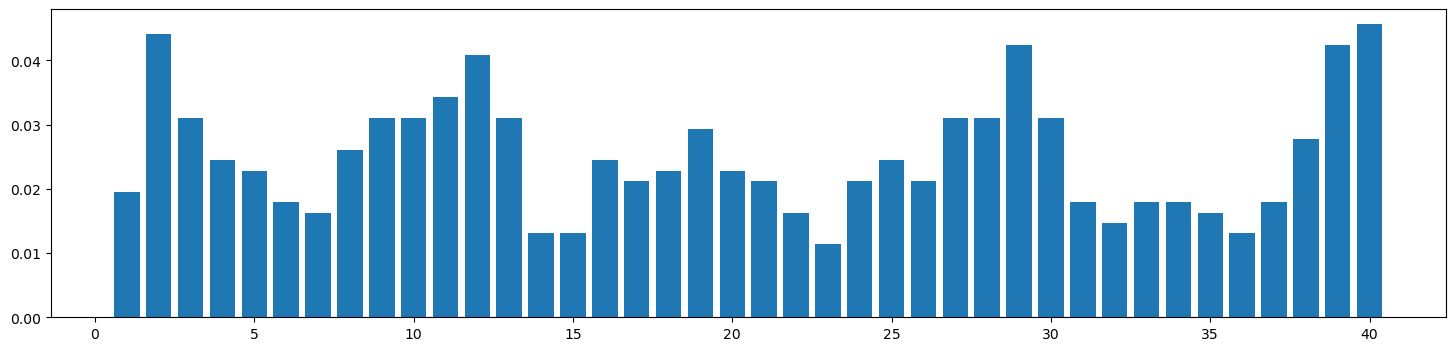

Martu Wangka


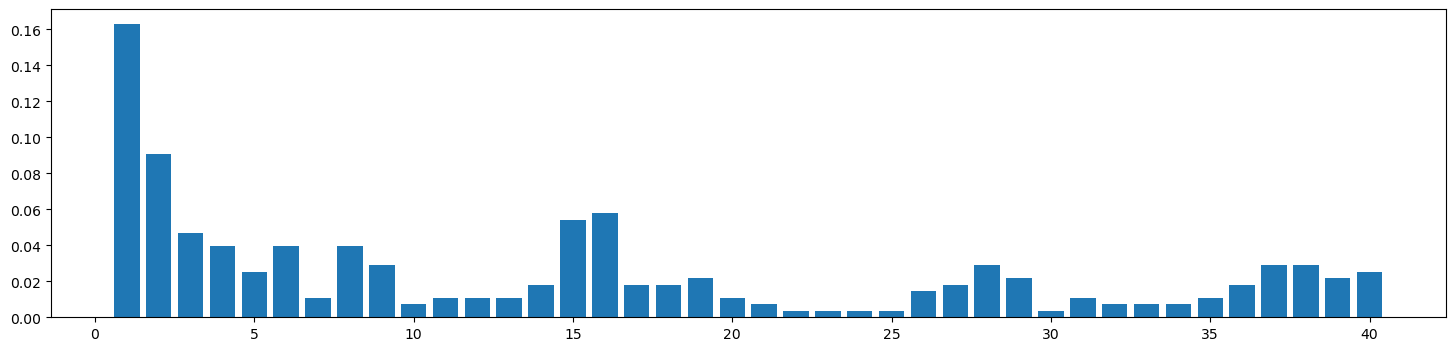

Mawchi


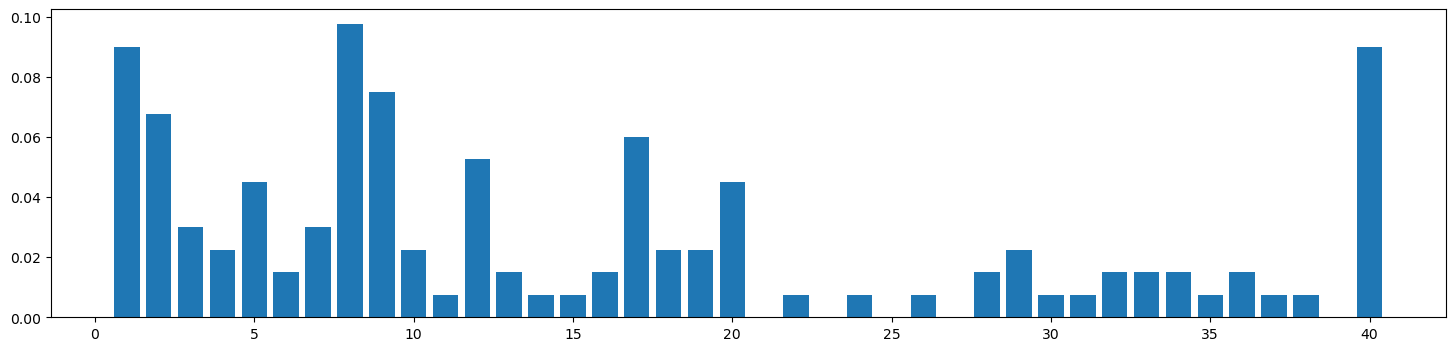

Mayoruna


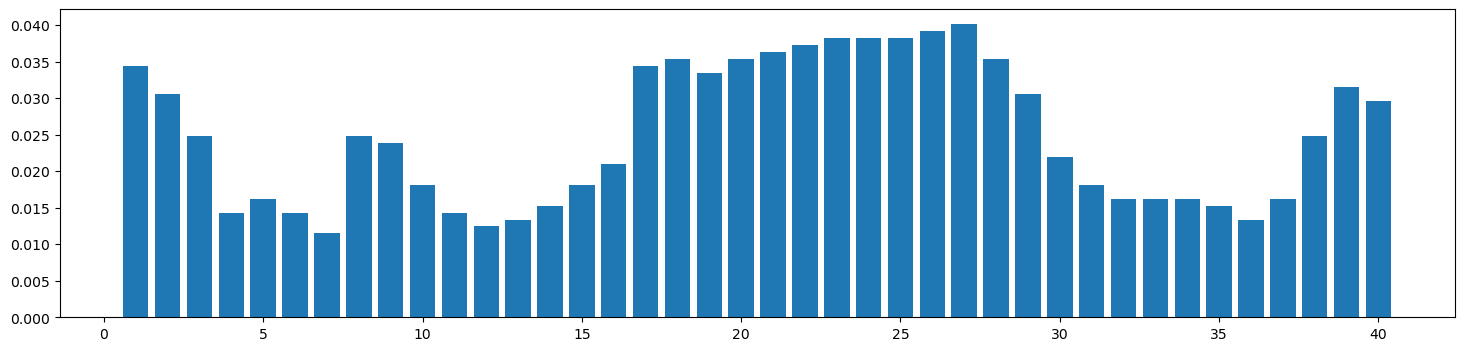

Mazahua


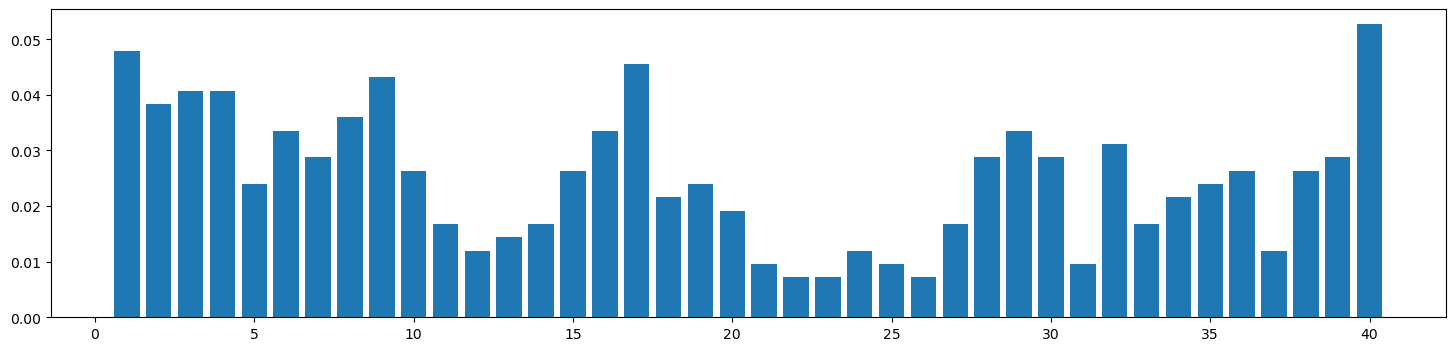

Mazateco


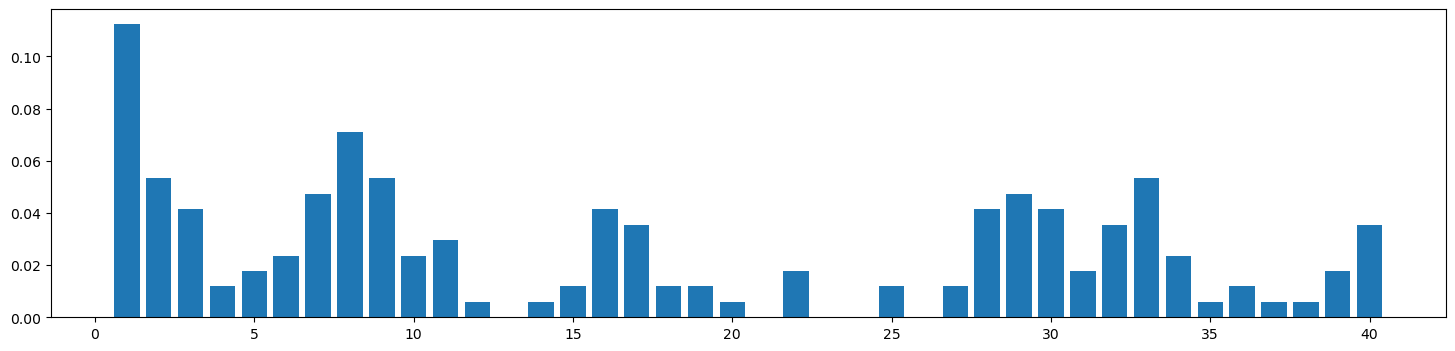

Menye


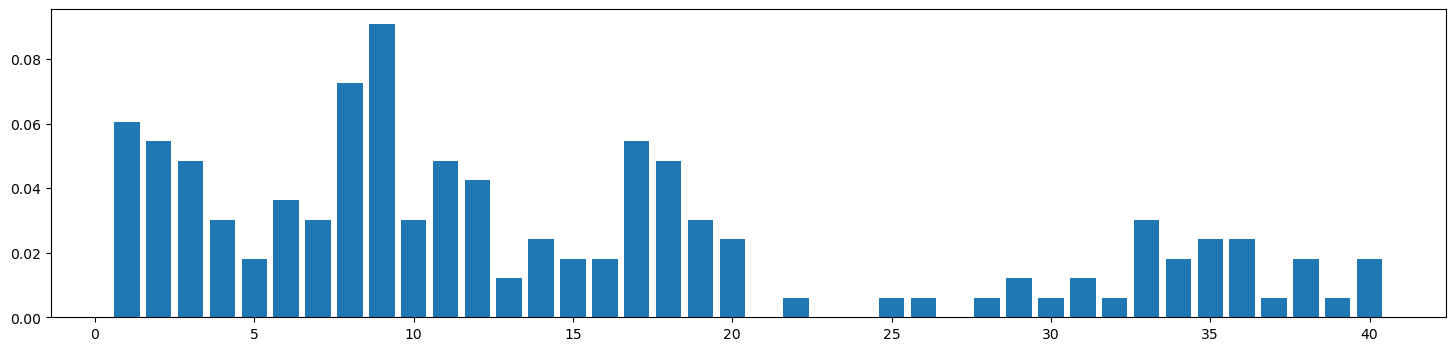

Micmac


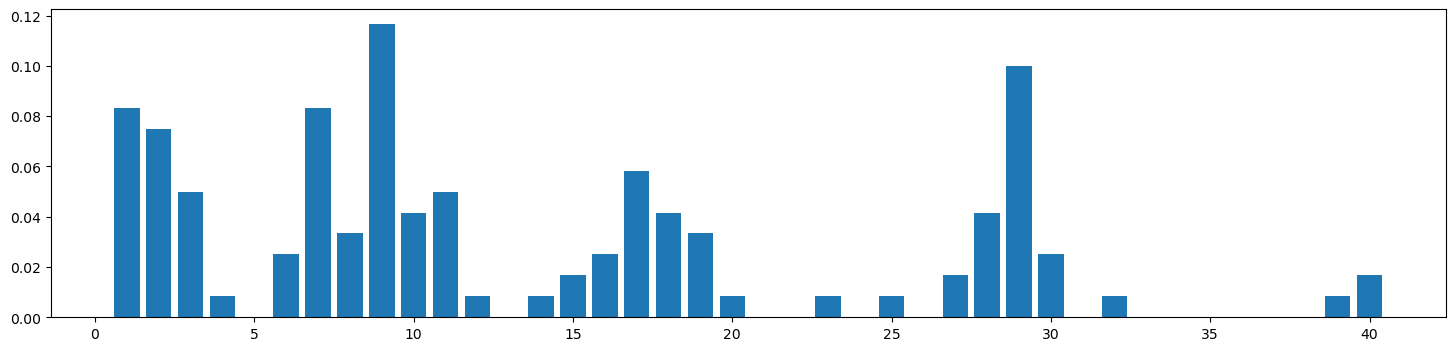

Mikasuki


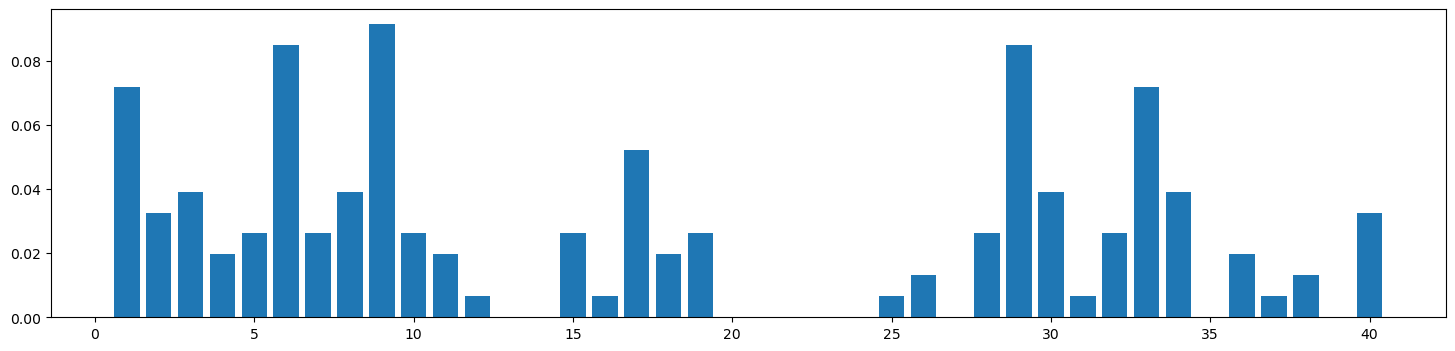

Mixteco


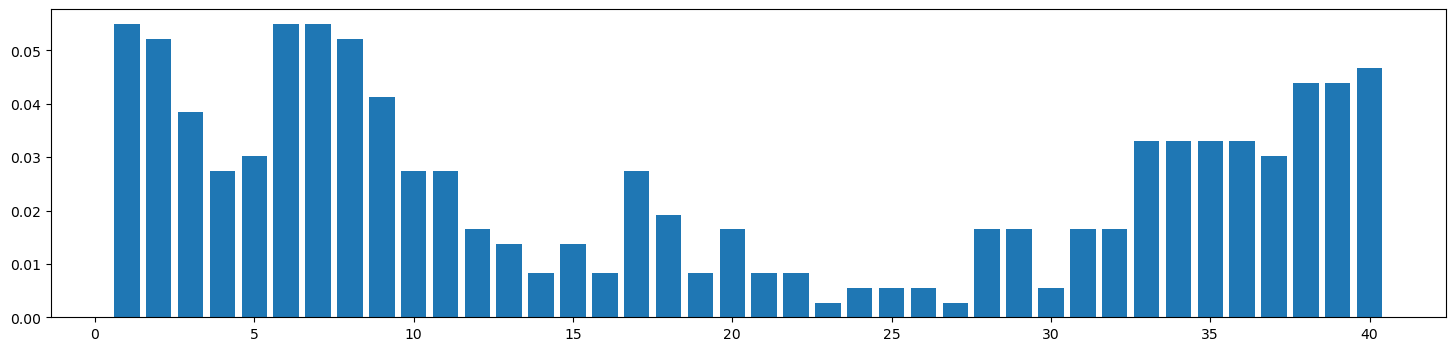

Mundu


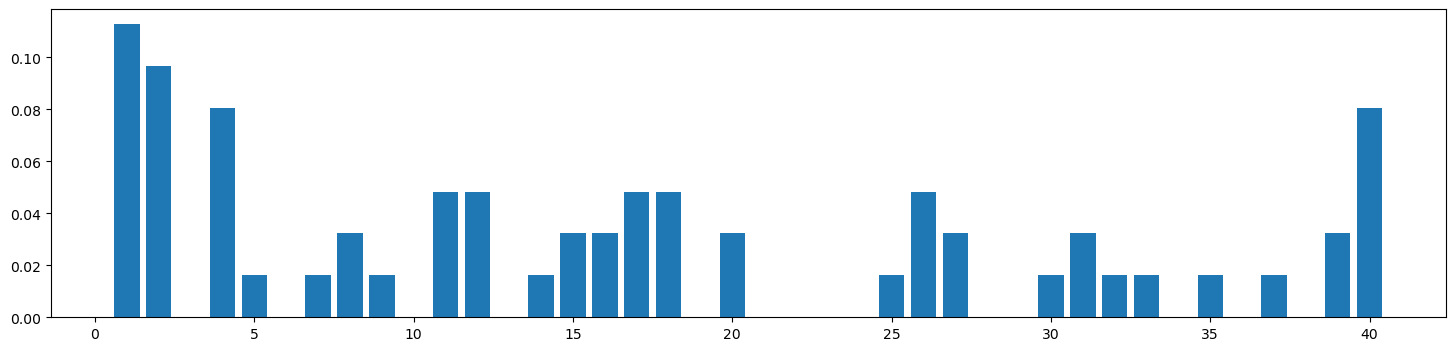

M{\x9C}ra Pirah{\x8B}


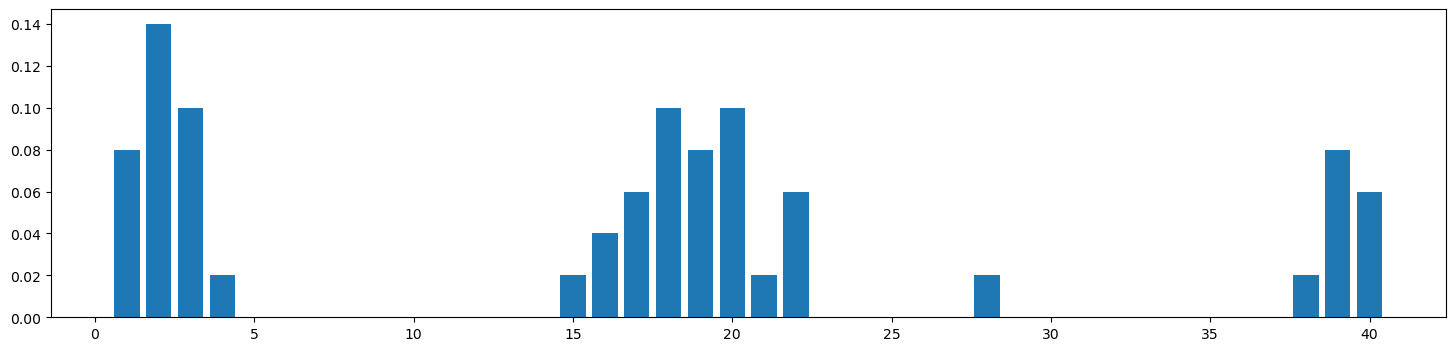

Murle


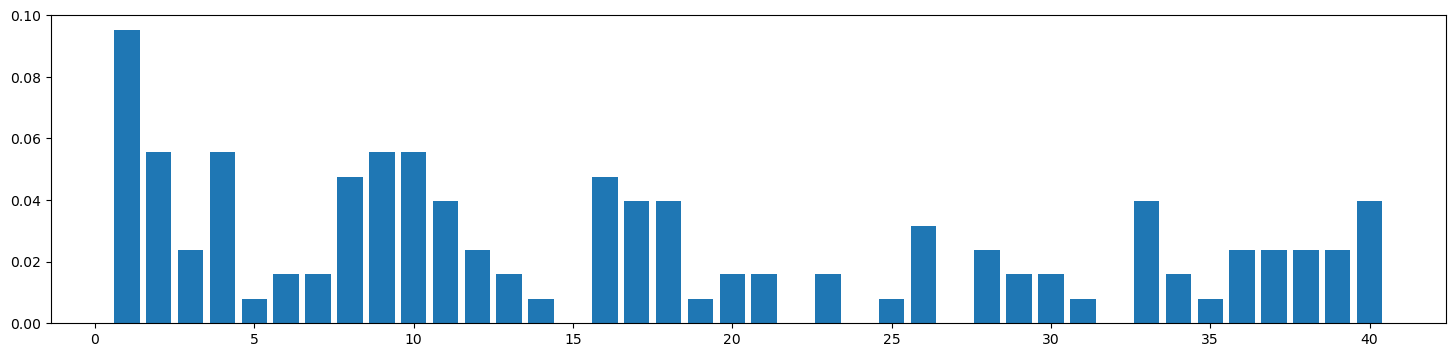

Murinbata


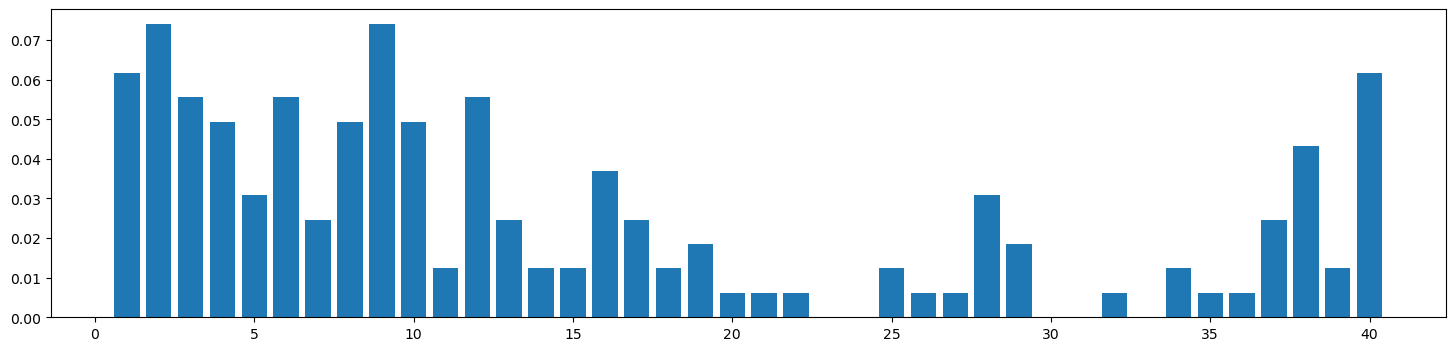

Nafaanra


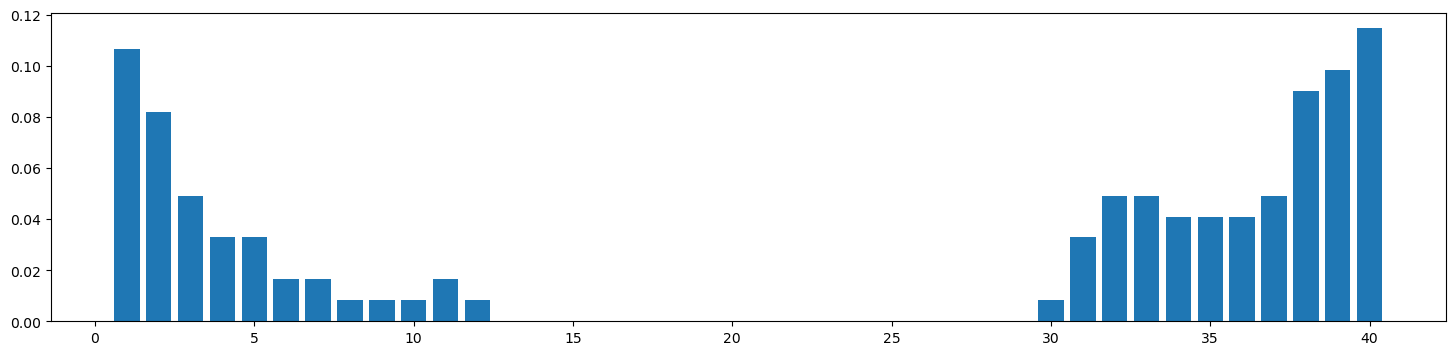

N{\x87}huatl


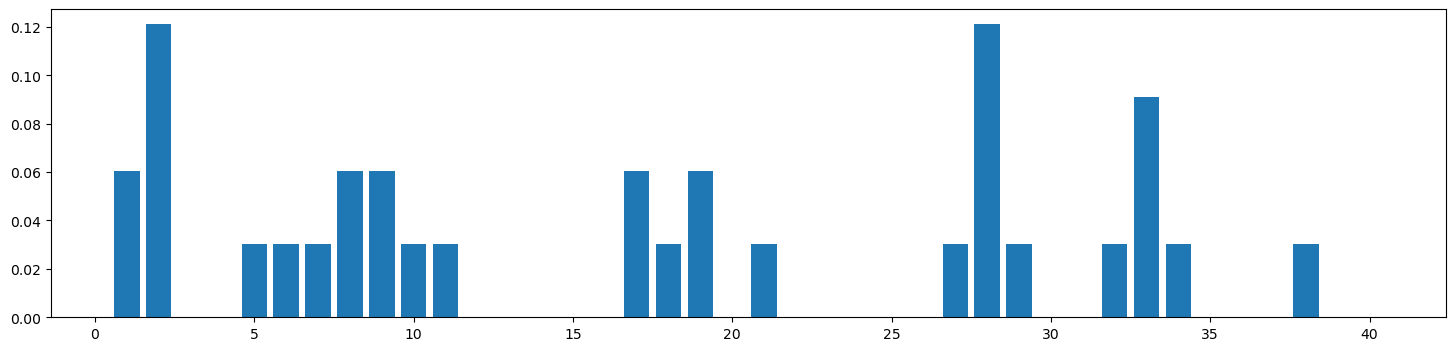

Ocaina


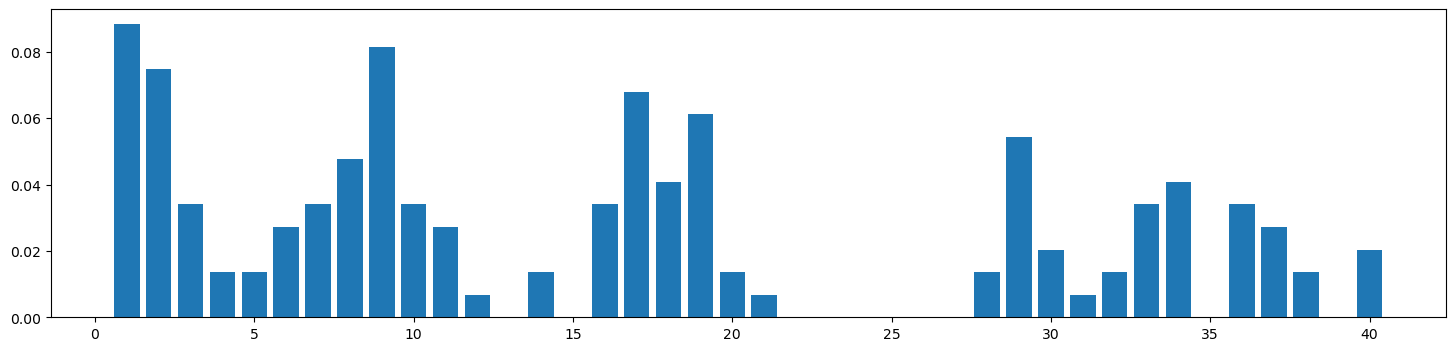

Papago


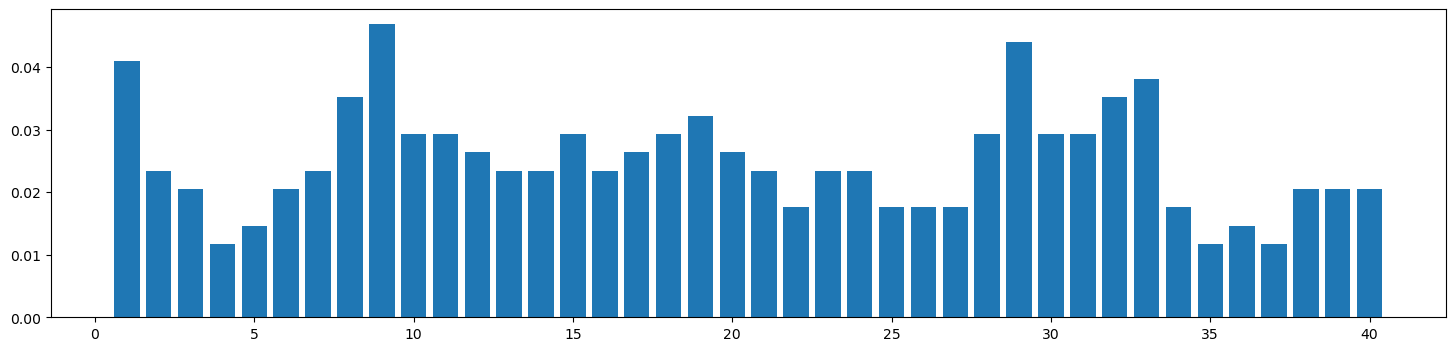

Patep


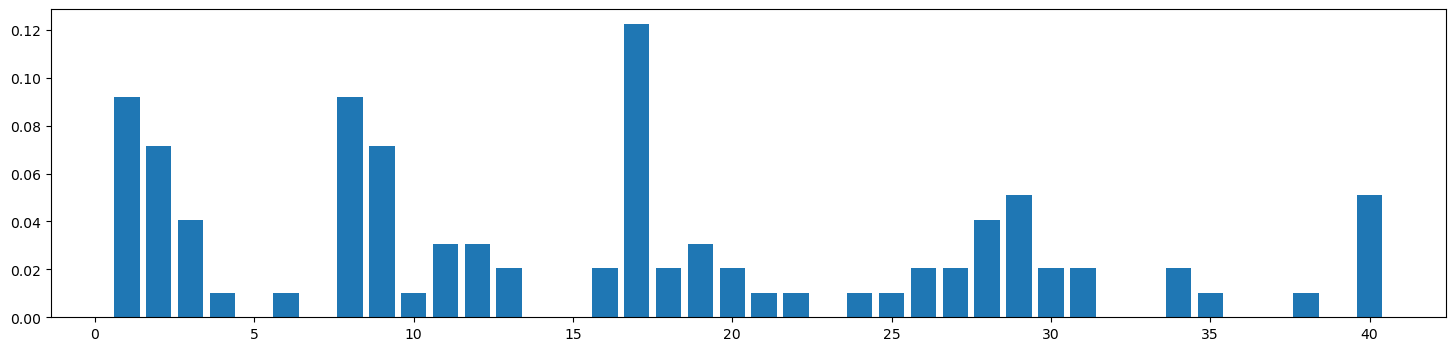

Paya


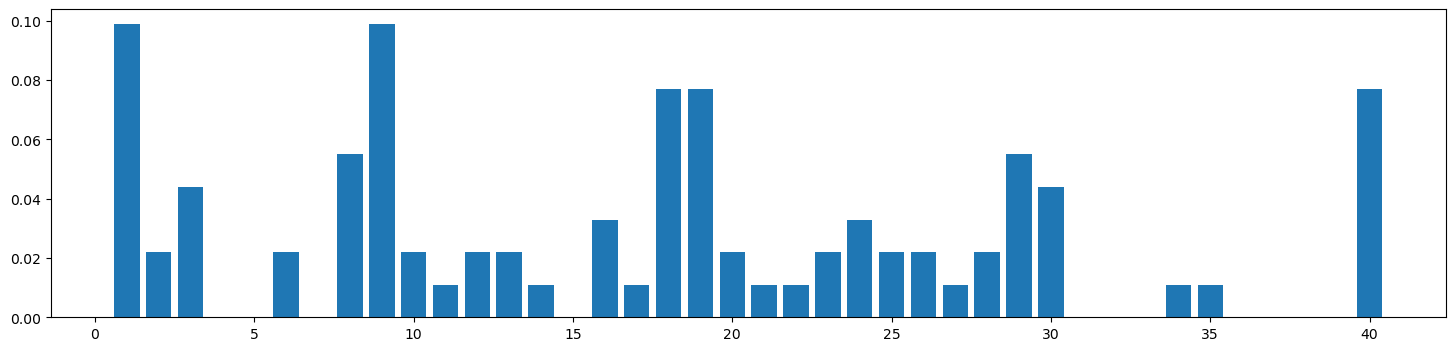

Podopa


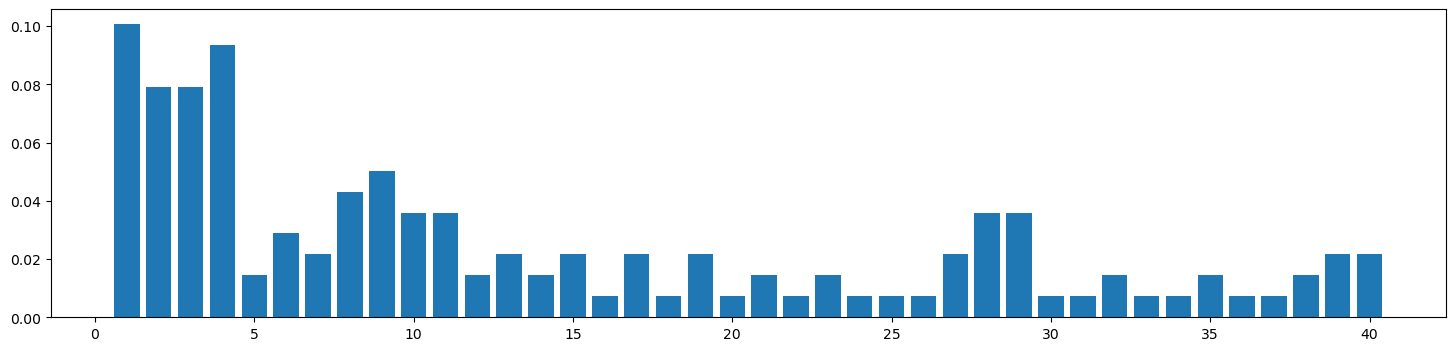

Saramaccan


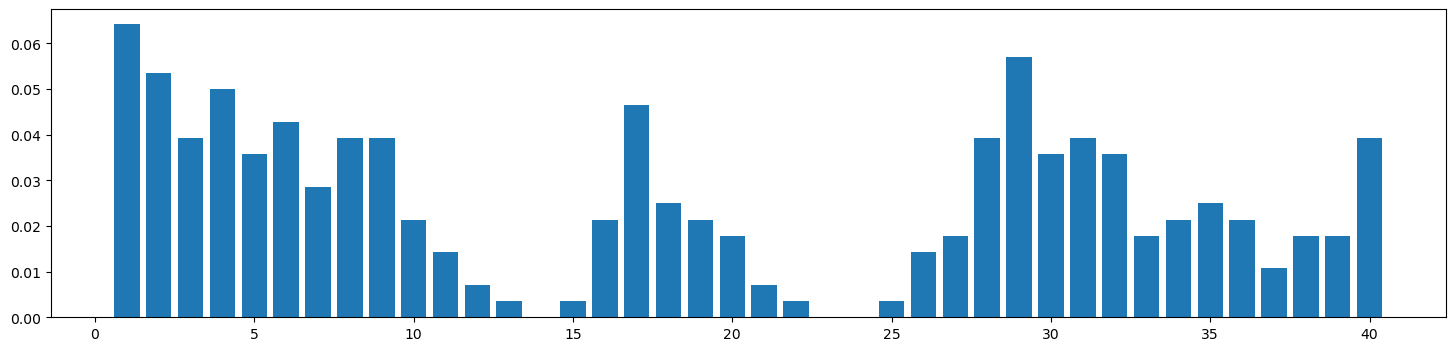

Seri


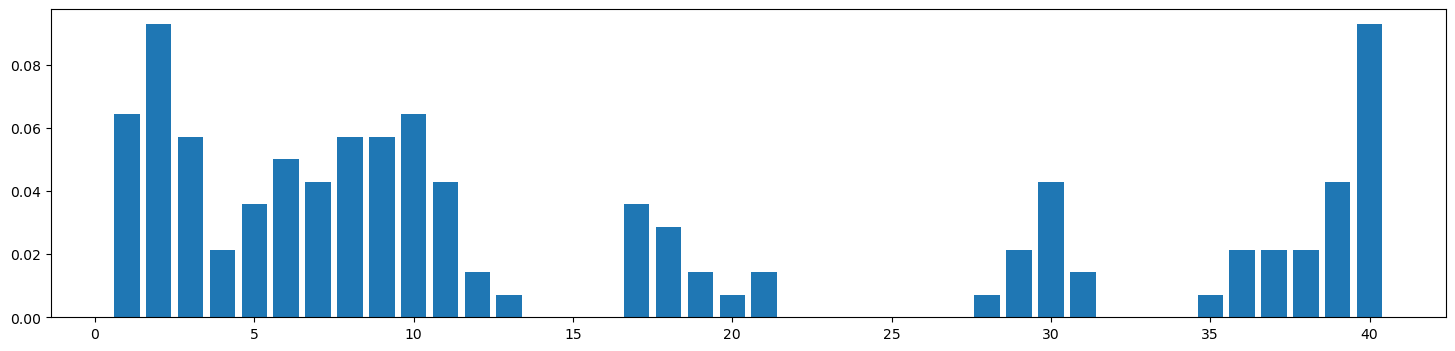

Shipibo


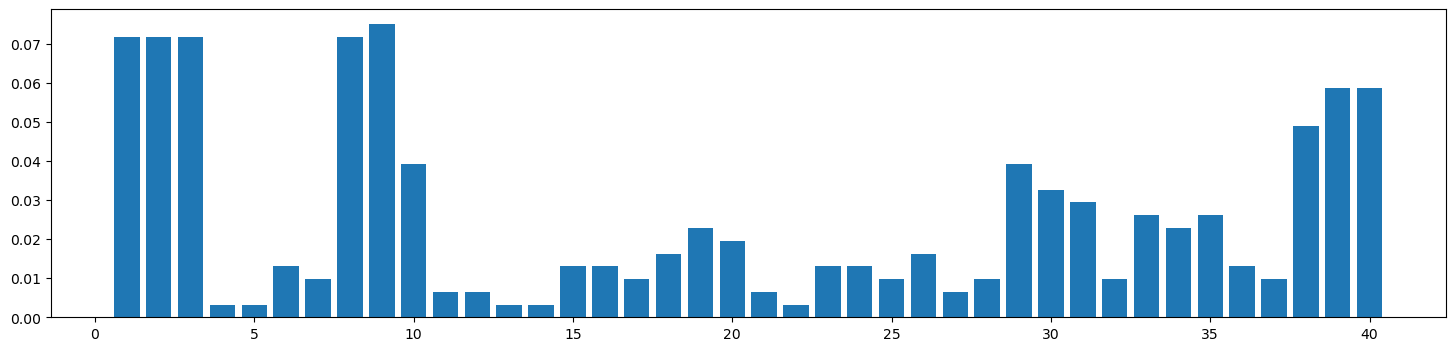

Sirion{\x97}


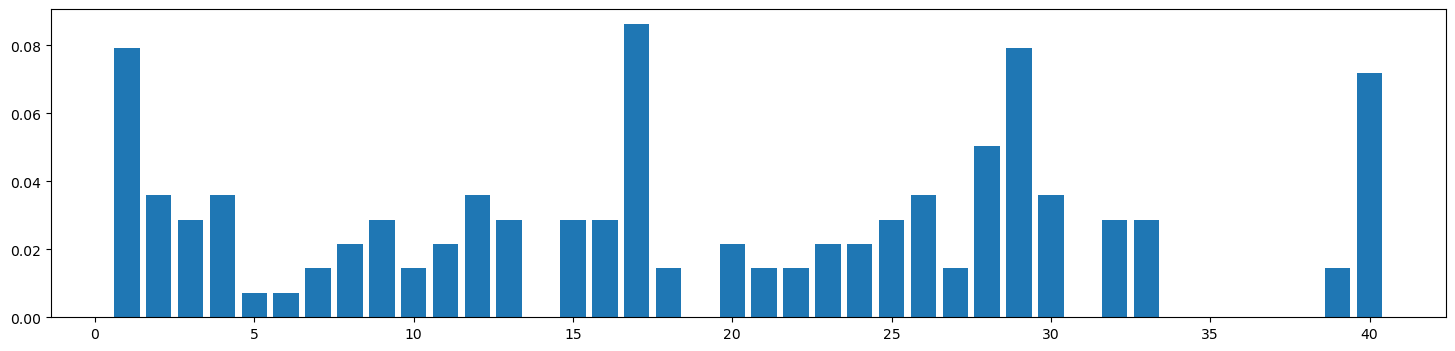

Slave


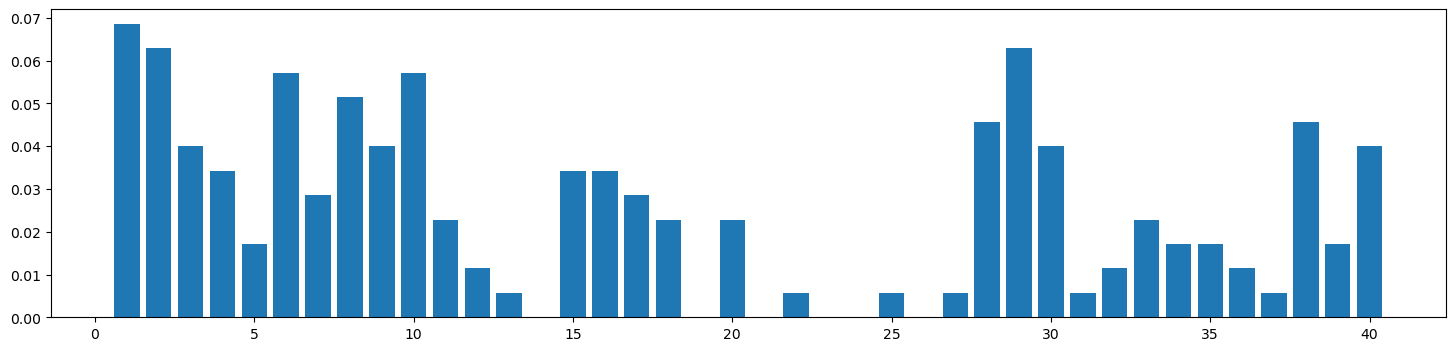

Sursurunga


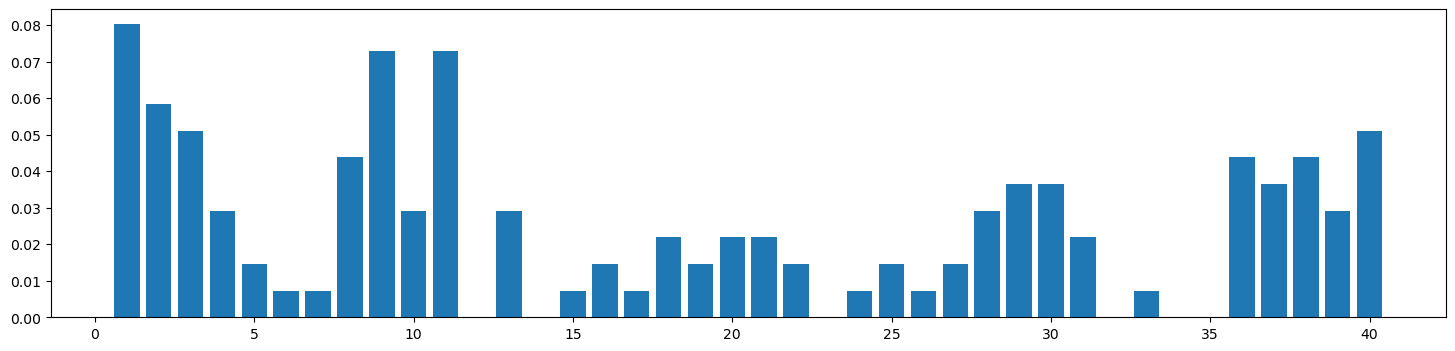

Tabla


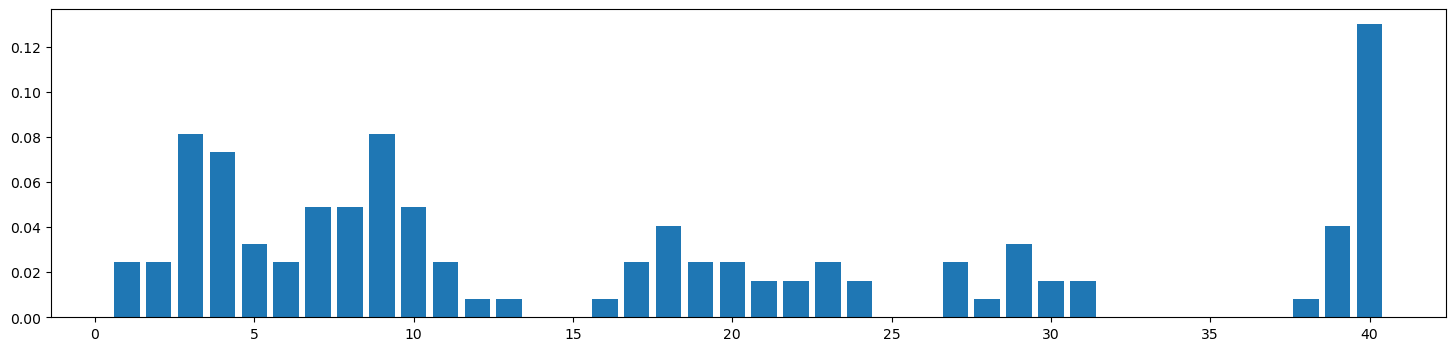

Tacana


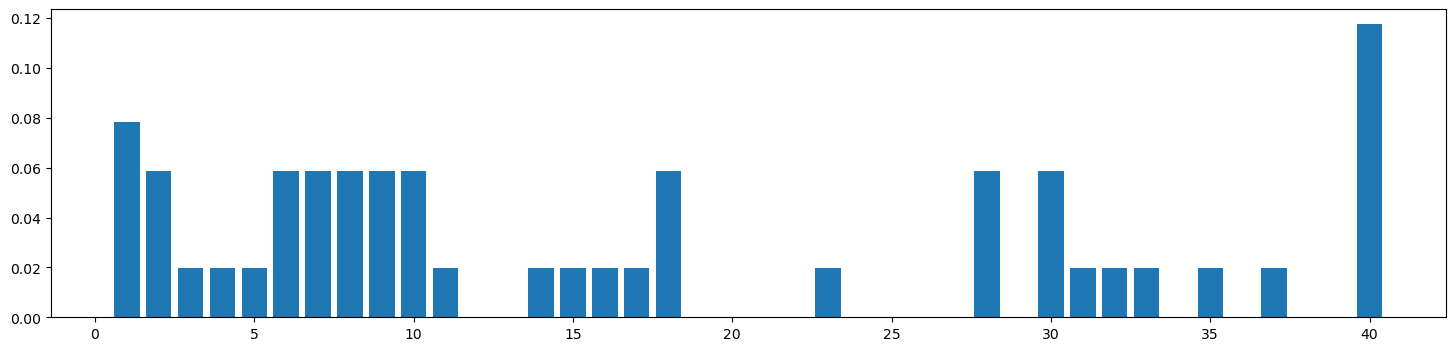

Central Tarahumara


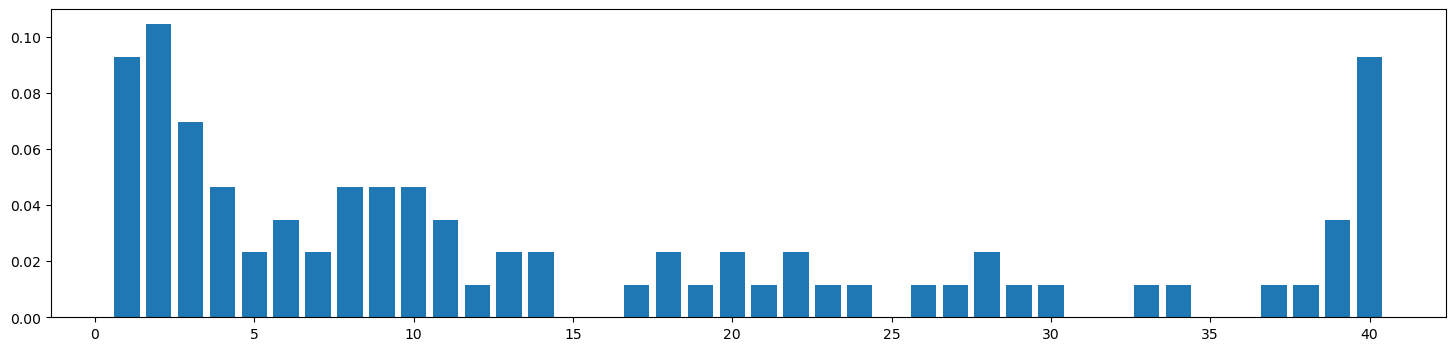

W. Tarahumara


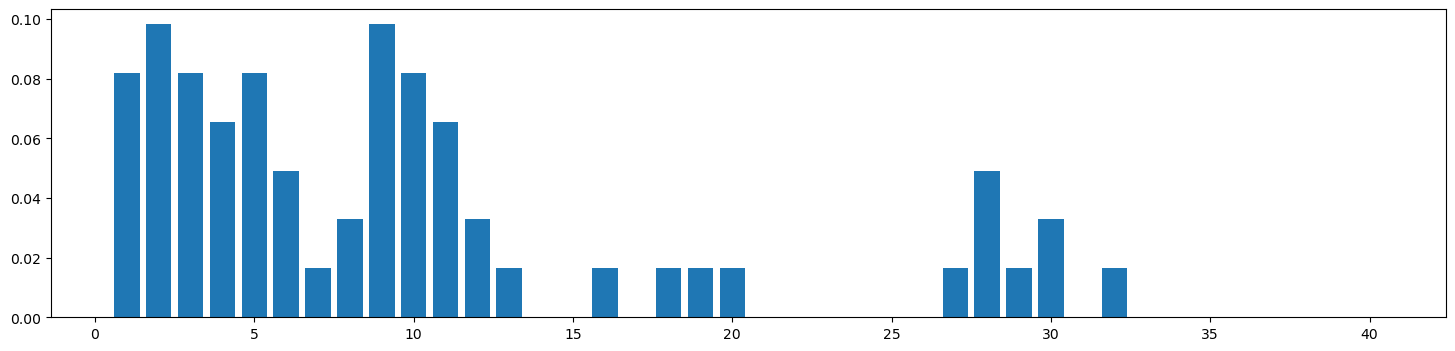

Tboli


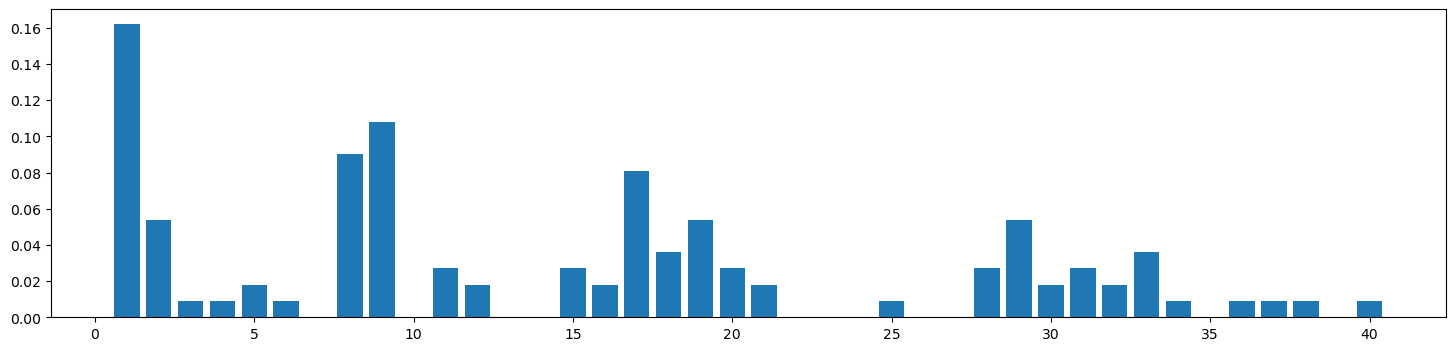

Teribe


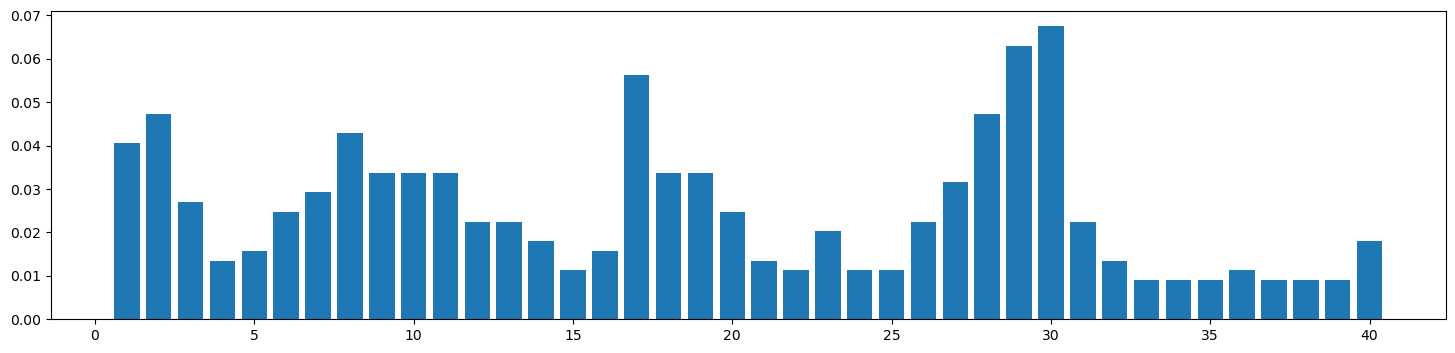

Ticuna


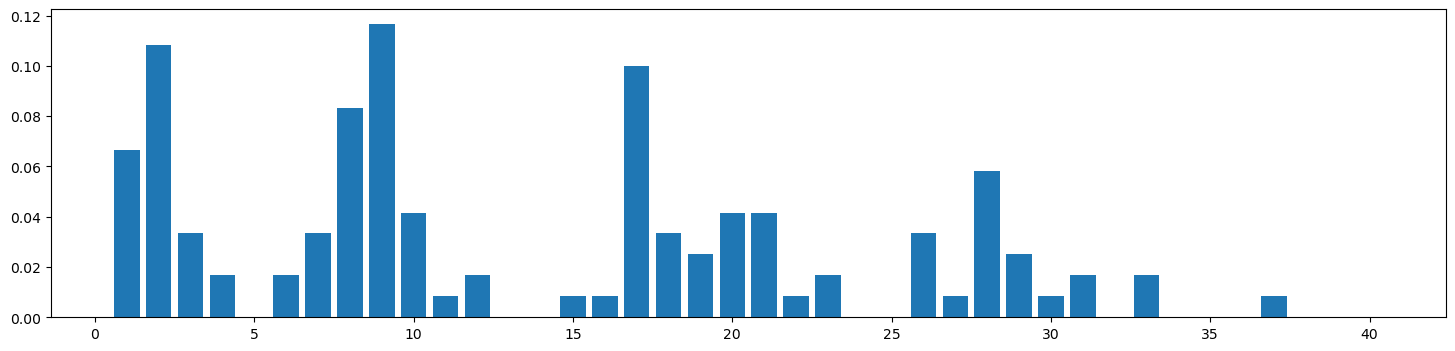

Tifal


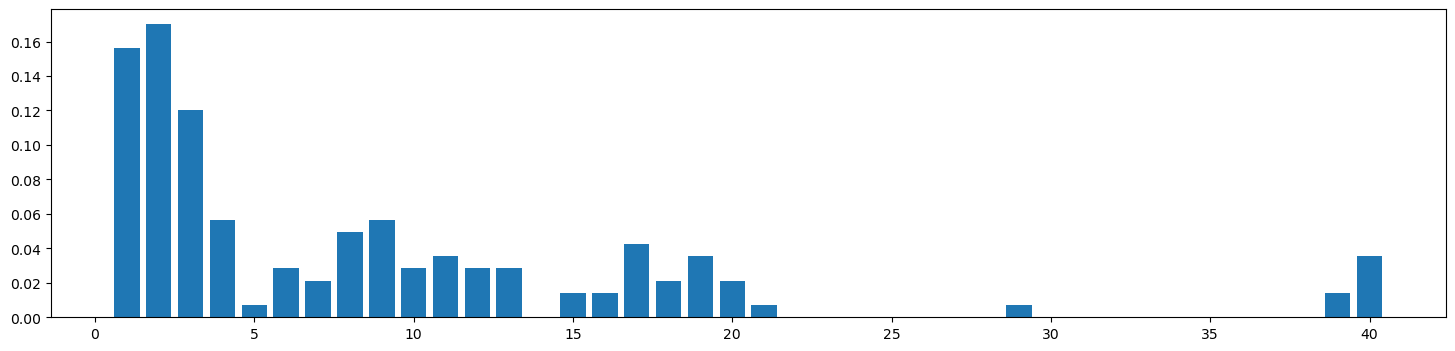

Tlapaneco


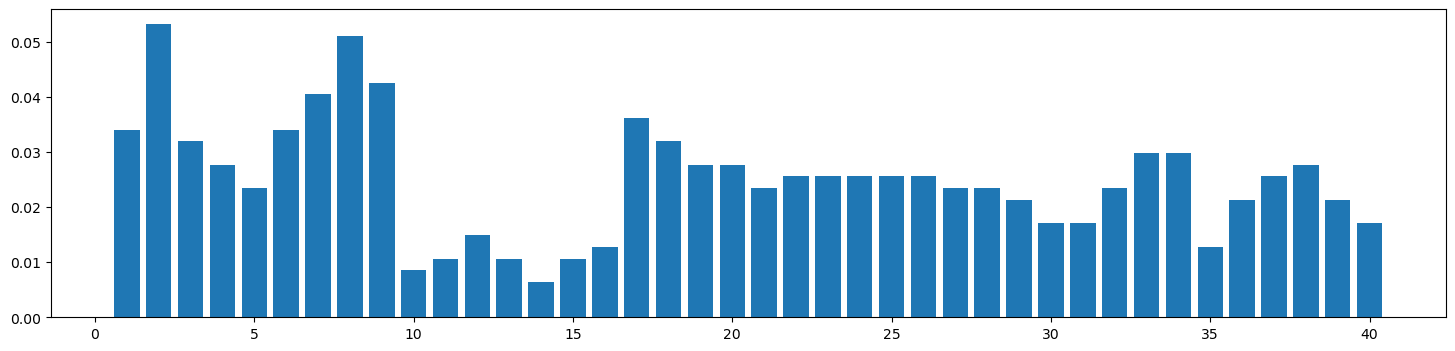

Tucano


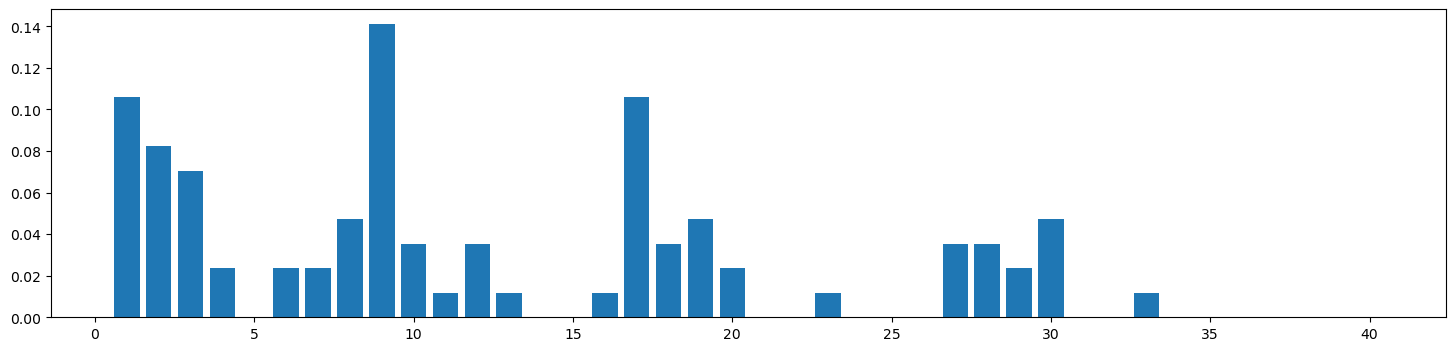

Vagla


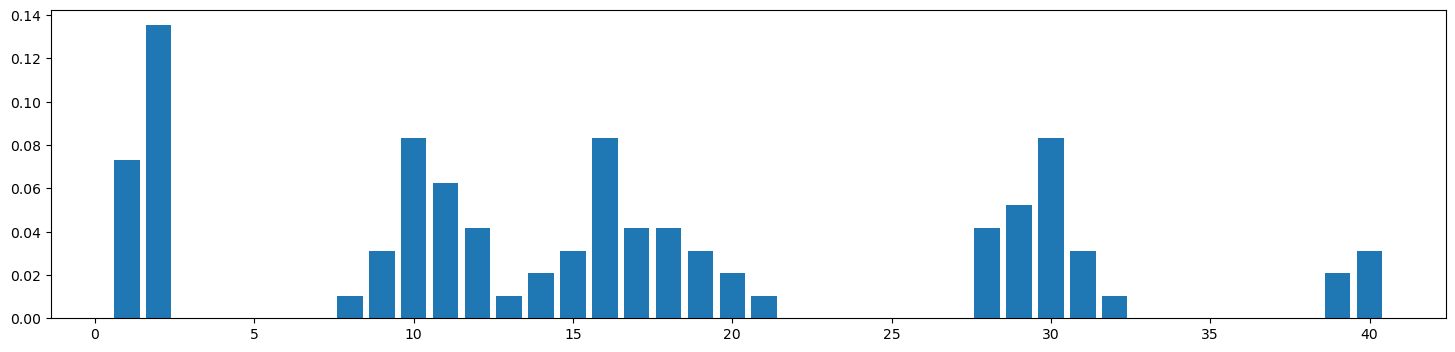

Vasavi


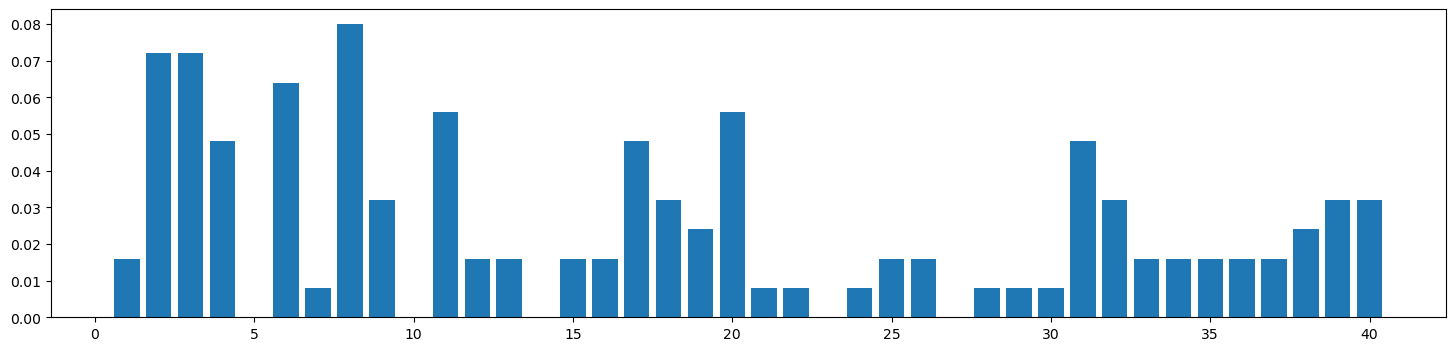

Waorani


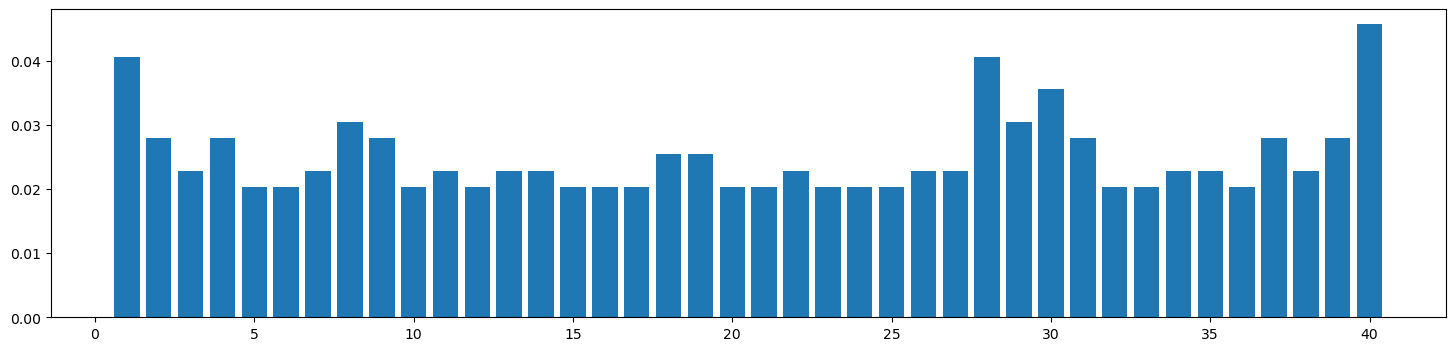

Walpiri


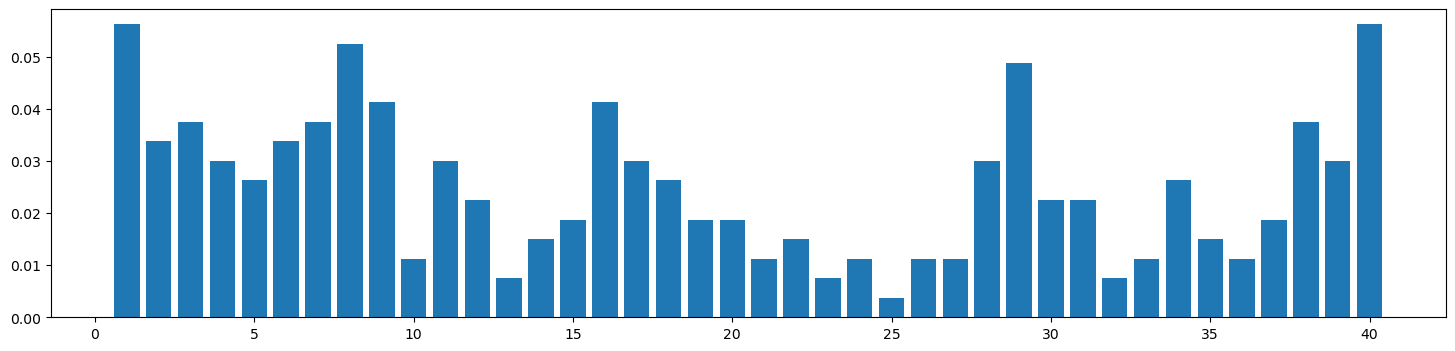

Wobe


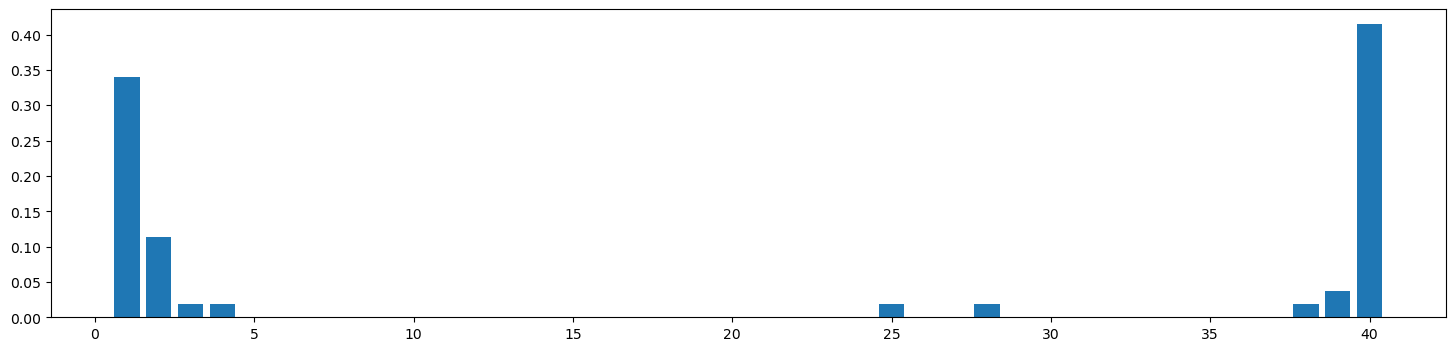

Yacouba


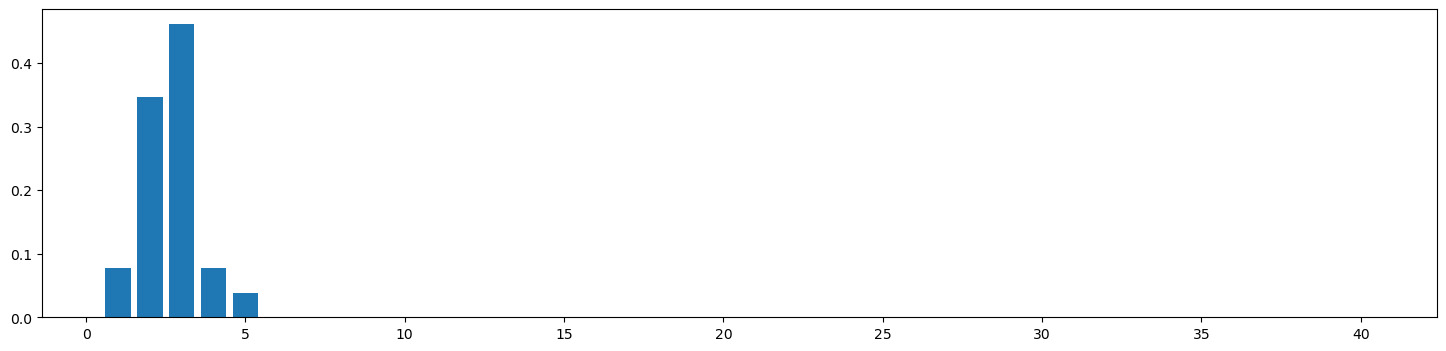

Yakan


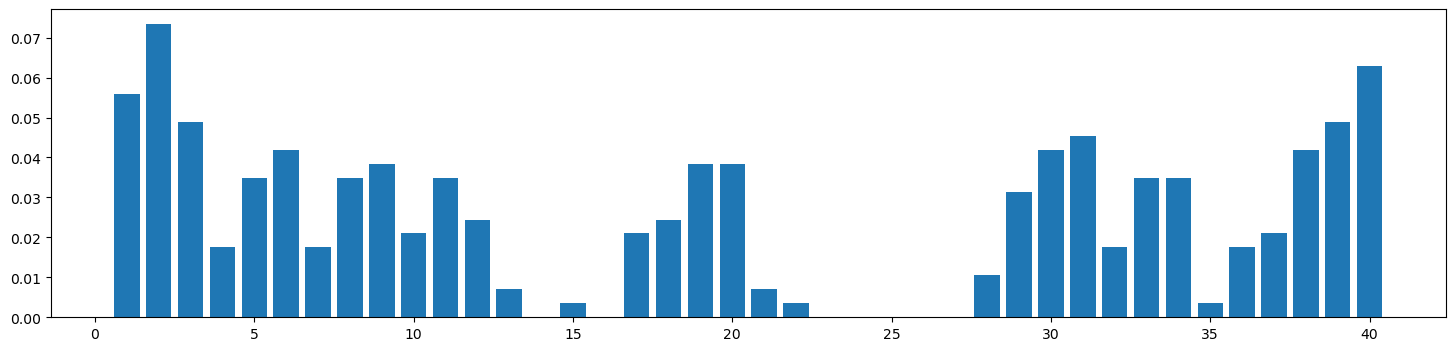

Yaminahua


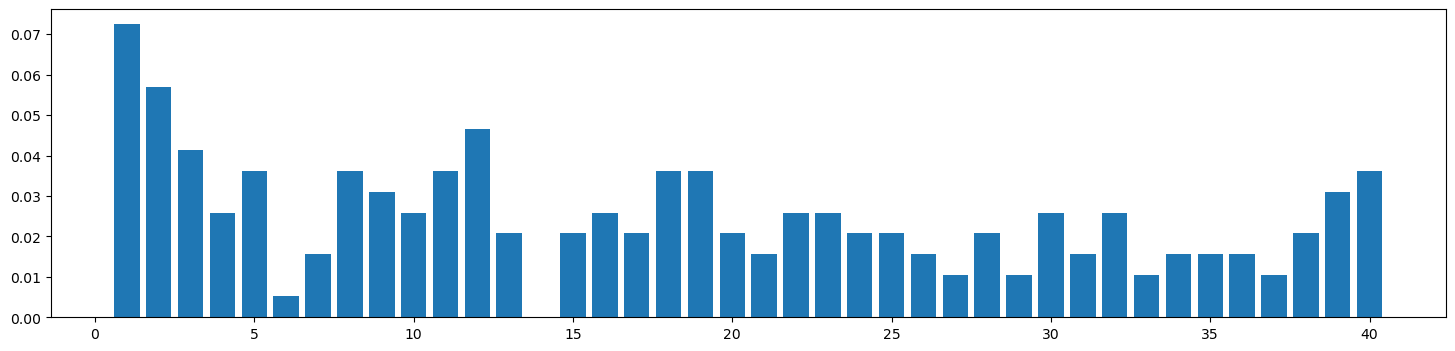

Yucuna


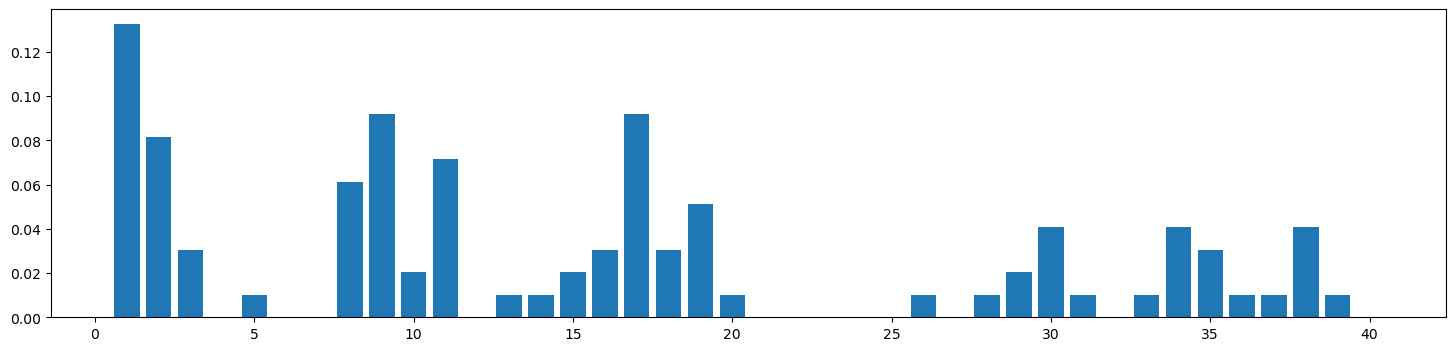

Yupik


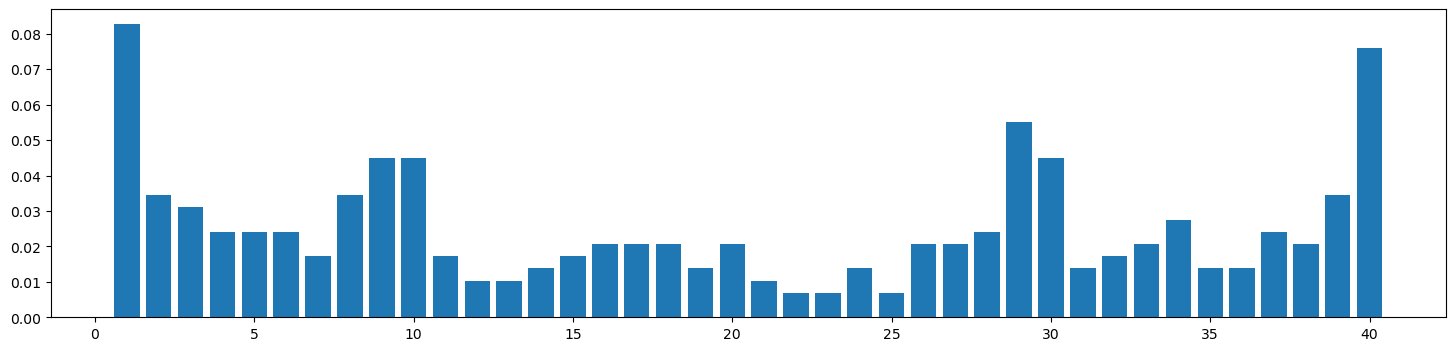

Zapoteco


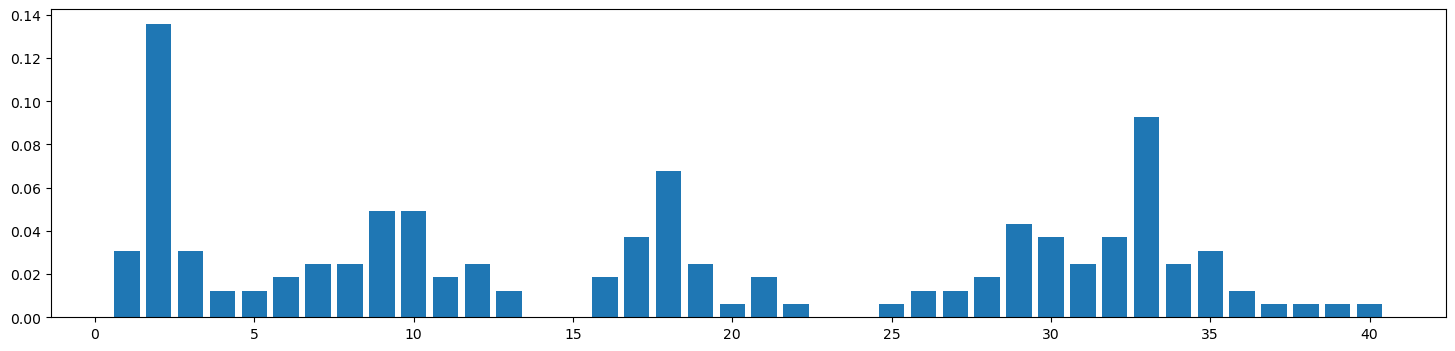

In [21]:
# now do the same for each lg in the WCS dataset, separately.
lgs = list(fdf.LgName.unique())
print ("There are", len(lgs), "different languages in the WCS.")

# d will hold counts, and prob will hold probs.
# each is keyed by lg name, and the corresponding value is a dict, in which key = col number, 
# and val = count or probability.
d = {}
prob = {}

# this just repeats what we did for one lg above, but for each lg separately, and without 
# printing out intermediate steps.
for lg in lgs:
    print(lg)
    # YOUR CODE GOES HERE.
    lg_df = fdf[fdf['LgName'] == lg]
    hpc = {}
    letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
    for letter in letters:
        for num in range(41):
            hpc[letter+str(num)] = 0
    for row, series in lg_df.iterrows():
        hpc[str(fdf['Chip'][row])] = hpc[fdf['Chip'][row]] + 1
    hpc = pd.DataFrame(hpc.items(), columns = ['Chip', 'Count'])
    # hpc = hpc[hpc['Count'] > 0]    
    # now in hpc, split apart Chip designation into separate Row and Col designations.
    hpc['Row'] = hpc.apply(lambda row: row.Chip[0], axis=1)
    hpc['Col'] = hpc.apply(lambda row: int(row.Chip[1:]), axis=1)
    hpc_pivoted = hpc.pivot(index="Row", columns="Col", values="Count")
    hpc_pivoted_trimmed = hpc_pivoted.loc['B' : 'I'].loc[:, hpc_pivoted.columns != 0]
    
    d = {}  # dict for counts, as above.
    for col in cols:
        d[col] = hpc_pivoted_trimmed[col].sum()    
    prob = {} # dict for probabilities, as above.
    total = sum(d.values())
    for col in cols:
        prob[col] = d[col] / total
    plot_distrib(prob)
        # note that we are printing out only prob distribs, not the counts on which they are based.
        # plot_distrib(prob[lg]) 

### How do individual languages compare to the aggregate distribution we saw earlier?

To answer this, we will need a measure of how similar or dissimilar two probability distributions are.  For this, we will use the [Kullback–Leibler (or KL) divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence), also called relative entropy.  The KL divergence $D_{KL}(P \mid\mid Q)$ measures how different a distribution $Q$ is from a given reference distribution $P$.  Generally, $P$ represents data and $Q$ represents some approximation to or model of the data.  $D_{KL}(P \mid\mid Q)$ then measures the amount of information lost when using $Q$ to approximate $P$.  The asymmetry in this definition is deliberately highlighted here, as the KL divergence is not symmetric: 

$D_{KL}(P \mid\mid Q) \ne D_{KL}(Q \mid\mid P)$

In our case, $P$ will be the language-specific distributions of focus choices over grid columns that we just obtained, and $Q$ will be the aggregate distribution that we obtained earlier.  So in each case we ask how well the aggregate distribution models or approximates the language-specific data.  Concretely, we will ask which of the language-specific distributions $P$ is best approximated by the aggregate distribution $Q$ such that $D_{KL}(P \mid\mid Q)$ is minimized, and which is worst approximated by it such that $D_{KL}(P \mid\mid Q)$ is maximized.

What is the KL-divergence?  It is an information-theoretic measure that is related to others we have already seen, such as entropy and mutual information.  The formula for KL divergence is:

\begin{equation}
D_{KL}(P \mid\mid Q) = - \sum_{i=1}^n P(x_i) \log \frac{Q(x_i)}{P(x_i)}
\end{equation}

Whenever $P(x_i)$ is zero the contribution of the corresponding term in the sum is interpreted as zero, such that we needn't worry about division by zero.  The KL divergence is defined only if $Q(x) = 0 \implies P(x) = 0, \forall x$; otherwise we would have $\log 0$, which is undefined.  We are taking $Q$ to be the aggregate distribution, which as we saw above has no zero counts in it, so we should avoid this potential problem.

The KL divergence is always greater than or equal to zero.  You should be able to convince yourself that it reaches zero when $P(x_i) = Q(x_i), \forall i$.

---
**4 points for the following cell**:
- 2 points for calculating the main formula correctly
- 2 points for avoiding division by zero

In [22]:
def kl_divergence(p,q):
    """
    KL divergence between 2 distribs p and q.
    we assume each is represented as a dict, with key = outcome and val = prob of outcome.
    we also assume p and q have the same keys.
    """
    total = 0.0
    # YOUR CODE GOES HERE.
    for key in p.keys():
        if p[key] != 0:
            total -= p[key] * math.log(q[key]/p[key])
    return(total)

---
**6 points for the following cell**:
- 2 points for respecting the asymmetry of KL divergence and correctly measuring it with P and Q assigned to language-specific and aggregate distributions as specified above
- 2 points for correctly identifying the language best approximated by the WCS aggregate distribution
- 2 points for correctly identifying the language worst approximated by the WCS aggregate distribution

WCS aggregate distribution


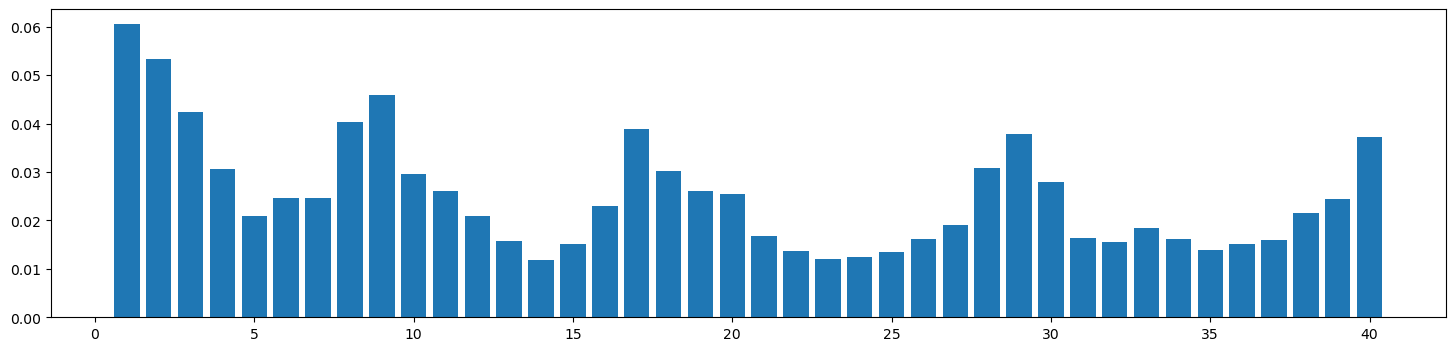

Language best approximated by WCS aggregate distribution: Kamano-Kafe
KL divergence: 0.043244244117984755


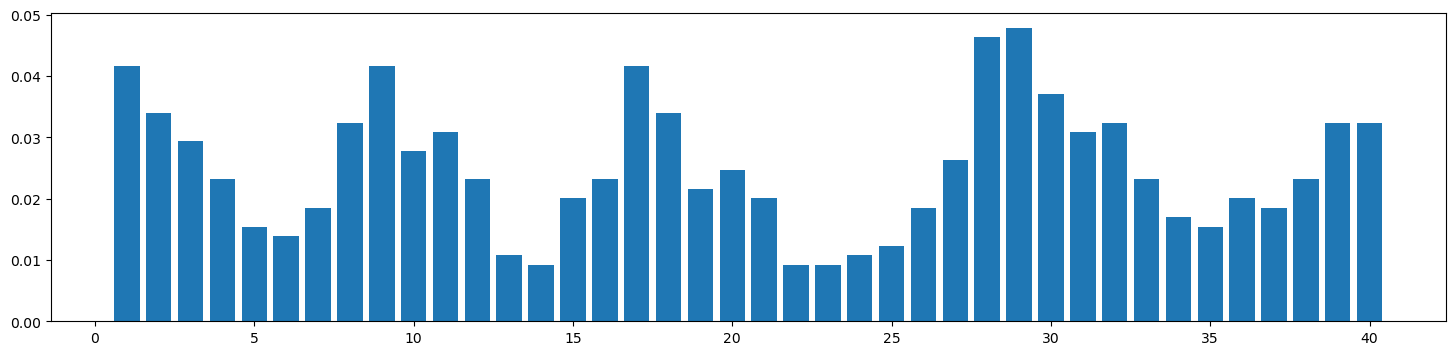

Language worst approximated by WCS aggregate distribution: Yacouba
KL divergence: 1.863554022609852


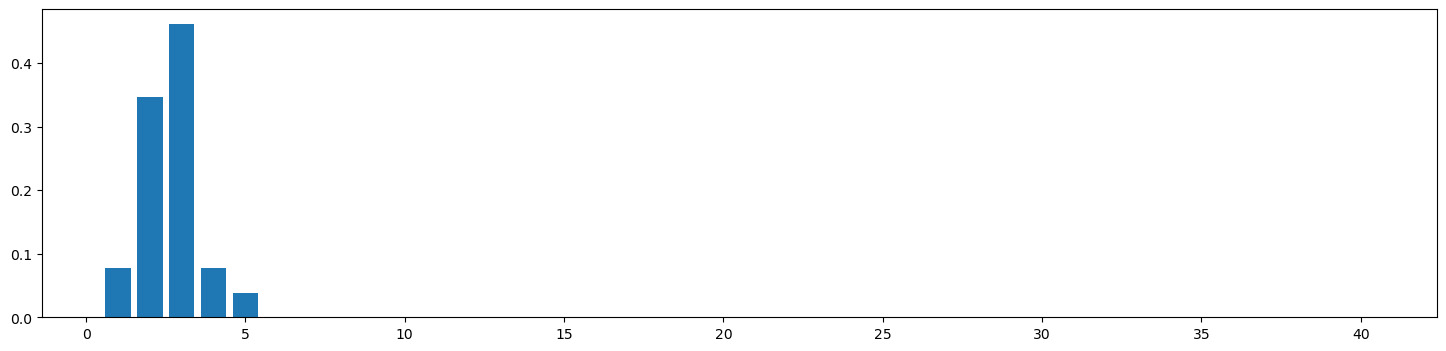

In [23]:
# at this point, we have focus distribs for each lg, and an aggregate WCS distrib based on all lgs.
# now measure KL divergence between each lg distrib and the aggregate distrib.
# pick out the lgs with min and max KL divergence with aggregate.

# YOUR CODE GOES HERE.
min_kl = 100.0
min_kl_lg = None
max_kl = 1.0
max_kl_lg = None
prob = {}
for lg in lgs:
    lg_df = fdf[fdf['LgName'] == lg]
    hpc = {}
    letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
    for letter in letters:
        for num in range(41):
            hpc[letter+str(num)] = 0
    for row, series in lg_df.iterrows():
        hpc[str(fdf['Chip'][row])] = hpc[fdf['Chip'][row]] + 1
    hpc = pd.DataFrame(hpc.items(), columns = ['Chip', 'Count'])
    # hpc = hpc[hpc['Count'] > 0]    
    # now in hpc, split apart Chip designation into separate Row and Col designations.
    hpc['Row'] = hpc.apply(lambda row: row.Chip[0], axis=1)
    hpc['Col'] = hpc.apply(lambda row: int(row.Chip[1:]), axis=1)
    hpc_pivoted = hpc.pivot(index="Row", columns="Col", values="Count")
    hpc_pivoted_trimmed = hpc_pivoted.loc['B' : 'I'].loc[:, hpc_pivoted.columns != 0]
    d = {}  # dict for counts, as above.
    for col in cols:
        d[col] = hpc_pivoted_trimmed[col].sum()    
    prob2 = {} # dict for probabilities, as above.
    total = sum(d.values())
    for col in cols:
        prob2[col] = d[col] / total
    approx = kl_divergence(prob2, prob_wcs)
    if approx > max_kl:
        max_kl = approx
        max_kl_lg = lg
        prob[lg] = prob2
    if approx < min_kl:
        min_kl = approx
        min_kl_lg = lg
        prob[lg] = prob2
    
        
# now print out results.
print("WCS aggregate distribution")
plot_distrib(prob_wcs)
        
print("Language best approximated by WCS aggregate distribution:", min_kl_lg)
print("KL divergence:", min_kl)
plot_distrib(prob[min_kl_lg])

print("Language worst approximated by WCS aggregate distribution:", max_kl_lg)
print("KL divergence:", max_kl)
plot_distrib(prob[max_kl_lg])

---
**4 points for observations and conclusions**:
- 1 point for observations
- 3 points for conclusions drawn from the observations

# Observations and conclusions

Please summarize your observations here, and say what conclusions you can draw from what you have seen.  A short paragraph should be adequate, but please separate out observations and conclusions.

The closest language, Kmano-Kafe, is quite close to the aggregate distribution, while the language farthest from the aggregate distribution, the Yacouba language, is very different. However the Yacouba language appears to be very simple on this metric, only ranging from about 1-5. To me this suggests that they only have one color term, or maybe one color term with different ways of conveying shade, but ultimately a very different way of representing color. My guess is this way of representing color would have to be simpler than other languages, based off of this data, although this data isn't the whole story. To me, this data on its own doesn't take away from the aggregate distribution that much, because a language this simple couldn't possibly follow the aggregate distribution. I would be more interested to see if there are other languages that do have a similar complexity while still veering from the aggregate distribution.

---
**4 points for the following cell, on optional extensions - but those points will be awarded only if you are not already at full credit.**

# Extensions (optional)

You are warmly invited to follow up on any initial conclusions, or any other idea that occurs to you, by conducting further analyses of your own devising on the same dataset.

WCS aggregate distribution


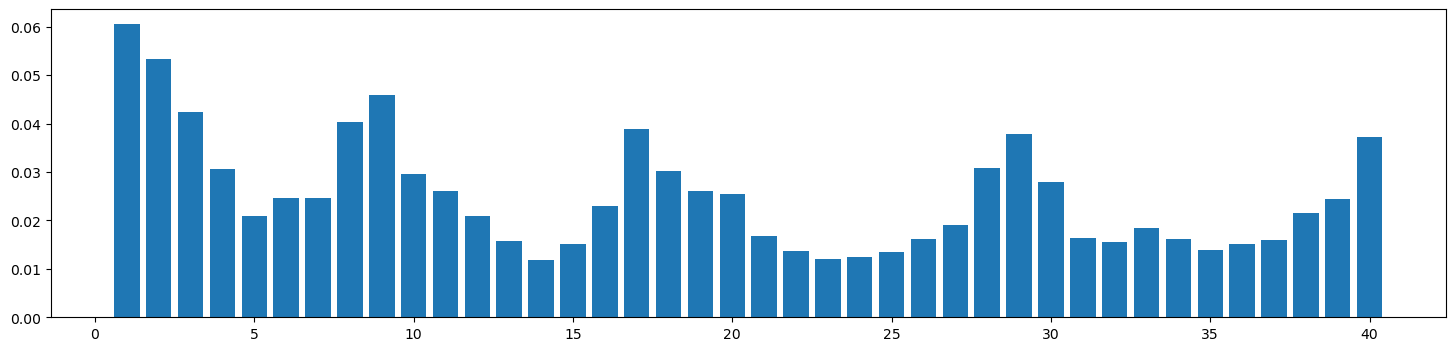

Language worst approximated by WCS aggregate distribution: Jicaque
KL divergence: 0.46589804473383384


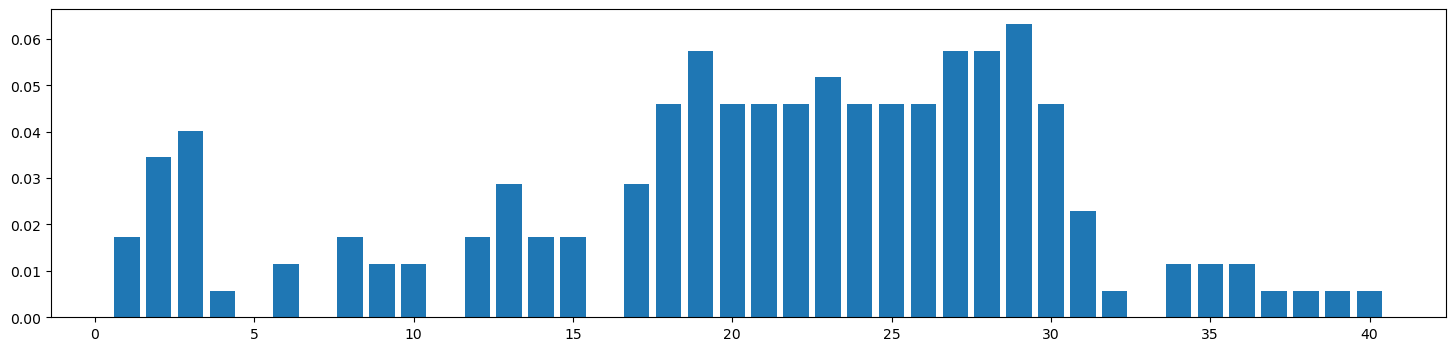

In [24]:
# YOUR OPTIONAL EXTENSION MAY GO HERE.
min_kl = 100.0
min_kl_lg = None
max_kl = 0.001
max_kl_lg = None
prob = {}
for lg in lgs:
    lg_df = fdf[fdf['LgName'] == lg]
    hpc = {}
    letters = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']
    for letter in letters:
        for num in range(41):
            hpc[letter+str(num)] = 0
    for row, series in lg_df.iterrows():
        hpc[str(fdf['Chip'][row])] = hpc[fdf['Chip'][row]] + 1
    hpc = pd.DataFrame(hpc.items(), columns = ['Chip', 'Count'])
    # hpc = hpc[hpc['Count'] > 0]    
    # now in hpc, split apart Chip designation into separate Row and Col designations.
    hpc['Row'] = hpc.apply(lambda row: row.Chip[0], axis=1)
    hpc['Col'] = hpc.apply(lambda row: int(row.Chip[1:]), axis=1)
    hpc_pivoted = hpc.pivot(index="Row", columns="Col", values="Count")
    hpc_pivoted_trimmed = hpc_pivoted.loc['B' : 'I'].loc[:, hpc_pivoted.columns != 0]
    d = {}  # dict for counts, as above.
    for col in cols:
        d[col] = hpc_pivoted_trimmed[col].sum()
    # I want at least 30 of the 40 hues to be convered by the language system
    colorcount = 0
    for key in d:
        if d[key] != 0:
            colorcount += 1
    if colorcount > 29:
        prob2 = {} # dict for probabilities, as above.
        total = sum(d.values())
        for col in cols:
            prob2[col] = d[col] / total
        approx = kl_divergence(prob2, prob_wcs)
        if approx > max_kl:
            max_kl = approx
            max_kl_lg = lg
            prob[lg] = prob2
        if approx < min_kl:
            min_kl = approx
            min_kl_lg = lg
            prob[lg] = prob2
    
        
# now print out results.
print("WCS aggregate distribution")
plot_distrib(prob_wcs)
        
# print("Language best approximated by WCS aggregate distribution:", min_kl_lg)
# print("KL divergence:", min_kl)
# plot_distrib(prob[min_kl_lg])

print("Language worst approximated by WCS aggregate distribution:", max_kl_lg)
print("KL divergence:", max_kl)
plot_distrib(prob[max_kl_lg])

# Observations

There seem to be some differences here between Jicaque and the aggregate distribution, but honestly, it's still pretty close. There are still peaks at just under 30 and between 15 and 
20, as well as one at around 3 and one just below 10. This, to me, is more convincing evidence that languages tend towards similar color clusterings. The KL divergence is 0.46, which is much higher than the best fit but still not very high at all. It suggests that as color naming systems become complex, they tend towards common color clusterings. 

# Grading 

**Points**: 60/60